In [1467]:
import os,sys,copy
import torchvision
import argparse
import torch
import tqdm

import src.misc.dist as dist 
from src.core import YAMLConfig 
from src.solver import TASKS 
from src.data import get_coco_api_from_dataset

from src.solver.utils import bbox_to_graph_with_charge,mol_from_graph_with_chiral
from draw_box_utils import draw_objs,STANDARD_COLORS,draw_text
import draw_box_utils
from PIL import ImageColor
import PIL.ImageDraw as ImageDraw
import numpy as np
import src
from rdkit.Chem import Draw, AllChem

import rdkit
from rdkit import Chem
from src.solver.utils import output_to_smiles


os.environ["CUDA_VISIBLE_DEVICES"]='3'


# conda install -n ocr   conda-forge::libgl   for import cv2 succus

In [1468]:
from scipy.spatial import KDTree
BONDTYPE = {'SINGLE':   Chem.rdchem.BondType.SINGLE,
                'DOUBLE':   Chem.rdchem.BondType.DOUBLE,
                'TRIPLE':   Chem.rdchem.BondType.TRIPLE,
                'AROMATIC': Chem.rdchem.BondType.AROMATIC}
BOND_DIRS = {'NONE':    Chem.rdchem.BondDir.NONE,
        'ENDUPRIGHT':   Chem.rdchem.BondDir.ENDUPRIGHT,
        'BEGINWEDGE':   Chem.rdchem.BondDir.BEGINWEDGE,
        'BEGINDASH':    Chem.rdchem.BondDir.BEGINDASH,
        'ENDDOWNRIGHT': Chem.rdchem.BondDir.ENDDOWNRIGHT,}

BONDTYPE2ORD={ Chem.rdchem.BondType.SINGLE: 1,
                 Chem.rdchem.BondType.DOUBLE: 2,
                 Chem.rdchem.BondType.TRIPLE: 3,}

BONDTYPE={'SINGLE': Chem.BondType.SINGLE,
 'DOUBLE': Chem.BondType.DOUBLE,
 'TRIPLE': Chem.BondType.TRIPLE,
 'AROMATIC': Chem.BondType.AROMATIC}

VALENCES = {
    "H": [1], "Li": [1], "Be": [2], "B": [3], "C": [4], "N": [3, 5], "O": [2], "F": [1],
    "Na": [1], "Mg": [2], "Al": [3], "Si": [4], "P": [5, 3], "S": [6, 2, 4], "Cl": [1], "K": [1], "Ca": [2],
    "Br": [1], "I": [1], "*":[3,4,5,6], 
}                 

def remove_bond_directions_if_no_chiral(mol):
    # 检查分子是否有效
    if mol is None:
        return None
    # 计算手性中心
    chiral_centers = Chem.FindMolChiralCenters(mol, includeUnassigned=True)
    # 如果没有手性中心，移除单键的立体化学标记
    if not chiral_centers:
        for bond in mol.GetBonds():
            # 只处理单键
            if bond.GetBondType() == Chem.BondType.SINGLE:
                # 移除楔形和虚线标记
                bond.SetBondDir(Chem.BondDir.NONE)
    return mol

In [1469]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
#helper function
def view_box_center(bond_bbox,heavy_centers):
    fig, ax = plt.subplots(figsize=(10, 10))
    # 绘制矩形框 (boxes)
    for box in bond_bbox:
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        rect = Rectangle((x1, y1), width, height, linewidth=1, edgecolor='blue', facecolor='none')
        ax.add_patch(rect)

    # 绘制圆形 (centers)
    for center in heavy_centers:
        x, y = center
        circle = Circle((x, y), radius=5, edgecolor='red', facecolor='none', linewidth=1)
        ax.add_patch(circle)

    # 设置坐标轴范围（根据数据自动调整）
    x_min = min(bond_bbox[:, 0].min(), heavy_centers[:, 0].min()) - 10
    x_max = max(bond_bbox[:, 2].max(), heavy_centers[:, 0].max()) + 10
    y_min = min(bond_bbox[:, 1].min(), heavy_centers[:, 1].min()) - 10
    y_max = max(bond_bbox[:, 3].max(), heavy_centers[:, 1].max()) + 10
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # 设置标题和标签
    ax.set_title("Boxes and Centers")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    # 显示图像
    plt.gca().set_aspect('equal', adjustable='box')  # 保持比例
    plt.grid(True, linestyle='--', alpha=0.7)

def molIDX(mol):
    for i, atom in enumerate(mol.GetAtoms()):
        atom.SetAtomMapNum(i)  #映射
        # print(i)
    return mol

def molIDX_del(mol):
    for i, atom in enumerate(mol.GetAtoms()):
        atom.SetAtomMapNum(0)  #映射
        print(i)
    return mol

In [1470]:
sys.path.append("/home/jovyan/rt-detr/rt-detr")
os.chdir('/home/jovyan/rt-detr/rt-detr')
from src.solver.utils import output_to_smiles

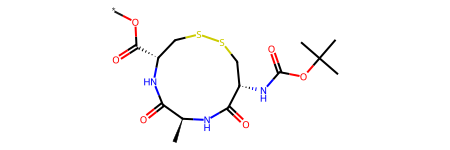

In [1471]:
#C[C@@H]1NC([C@H](CSSC[C@H](NC1=O)C(O[TAGa])=O)NC(OC(C)(C)C)=O)=O #TODO reuse the data, smi token checking first
Chem.MolFromSmiles('C[C@@H]1NC([C@H](CSSC[C@H](NC1=O)C(O[*])=O)NC(OC(C)(C)C)=O)=O')

In [1472]:
atom = Chem.Atom("*")
Chem.SetAtomAlias(atom, "CF3")


In [1473]:
import pandas as pd

In [1474]:
smiles_data = pd.DataFrame({'file_name': [],
                            'SMILESori':[],
                            'SMILESpre':[]
                            }
                            )

In [1475]:
new_row = {'file_name':1, "SMILESori":5,
        'SMILESpre':344,#with *  without expand
        'SMILESexp':36, 
        }
smiles_data._append(new_row, ignore_index=True)


,file_name,SMILESori,SMILESpre,SMILESexp
0,1.0,5.0,344.0,36.0


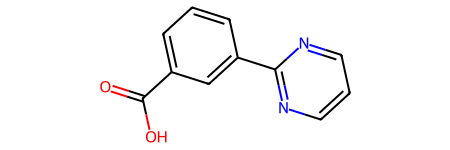

In [1476]:
mm=Chem.MolFromSmiles("O=C(O)C1=CC=CC(C2=NC=CC=N2)=C1")
Chem.SanitizeMol(mm)
mm

In [1477]:
Chem.MolFromSmiles('O=Cc1cccc(-c2ccccN2)c1')


In [1478]:
from SmilesPE.pretokenizer import atomwise_tokenizer
def canonicalize_smiles(smiles, ignore_chiral=False, ignore_cistrans=False, replace_rgroup=True):
    if type(smiles) is not str or smiles == '':
        return '', False
    if ignore_cistrans:
        smiles = smiles.replace('/', '').replace('\\', '')
    if replace_rgroup:
        tokens = atomwise_tokenizer(smiles)
        for j, token in enumerate(tokens):
            if token[0] == '[' and token[-1] == ']':
                symbol = token[1:-1]
                if symbol[0] == 'R' and symbol[1:].isdigit():
                    tokens[j] = f'[{symbol[1:]}*]'
                elif Chem.AtomFromSmiles(token) is None:
                    tokens[j] = '*'
        smiles = ''.join(tokens)
    try:
        canon_smiles = Chem.CanonSmiles(smiles, useChiral=(not ignore_chiral))
        success = True
    except:
        canon_smiles = smiles
        success = False
    return canon_smiles, success


import numpy as np

def calculate_iou(box1, box2):
    """
    计算两个边界框的 IoU
    box1, box2: [x_min, y_min, x_max, y_max]
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0

def nms(atom_bboxes, atom_scores, atom_classes, iou_threshold=0.5):
    """
    应用非极大值抑制 (NMS)
    atom_bboxes: 列表，包含所有边界框 [x_min, y_min, x_max, y_max]
    atom_scores: 列表，包含每个边界框的置信度
    atom_classes: 列表，包含每个边界框的类别
    iou_threshold: IoU 阈值，用于判断是否抑制
    返回: 保留的边界框、类别和置信度的索引
    """
    # 按置信度排序，获取索引
    indices = np.argsort(atom_scores)[::-1]  # 从高到低排序

    keep_indices = []
    while len(indices) > 0:  # 使用 len(indices) 替代 indices.size
        # 保留当前最高置信度的框
        current_idx = indices[0]
        keep_indices.append(current_idx)

        # 计算当前框与其他框的 IoU
        ious = np.array([calculate_iou(atom_bboxes[current_idx], atom_bboxes[idx]) for idx in indices[1:]])
        # 找出 IoU > threshold 的索引（相对于 indices[1:] 的偏移）
        suppress_indices = indices[1:][ious > iou_threshold]
        # 更新 indices，去除当前框和被抑制的框
        indices = np.setdiff1d(indices, np.concatenate(([current_idx], suppress_indices)))
        # 调试信息
        # print(f"Current idx: {current_idx}, rmoved: {suppress_indices}, Remaining: {indices}")
        print(f"@NMS Current idx: {current_idx}, rmoved: {suppress_indices}, IOU: {ious}")

    # 返回保留的框、类别和置信度
    kept_bboxes = np.array([atom_bboxes[i] for i in keep_indices])
    kept_classes = np.array([atom_classes[i] for i in keep_indices])
    kept_scores = np.array([atom_scores[i] for i in keep_indices])

    return kept_bboxes, kept_classes, kept_scores

def merge_low_iou_boxes(kept_bboxes, kept_classes, kept_scores, merge_threshold=0.3):
    """
    合并 IoU < merge_threshold 的边界框，使用较高 score 的 class
    """
    if len(kept_bboxes) <= 1:
        return kept_bboxes, kept_classes, kept_scores

    merged_bboxes = []
    merged_classes = []
    merged_scores = []
    used_indices = set()

    for i in range(len(kept_bboxes)):
        if i in used_indices:
            continue

        # 找到 IoU < merge_threshold 的框组
        current_indices = [i]
        for j in range(i + 1, len(kept_bboxes)):
            if j in used_indices:
                continue
            iou = calculate_iou(kept_bboxes[i], kept_bboxes[j])
            if iou < merge_threshold and iou >0.01:
                current_indices.append(j)

        # 获取相关框的 score, class, 和 bbox
        scores = kept_scores[current_indices]
        classes = kept_classes[current_indices]
        bboxes = kept_bboxes[current_indices]

        max_score = np.max(scores)
        max_score_idx = current_indices[np.argmax(scores)]

        if max_score > 0.5:
            # 保留 score 最大的框
            merged_bboxes.append(kept_bboxes[max_score_idx])
            merged_classes.append(kept_classes[max_score_idx])
            merged_scores.append(kept_scores[max_score_idx])
        else:
            # 合并框，取最小和最大坐标
            new_bbox = [
                np.min(bboxes[:, 0]),  # x_min
                np.min(bboxes[:, 1]),  # y_min
                np.max(bboxes[:, 2]),  # x_max
                np.max(bboxes[:, 3])   # y_max
            ]
            merged_bboxes.append(new_bbox)
            merged_classes.append(0)
            merged_scores.append(max_score)

        # 标记已使用的索引
        used_indices.update(current_indices)

    # 转换为 NumPy 数组
    merged_bboxes = np.array(merged_bboxes)
    merged_classes = np.array(merged_classes)
    merged_scores = np.array(merged_scores)

    return merged_bboxes, merged_classes, merged_scores

In [1479]:
smiles='[EDG]N(C)(C)C(F)(F)'
tokens = atomwise_tokenizer(smiles)
tokens
# mol = Chem.MolFromSmiles(odd_s, sanitize=False)
# Chem.MolToSmiles(mol)


['[EDG]', 'N', '(', 'C', ')', '(', 'C', ')', 'C', '(', 'F', ')', '(', 'F', ')']

In [1480]:
from PIL import Image
import torch
from torchvision import transforms
import torchvision.transforms.v2 as T
import torchvision.transforms.v2.functional as F

def image_to_tensor(image_path,debug=True):
    image = Image.open(image_path)
    w, h = image.size
    
    # 处理灰度或其他模式
    if image.mode == "L":
        if debug: print("检测到灰度图像 (1 通道)，转换为 RGB...")
        image = image.convert("RGB")
    elif image.mode != "RGB":
        if debug: print(f"检测到 {image.mode} 模式，转换为 RGB...")
        image = image.convert("RGB")
    # Define a transform to convert the image to a tensor and normalize it
    transform = T.Compose([
            T.Resize((640, 640)),  # 调整大小
            # T.ToImageTensor(),  # 转换为 PyTorch Tensor
            T.ToTensor(),
            lambda x: x.to(torch.float32),  # 手动转换数据类型# T.ConvertDtype(dtype=torch.float32),  # 转换数据类型
        ])
    
    # Apply the transform to the image
    tensor = transform(image)
    
    return tensor,w,h

def show_atom_number(mol, label='molAtomMapNumber'):
    for atom in mol.GetAtoms():
        atom.SetProp(label, str(atom.GetIdx()))
    return mol
    
def remove_atom_number(mol, label='molAtomMapNumber'):
    # After performing the desired operation (e.g., showing), you can remove the property
    for atom in mol.GetAtoms():
        atom.ClearProp(label)  # Removes the atom index property
    return mol

# After performing the desired operation (e.g., showing), you can remove the property
    for atom in mol.GetAtoms():
        atom.ClearProp(label)  # Removes the atom index property

def remove_SP(input_string):
    # if "S@SP1" in input_string:
    #     input_string = input_string.replace("S@SP1", "S")
    # elif "S@SP2" in input_string:
    #     input_string = input_string.replace("S@SP2", "S")
    # elif "S@SP3" in input_string:
    #     input_string = input_string.replace("S@SP3", "S")
    input_string = re.sub(r'@SP[1-3]', '', input_string)
    return input_string

import pandas as pd
import math
from scipy.spatial import cKDTree


def assemble_atoms_with_charges(atom_list, charge_list):
    used_charge_indices=set()
    kdt = cKDTree(atom_list[['x','y']])
    for i, charge in charge_list.iterrows():
        if i in used_charge_indices:
            continue
        charge_=charge['charge']
        if charge_=='1':charge_='+'
        dist, idx_atom=kdt.query([charge_list.x[i],charge_list.y[i]], k=1)
        atom_str=atom_list.loc[idx_atom,'atom'] 
        atom_ = re.findall(r'[A-Za-z]+', atom_str)[0] + charge_
        atom_list.loc[idx_atom,'atom']=atom_

    return atom_list
    


import re
pattern =  "(\[[^\]]+]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\\\|\/|:|~|@|\?|>|\*|\$|\%[0-9]{2}|[0-9])"
regex = re.compile(pattern)

def atomwise_tokenizer(smi, regex=regex,exclusive_tokens = None):
    """
    Tokenize a SMILES molecule at atom-level:
        (1) 'Br' and 'Cl' are two-character tokens
        (2) Symbols with bracket are considered as tokens

    exclusive_tokens: A list of specifical symbols with bracket you want to keep. e.g., ['[C@@H]', '[nH]'].
    Other symbols with bracket will be replaced by '[UNK]'. default is `None`.
    """
    tokens = [token for token in regex.findall(smi)]
    if exclusive_tokens:
        for i, tok in enumerate(tokens):
            if tok.startswith('['):
                if tok not in exclusive_tokens:
                    tokens[i] = '[UNK]'
    return tokens



bond_labels = [13,14,15,16,17]
# idx_to_labels = {0:'other',1:'C',2:'O',3:'N',4:'Cl',5:'Br',6:'S',7:'F',8:'B',
#             9:'I',10:'P',11:'*',12:'Si',13:'NONE',14:'BEGINWEDGE',15:'BEGINDASH',
#             16:'=',17:'#',18:'-4',19:'-2',20:'-1',21:'1',22:'+2',} #NONE is single ?
idx_to_labels23={0:'other',1:'C',2:'O',3:'N',4:'Cl',5:'Br',6:'S',7:'F',8:'B',
                    9:'I',10:'P',11:'H',12:'Si',13:'NONE',14:'BEGINWEDGE',15:'BEGINDASH',
                    16:'=',17:'#',18:'-4',19:'-2',20:'-1',21:'1',22:'2',} 
idx_to_labels30 = {0:'other',1:'C',2:'O',3:'N',4:'Cl',5:'Br',6:'S',7:'F',8:'B',
                    9:'I',10:'P',11:'H',12:'Si',13:'NONE',14:'BEGINWEDGE',15:'BEGINDASH',
                    16:'=',17:'#',18:'-4',19:'-2',20:'-1',21:'1',22:'2',
                    23:'CF3',#NOTE rdkit get element not supporting group
                    24:'CN',
                    25:'Me',
                    26:'CO2Et',
                    27:'R',
                    28:'Ph',
                    29:'*',
                    }

bond_dirs = {'NONE':    Chem.rdchem.BondDir.NONE,
            'ENDUPRIGHT':   Chem.rdchem.BondDir.ENDUPRIGHT,
            'BEGINWEDGE':   Chem.rdchem.BondDir.BEGINWEDGE,
            'BEGINDASH':    Chem.rdchem.BondDir.BEGINDASH,
            'ENDDOWNRIGHT': Chem.rdchem.BondDir.ENDDOWNRIGHT,}
    
RGROUP_SYMBOLS = ['R', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10', 'R11', 'R12',
                  'Ra', 'Rb', 'Rc', 'Rd', 'X', 'Y', 'Z', 'Q', 'A', 'E', 'Ar']


ELEMENTS = [
    "H", "He", "Li", "Be", "B", "C", "N", "O", "F", "Ne",
    "Na", "Mg", "Al", "Si", "P", "S", "Cl", "Ar", "K", "Ca",
    "Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn",
    "Ga", "Ge", "As", "Se", "Br", "Kr", "Rb", "Sr", "Y", "Zr",
    "Nb", "Mo", "Tc", "Ru", "Rh", "Pd", "Ag", "Cd", "In", "Sn",
    "Sb", "Te", "I", "Xe", "Cs", "Ba", "La", "Ce", "Pr", "Nd",
    "Pm", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb",
    "Lu", "Hf", "Ta", "W", "Re", "Os", "Ir", "Pt", "Au", "Hg",
    "Tl", "Pb", "Bi", "Po", "At", "Rn", "Fr", "Ra", "Ac", "Th",
    "Pa", "U", "Np", "Pu", "Am", "Cm", "Bk", "Cf", "Es", "Fm",
    "Md", "No", "Lr", "Rf", "Db", "Sg", "Bh", "Hs", "Mt", "Ds",
    "Rg", "Cn", "Nh", "Fl", "Mc", "Lv", "Ts", "Og"
]

In [1481]:
from paddleocr import PaddleOCR
ocr = PaddleOCR(use_angle_cls=True,use_gpu =False,
    rec_algorithm='SVTR_LCNet', rec_model_dir='/home/jovyan/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer',
    lang="en")  # need to run only once to download and load model into memory

#* recong used

[2025/03/06 07:25:10] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/home/jovyan/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/home/jovyan/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_le

In [1482]:
home="/home/jovyan/rt-detr"
pt_outhome='/home/jovyan/volume/samba_share/from_docker/ocr_data/rtdetr_output'
pp="tools/output/rtdetr_r50vd_6x_coco_real_resample_charge_large/best_checkpoint.pth"
cc="tools/output/rtdetr_r50vd_6x_coco_real_resample_adapter_both/checkpoint0068.pth"
tt="./output/rtdetr_r50vd_6x_coco_real_resample_charge_large_adpter2/best_checkpoint.pth"
diffS='./output/rtdetr_r50vd_6x_coco_real_resample_charge_large_adpterWithoutJPO_diffSize/checkpoint0071.pth'
# tr1='blured_merged_diff300start11'
# tr1='blured_merged_diff300start12'
# tr1='blured_merged_diff300start12_hand'
tr1='blured_merged_diff300start12_hand_addedObstac'
tr1='merged9'
#NOTE need change the class number@coco_detection.yml when change weight as trained in different class number 
bmd= '/home/jovyan/volume/samba_share/from_docker/ocr_data/rtdetr_output/merged9/best_checkpoint.pth'#30

parser = argparse.ArgumentParser()
parser.add_argument('--config', '-c', type=str, default=f'{home}/rt-detr/configs/rtdetr/rtdetr_r50vd_6x_coco.yml')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/tools/output/rtdetr_r50vd_6x_coco_real_resample_charge_large/checkpoint0032.pth')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/tools/output/rtdetr_r50vd_6x_coco_real_resample/checkpoint0052.pth')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{pp}')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{cc}')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{diffS}')
parser.add_argument('--resume', '-r', type=str, default=f'{bmd}')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{tt}')

# parser.add_argument('--resume', '-r', type=str, default=f'{pt_outhome}/{tr1}/best_checkpoint.pth')


parser.add_argument('--tuning', '-t', type=str,)# default='/home/jovyan/model_checkpoint/rtdetr_r50vd_2x_coco_objects365_from_paddle.pth')
parser.add_argument('--test-only',default=True,)
parser.add_argument('--amp', default=False,)

args, unknown = parser.parse_known_args()#in jupyter

In [1483]:
cfg = YAMLConfig(
        args.config,
        resume=args.resume, 
        use_amp=args.amp,
        tuning=args.tuning
    )
# # args.gpu_device=0
cfg.device=torch.device('cuda', int(os.environ["CUDA_VISIBLE_DEVICES"])) if torch.cuda.is_available() else torch.device('cpu') 

In [1484]:
[
cfg.postprocessor.num_classes,
cfg.postprocessor.use_focal_loss,
cfg.postprocessor.remap_mscoco_category,
cfg.postprocessor.iou_types,
]#rtdertpostprocessor

[30, True, False, ('bbox',)]

In [1485]:
sm="*C1=CC=CC=C1"
m=Chem.MolFromSmiles(sm)
keku_smi_ori=Chem.MolToSmiles(m,kekuleSmiles=True)
keku_smi_ori

'*C1=CC=CC=C1'

In [1486]:
type(cfg.val_dataloader)

loading annotations into memory...
Done (t=0.06s)
creating index...
index created!


src.data.dataloader.DataLoader

In [1487]:
cfg.val_dataloader

DataLoader(
    dataset: Dataset CocoDetection
    Number of datapoints: 427
    Root location: /home/jovyan/rt-detr/data/real_processed/JPO_with_charge/images/test
     img_folder: /home/jovyan/rt-detr/data/real_processed/JPO_with_charge/images/test
     ann_file: /home/jovyan/rt-detr/data/real_processed/JPO_with_charge/annotations/test.json
     return_masks: None
     transforms:
       Compose(
          Resize(size=[640, 640], interpolation=InterpolationMode.BILINEAR, antialias=warn)
          ToImageTensor()
          ConvertDtype()
    )
    batch_size: 10
    num_workers: 4
    drop_last: False
    collate_fn: <function default_collate_fn at 0x7f95a24773a0>
)

In [1488]:
_model=cfg.model
#postprocess need the image original size
if torch.cuda.is_available():
    saved_statDict=torch.load(cfg.resume)
else:
    saved_statDict=torch.load(cfg.resume,map_location=torch.device('cpu'))
loaded_state_dict=saved_statDict['model']
#comaparing with pretrained_model
current_model_dict=_model.state_dict()

postprocessor = cfg.postprocessor##RTDETRPostProcessor@@src/zoo/rtertr

Load PResNet50 state_dict


In [1489]:
from src.zoo.rtdetr.rtdetr_postprocessor import RTDETRPostProcessor
postprocessor2=RTDETRPostProcessor(num_classes=23, use_focal_loss=True, num_top_queries=300, remap_mscoco_category=False)
postprocessor2=RTDETRPostProcessor(num_classes=30, use_focal_loss=True, num_top_queries=300, remap_mscoco_category=False)


In [1490]:
[
postprocessor2.num_classes,
postprocessor2.use_focal_loss,
postprocessor2.remap_mscoco_category,
postprocessor2.iou_types,
],[
cfg.postprocessor.num_classes,
cfg.postprocessor.use_focal_loss,
cfg.postprocessor.remap_mscoco_category,
cfg.postprocessor.iou_types,
]#rtdertpostprocessor

([30, True, False, ('bbox',)], [30, True, False, ('bbox',)])

In [1491]:
if postprocessor2.num_classes==30:
    idx_to_labels=idx_to_labels30
    print('idx_to_labels number', 30,idx_to_labels30)
elif postprocessor2.num_classes==23:
    print('idx_to_labels number', 23,idx_to_labels23)
    idx_to_labels=idx_to_labels23
else:
    print('idx_to_labels number', postprocessor2.num_classes)

lab2idx={ v:k  for k,v in idx_to_labels.items() }

idx_to_labels number 30 {0: 'other', 1: 'C', 2: 'O', 3: 'N', 4: 'Cl', 5: 'Br', 6: 'S', 7: 'F', 8: 'B', 9: 'I', 10: 'P', 11: 'H', 12: 'Si', 13: 'NONE', 14: 'BEGINWEDGE', 15: 'BEGINDASH', 16: '=', 17: '#', 18: '-4', 19: '-2', 20: '-1', 21: '1', 22: '2', 23: 'CF3', 24: 'CN', 25: 'Me', 26: 'CO2Et', 27: 'R', 28: 'Ph', 29: '*'}


In [1492]:
#loaidng trained weights

class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'

#NOTE make sure current_model_dict contating all the loaded_state_dict
key_ori=loaded_state_dict.keys()
key_cur=current_model_dict.keys()
diff_cur=[k for k in key_cur  if k not in key_ori]
diff_ori=[k for k in key_ori if k not in key_cur]#loaded is the original as pretrained
#hehre we only considering new model >= pretrained, not the other case here
same_=[k for k in key_cur if k in key_ori]
# assert len(diff_ori)==0, 
print(f'make sure loaded pretrained model keys: {len(key_ori)} are all included in current build model keys: {len(key_cur)}\n In futhre we considering only part intersection!!')
new_state_dict=dict()
i=0;j=0
for k in same_:
    if loaded_state_dict[k].size()==current_model_dict[k].size():
        new_state_dict[k]=loaded_state_dict[k]
        # print(f'current{k},{current_model_dict[k].size()},ori{loaded_state_dict[k].size()}')
        i+=1
    else:
        new_state_dict[k]=current_model_dict[k] #confg such image_size diff lead
        j+=1
_model.load_state_dict(new_state_dict, strict=False)
print(f'{bcolors.WARNING}have partly load the match paramters>>number of:{len(new_state_dict.keys())}@finalLoad, all:{len(current_model_dict.keys())}@buildModel, {len(loaded_state_dict.keys())}@pretrained. {bcolors.ENDC}')
print(f' {bcolors.WARNING} loaded keys {i}, skip mismatch size keys {j} (same nnName but diff dimensions)')


make sure loaded pretrained model keys: 808 are all included in current build model keys: 808
 In futhre we considering only part intersection!!
have partly load the match paramters>>number of:808@finalLoad, all:808@buildModel, 808@pretrained. 
  loaded keys 808, skip mismatch size keys 0 (same nnName but diff dimensions)


In [1493]:
print("when training use this as valdation dataset::",
    cfg.yaml_cfg['val_dataloader']['dataset']['img_folder'],"\n",
cfg.yaml_cfg['val_dataloader']['dataset']['ann_file'])

# print(type(cfg.val_dataloader))#note this val_dataloader is the training config used, not used for testing 
# print(cfg.val_dataloader.dataset)

when training use this as valdation dataset:: /home/jovyan/rt-detr/data/real_processed/JPO_with_charge/images/test 
 /home/jovyan/rt-detr/data/real_processed/JPO_with_charge/annotations/test.json


In [1494]:
opts = Draw.MolDrawOptions()
opts.addAtomIndices = False
opts.addStereoAnnotation = False

In [1495]:
"""
NOTE 手画和normal keep same labels diction
#generate the hand drawing style image with annotation
python /home/jovyan/volume/samba_share/from_docker/cdk_tsv_process01.py
TODO try mergeing normal and hand drawing
"""

'\nNOTE 手画和normal keep same labels diction\n#generate the hand drawing style image with annotation\npython /home/jovyan/volume/samba_share/from_docker/cdk_tsv_process01.py\nTODO try mergeing normal and hand drawing\n'

In [1496]:
"""
cp csvfiles in *with_charge
python /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/preprocess_data_charge.py 
python /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/coco2coco.py #train
python /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/coco2coco.py #val
--->val_dataloader: from  configs/dataset/coco_detection.yml as the above prepared:
img_folder: /home/jovyan/rt-detr/data/real_processed/staker_with_charge/images/val
ann_file: /home/jovyan/rt-detr/data/real_processed/staker_with_charge/annotations/val.json
nohup python ~/rt-detr/rt-detr/tools/train.py  > train_chembl.log 2>&1 &
nohup python ~/rt-detr/rt-detr/tools/train.py  >> train_mergedChargeWithOutJPO.log 2>&1 &
#NOTE need check args for training and testing output csv, testing need specify the above ann_file,img_folder
python ~/rt-detr/rt-detr/tools/test.py 
cd /home/jovyan/rt-detr/rt-detr
python /home/jovyan/rt-detr/LG_SMILES_1st-main/validation.py
#OCR correct
python /home/jovyan/rt-detr/rt-detr/bo_padlleOCR.py

"""

#CELF match:854,unmatch:3   99.64%
#CELF+OCRstring match:856,unmatch:1  overlapping atoms  99.88%

#staker match:44467, unmatch:1010, erros:16  (不考虑/\异构)
#staker+OCR: match: 170+44467,  unmatch:840

#acs   match:247,unmatch:20,  
#acs+OCR match:247+5,unmatch:15,  with * box expand=5 corrected ::5,uncorrected::15  total::20

#USPTO match:5351,unmatch:66
#USPTO+OCR match:5351+1,unmatch:66-1  corrected ::1,uncorrected::65  total::66 with *box_expand::0

#UOB match:4135,unmatch:37
#UOB+OCR match:4135+4,unmatch:37-4  corrected ::4,uncorrected::33  total::37 with *box_expand::0

#JPO match:417,unmatch:10,erros:0
#JPO+OCR match:417+1,unmatch:10-1,erros:0  corrected ::4,uncorrected::33  total::37 with *box_expand::0




#model 预测miss  rdkti  画图atom overalaping,   构建有坐标2D 图 可以easy checking

# /home/jovyan/rt-detr/data/OCSR_Review/assets/reference

'\ncp csvfiles in *with_charge\npython /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/preprocess_data_charge.py \npython /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/coco2coco.py #train\npython /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/coco2coco.py #val\n--->val_dataloader: from  configs/dataset/coco_detection.yml as the above prepared:\nimg_folder: /home/jovyan/rt-detr/data/real_processed/staker_with_charge/images/val\nann_file: /home/jovyan/rt-detr/data/real_processed/staker_with_charge/annotations/val.json\nnohup python ~/rt-detr/rt-detr/tools/train.py  > train_chembl.log 2>&1 &\nnohup python ~/rt-detr/rt-detr/tools/train.py  >> train_mergedChargeWithOutJPO.log 2>&1 &\n#NOTE need check args for training and testing output csv, testing need specify the above ann_file,img_folder\npython ~/rt-detr/rt-detr/tools/test.py \ncd /home/jovyan/rt-detr/rt-detr\npython /home/jovyan/rt-detr/LG_SMILES_1st-main/validation.py\n#OCR correct\npython /home/jovyan/rt-detr/rt-detr/bo_

In [1497]:
# "/sxs/xsdfsdf.png"
os.path.basename("/sxs/xsdfsdf.png")

'xsdfsdf.png'

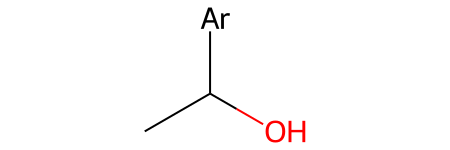

In [1498]:
Chem.MolFromSmiles("[Ar]C(O)C")

In [1499]:
staker_cdf=pd.read_csv(f'staker_with_charge.csv')
staker_cdf_imgs=staker_cdf['img'].to_list()
image_path=staker_cdf_imgs[1]

In [1500]:
from typing import List
######################################add metric postprocess
import rdkit 
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from typing import List
from rdkit.Chem import rdchem, RWMol, CombineMols
from rdkit import Chem
from rdkit.Chem import rdFMCS
import copy
from paddleocr import PaddleOCR
import re
from rdkit import DataStructs

def MCS_mol(mcs):
    #mcs_smart = mcs.smartsString
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    AllChem.Compute2DCoords(mcs_mol)
    return mcs_mol

def g_atompair_matches(pair,mcs):
    mcs_mol = MCS_mol(mcs)
    matches0 = pair[0].GetSubstructMatches(mcs_mol, useQueryQueryMatches=True,uniquify=False, maxMatches=1000, useChirality=False)
    matches1 = pair[1].GetSubstructMatches(mcs_mol, useQueryQueryMatches=True,uniquify=False, maxMatches=1000, useChirality=False)
    if len(matches0) != len(matches1):
        matches0=list(matches0)
        matches1=list(matches1)
        # print( "noted: matcher not equal !!")
        if len(matches0)>len(matches1):
            for i in range(0,len(matches0)):
                if i < len(matches1):
                    pass
                else:
                    ii=i % len(matches1)
                    matches1.append(matches1[ii])
        else:
            for i in range(0,len(matches1)):
                if i < len(matches0):
                    pass
                else:
                    ii=i % len(matches0)
                    matches0.append(matches0[ii])
    assert len(matches0) == len(matches1), "matcher not equal break!!"
    atommaping_pairs=[list(zip(matches0[i],matches1[i])) for i in range(0,len(matches0))]
    return atommaping_pairs


class CustomError(Exception):
    """A custom exception for specific errors."""
    pass

class Substitution(object):
    '''Define common substitutions for chemical shorthand'''
    def __init__(self, abbrvs, smarts, smiles, probability):
        assert type(abbrvs) is list
        self.abbrvs = abbrvs
        self.smarts = smarts
        self.smiles = smiles
        self.probability = probability

SUBSTITUTIONS: List[Substitution] = [#abbrvs, smarts, smiles
    Substitution(['NO2', 'O2N'], '[N+](=O)[O-]', "[N+](=O)[O-]", 0.5),
    Substitution(['CHO', 'OHC'], '[CH1](=O)', "[CH1](=O)", 0.5),
    Substitution(['CO2Et', 'COOEt'], 'C(=O)[OH0;D2][CH2;D2][CH3]', "[C](=O)OCC", 0.5),

    Substitution(['OAc'], '[OH0;X2]C(=O)[CH3]', "[O]C(=O)C", 0.7),
    Substitution(['NHAc'], '[NH1;D2]C(=O)[CH3]', "[NH]C(=O)C", 0.7),
    Substitution(['Ac'], 'C(=O)[CH3]', "[C](=O)C", 0.1),

    Substitution(['OBz'], '[OH0;D2]C(=O)[cH0]1[cH][cH][cH][cH][cH]1', "[O]C(=O)c1ccccc1", 0.7),  # Benzoyl
    Substitution(['Bz'], 'C(=O)[cH0]1[cH][cH][cH][cH][cH]1', "[C](=O)c1ccccc1", 0.2),  # Benzoyl

    Substitution(['OBn'], '[OH0;D2][CH2;D2][cH0]1[cH][cH][cH][cH][cH]1', "[O]Cc1ccccc1", 0.7),  # Benzyl
    Substitution(['Bn'], '[CH2;D2][cH0]1[cH][cH][cH][cH][cH]1', "[CH2]c1ccccc1", 0.2),  # Benzyl

    Substitution(['NHBoc'], '[NH1;D2]C(=O)OC([CH3])([CH3])[CH3]', "[NH1]C(=O)OC(C)(C)C", 0.6),
    Substitution(['NBoc'], '[NH0;D3]C(=O)OC([CH3])([CH3])[CH3]', "[NH1]C(=O)OC(C)(C)C", 0.6),
    Substitution(['Boc'], 'C(=O)OC([CH3])([CH3])[CH3]', "[C](=O)OC(C)(C)C", 0.2),

    Substitution(['Cbm'], 'C(=O)[NH2;D1]', "[C](=O)N", 0.2),
    Substitution(['Cbz'], 'C(=O)OC[cH]1[cH][cH][cH1][cH][cH]1', "[C](=O)OCc1ccccc1", 0.4),
    Substitution(['Cy'], '[CH1;X3]1[CH2][CH2][CH2][CH2][CH2]1', "[CH1]1CCCCC1", 0.3),
    Substitution(['Fmoc'], 'C(=O)O[CH2][CH1]1c([cH1][cH1][cH1][cH1]2)c2c3c1[cH1][cH1][cH1][cH1]3',
                 "[C](=O)OCC1c(cccc2)c2c3c1cccc3", 0.6),
    Substitution(['Mes'], '[cH0]1c([CH3])cc([CH3])cc([CH3])1', "[c]1c(C)cc(C)cc(C)1", 0.5),
    Substitution(['OMs'], '[OH0;D2]S(=O)(=O)[CH3]', "[O]S(=O)(=O)C", 0.7),
    Substitution(['Ms'], 'S(=O)(=O)[CH3]', "[S](=O)(=O)C", 0.2),
    Substitution(['Ph'], '[cH0]1[cH][cH][cH1][cH][cH]1', "[c]1ccccc1", 0.5),
    Substitution(['PMB'], '[CH2;D2][cH0]1[cH1][cH1][cH0](O[CH3])[cH1][cH1]1', "[CH2]c1ccc(OC)cc1", 0.2),
    Substitution(['Py'], '[cH0]1[n;+0][cH1][cH1][cH1][cH1]1', "[c]1ncccc1", 0.1),
    Substitution(['SEM'], '[CH2;D2][CH2][Si]([CH3])([CH3])[CH3]', "[CH2]CSi(C)(C)C", 0.2),
    Substitution(['Suc'], 'C(=O)[CH2][CH2]C(=O)[OH]', "[C](=O)CCC(=O)O", 0.2),
    Substitution(['TBS'], '[Si]([CH3])([CH3])C([CH3])([CH3])[CH3]', "[Si](C)(C)C(C)(C)C", 0.5),
    Substitution(['TBZ'], 'C(=S)[cH]1[cH][cH][cH1][cH][cH]1', "[C](=S)c1ccccc1", 0.2),
    Substitution(['OTf'], '[OH0;D2]S(=O)(=O)C(F)(F)F', "[O]S(=O)(=O)C(F)(F)F", 0.7),
    Substitution(['Tf'], 'S(=O)(=O)C(F)(F)F', "[S](=O)(=O)C(F)(F)F", 0.2),
    Substitution(['TFA'], 'C(=O)C(F)(F)F', "[C](=O)C(F)(F)F", 0.3),
    Substitution(['TMS'], '[Si]([CH3])([CH3])[CH3]', "[Si](C)(C)C", 0.5),
    Substitution(['Ts'], 'S(=O)(=O)c1[cH1][cH1][cH0]([CH3])[cH1][cH1]1', "[S](=O)(=O)c1ccc(C)cc1", 0.6),  # Tos

    # Alkyl chains
    Substitution(['OMe', 'MeO'], '[OH0;D2][CH3;D1]', "[O]C", 0.3),
    Substitution(['SMe', 'MeS'], '[SH0;D2][CH3;D1]', "[S]C", 0.3),
    Substitution(['NMe', 'MeN'], '[N;X3][CH3;D1]', "[NH]C", 0.3),
    Substitution(['Me'], '[CH3;D1]', "[CH3]", 0.1),
    Substitution(['OEt', 'EtO'], '[OH0;D2][CH2;D2][CH3]', "[O]CC", 0.5),
    Substitution(['Et', 'C2H5'], '[CH2;D2][CH3]', "[CH2]C", 0.3),
    Substitution(['Pr', 'nPr', 'n-Pr'], '[CH2;D2][CH2;D2][CH3]', "[CH2]CC", 0.3),
    Substitution(['Bu', 'nBu', 'n-Bu'], '[CH2;D2][CH2;D2][CH2;D2][CH3]', "[CH2]CCC", 0.3),

    # Branched
    Substitution(['iPr', 'i-Pr'], '[CH1;D3]([CH3])[CH3]', "[CH1](C)C", 0.2),
    Substitution(['iBu', 'i-Bu'], '[CH2;D2][CH1;D3]([CH3])[CH3]', "[CH2]C(C)C", 0.2),
    Substitution(['OiBu'], '[OH0;D2][CH2;D2][CH1;D3]([CH3])[CH3]', "[O]CC(C)C", 0.2),
    Substitution(['OtBu'], '[OH0;D2][CH0]([CH3])([CH3])[CH3]', "[O]C(C)(C)C", 0.6),
    Substitution(['tBu', 't-Bu'], '[CH0]([CH3])([CH3])[CH3]', "[C](C)(C)C", 0.3),

    # Other shorthands (MIGHT NOT WANT ALL OF THESE)
    Substitution(['CF3', 'F3C'], '[CH0;D4](F)(F)F', "[C](F)(F)F", 0.5),
    Substitution(['NCF3', 'F3CN'], '[N;X3][CH0;D4](F)(F)F', "[NH]C(F)(F)F", 0.5),
    Substitution(['OCF3', 'F3CO'], '[OH0;X2][CH0;D4](F)(F)F', "[O]C(F)(F)F", 0.5),
    Substitution(['CCl3'], '[CH0;D4](Cl)(Cl)Cl', "[C](Cl)(Cl)Cl", 0.5),
    Substitution(['CO2H', 'HO2C', 'COOH'], 'C(=O)[OH]', "[C](=O)O", 0.5),  # COOH
    Substitution(['CN', 'NC'], 'C#[ND1]', "[C]#N", 0.5),
    Substitution(['OCH3', 'H3CO'], '[OH0;D2][CH3]', "[O]C", 0.4),
    Substitution(['SO3H'], 'S(=O)(=O)[OH]', "[S](=O)(=O)O", 0.4),
        Substitution(['N3'], '[N]=[N+]=[N-]', "[N]=[N+]=[N-]", 0.4),#ACS image dataset has

]
ABBREVIATIONS = {abbrv: sub for sub in SUBSTITUTIONS for abbrv in sub.abbrvs}
def _expand_abbreviation(abbrev):
    """
    Expand abbreviation into its SMILES; also converts [Rn] to [n*]
    Used in `_condensed_formula_list_to_smiles` when encountering abbrev. in condensed formula
    """
    if abbrev in ABBREVIATIONS:
        return ABBREVIATIONS[abbrev].smiles
    elif abbrev in RGROUP_SYMBOLS or (abbrev[0] == 'R' and abbrev[1:].isdigit()):
        if abbrev[1:].isdigit():
            return f'[{abbrev[1:]}*]'
    elif abbrev in ELEMENTS:#ocr tool need this
        return f'[{abbrev}]'
    match = re.match(r'^(\d+)?(.*)', abbrev)
    if match:
        numeric_part, remaining_part = match.groups()
        if remaining_part in ELEMENTS:
            return f'[{abbrev}]'
        else:
            if numeric_part:
                abbrev=f'[{numeric_part}*]'
    return '[*]'


def expandABB(mol,ABBREVIATIONS, placeholder_atoms):
    mols = [mol]
    # **第三步: 替换 * 并合并官能团**
    # 逆序遍历 placeholder_atoms，确保删除后不会影响后续索引
    for idx in sorted(placeholder_atoms.keys(), reverse=True):
        group = placeholder_atoms[idx]  # 获取官能团名称
        # print(idx, group)
        group=_expand_abbreviation(group)
        submol = Chem.MolFromSmiles(group)  # 获取官能团的子分子
        submol_rw = RWMol(submol)  # 让 submol 变成可编辑的 RWMol
        anchor_atom_idx = 0  # 选择 `submol` 的第一个原子作为连接点 as defined in ABBREVIATIONS
        # **1. 复制主分子**
        new_mol = RWMol(mol)
        # **2. 计算 `*` 在 `new_mol` 中的索引**
        placeholder_idx = idx
        # **3. 记录 `*` 原子的邻居**
        neighbors = [nb.GetIdx() for nb in new_mol.GetAtomWithIdx(placeholder_idx).GetNeighbors()]
        # **4. 断开 `*` 的所有键**
        bonds_to_remove = []  # 记录要断开的键
        for bond in new_mol.GetBonds():
            if bond.GetBeginAtomIdx() == placeholder_idx or bond.GetEndAtomIdx() == placeholder_idx:
                bonds_to_remove.append((bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()))
        for bond in bonds_to_remove:
            new_mol.RemoveBond(bond[0], bond[1])
        # **5. 删除 `*` 原子**
        new_mol.RemoveAtom(placeholder_idx)
        # **6. 重新计算 `neighbors`（删除后索引变化）**
        new_neighbors = []
        for neighbor in neighbors:
            if neighbor < placeholder_idx:
                new_neighbors.append(neighbor)
            else:
                new_neighbors.append(neighbor - 1)  # 因为删除了一个原子，所有索引 -1
        # **7. 合并 `submol`**
        new_mol = RWMol(CombineMols(new_mol, submol_rw))

        # **8. 计算 `submol` 的第一个原子在合并后的位置**
        new_anchor_idx = new_mol.GetNumAtoms() - len(submol_rw.GetAtoms()) + anchor_atom_idx

        # **9. 重新连接官能团**
        for neighbor in new_neighbors:
            # print(neighbor, new_anchor_idx, "!!")
            new_mol.AddBond(neighbor, new_anchor_idx, Chem.BondType.SINGLE)#TODO Fix me should use delted bondtype
            a1=new_mol.GetAtomWithIdx(neighbor)
            a2=new_mol.GetAtomWithIdx(new_anchor_idx)
            a1.SetNumRadicalElectrons(0)
            a2.SetNumRadicalElectrons(0)## 将自由基电子数设为 0,as has added new bond
        # **10. 更新主分子**
        mol = new_mol
        mols.append(mol)
    # 输出修改后的分子 SMILES
    modified_smiles = Chem.MolToSmiles(mols[-1])
    # print(f"修改后的分子 SMILES: {modified_smiles}")            
    return mols[-1], modified_smiles

def molExpanding(mol_rebuit,placeholder_atoms,wdbs,bond_dirs):
    cm=copy.deepcopy(mol_rebuit)
    # print(placeholder_atoms)
    expand_mol, expand_smiles= expandABB(cm,ABBREVIATIONS, placeholder_atoms)
    rdm=copy.deepcopy(expand_mol)
    AllChem.Compute2DCoords(rdm)
    target_mol, ref_mol=rdm, cm
    mcs=rdFMCS.FindMCS([target_mol, ref_mol], # larger,small order
                    atomCompare=rdFMCS.AtomCompare.CompareAny,
                    bondCompare=rdFMCS.BondCompare.CompareAny,
                    ringCompare=rdFMCS.RingCompare.IgnoreRingFusion,
                    matchChiralTag=False,
    )
    # mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    # matches0 = target_mol.GetSubstructMatches(mcs_mol, useQueryQueryMatches=True,uniquify=False, maxMatches=1000, useChirality=False)
    # matches1 = ref_mol.GetSubstructMatches(mcs_mol, useQueryQueryMatches=True,uniquify=False, maxMatches=1000, useChirality=False)
    # assert len(matches0) == len(matches1), "matcher not equal break!!"
    atommaping_pairs=g_atompair_matches([target_mol, ref_mol],mcs)

    # atommaping_pairs=[list(zip(matches0[i],matches1[i])) for i in range(0,len(matches0))]
    # if len(atommaping_pairs)>1:
    #     atomMap=atommaping_pairs[0]
    # else:
    #     atomMap=atommaping_pairs
    #always list of list
    atomMap=atommaping_pairs[0]
        
    try:
        rmsd2=rdkit.Chem.rdMolAlign.AlignMol(prbMol=target_mol, refMol=ref_mol, atomMap=atomMap,maxIters=2000000)
    except Exception as e:
        print(atomMap,"@@@@")
        print(e)
    #after get atomMap
    c2p={cur:pre for cur, pre in atomMap}
    p2c={pre:cur for cur, pre in atomMap}
    for b in wdbs:#add bond direction
        p0,p1=int(b[0]), int(b[1])#may be not in the atomMap as the mcs_sub
        if p0 in p2c.keys() and p1 in p2c.keys():
            c0,c1=p2c[p0],p2c[p1]
            # print("[pre0,pre1]vs[c0,c1]current atom id",[p0,p1],[c0,c1])
            b_=target_mol.GetBondBetweenAtoms(c0,c1)
            if b_:
                b_.SetBondDir(bond_dirs[b[3]])
    expandStero_smi=Chem.MolToSmiles(target_mol)#directly will not add the stero info into smiles, must have the assing steps
    m=target_mol.GetMol()
    # Chem.SanitizeMol(m)
    Chem.DetectBondStereochemistry(m)
    Chem.AssignChiralTypesFromBondDirs(m)
    Chem.AssignStereochemistry(m)#expandStero_smi ,  m 
    return expandStero_smi, m  
##############################################################
# Helper function to check if two boxes overlap
def boxes_overlap(box1, box2):
    x1, y1, x2, y2 = box1
    bx1, by1, bx2, by2 = box2
    return not (x2 < bx1 or x1 > bx2 or y2 < by1 or y1 > by2)

def boxes_overlap2(atombonx, bondbox):
    """
    检查两个矩形框是否重叠，并返回 bondbox 中不重叠一端到中心 10% 位置的坐标。
    
    参数:
        atombonx: tuple (x1, y1, x2, y2) 表示原子框的坐标
        bondbox: tuple (bx1, by1, bx2, by2) 表示键框的坐标
        
    返回:
        tuple (x, y) 表示 bondbox 不重叠一端到中心 80% 位置的坐标，如果完全包含返回 (None, None)
    """
    x1, y1, x2, y2 = atombonx
    bx1, by1, bx2, by2 = bondbox
    
    # 计算 bond_box 的中心坐标
    bond_center_x = (bx1 + bx2) / 2
    bond_center_y = (by1 + by2) / 2
    
    # 辅助函数：计算点到 atom_box 中心的距离
    def distance_to_center(x, y):
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2
        return ((x - center_x) ** 2 + (y - center_y) ** 2) ** 0.5
    
    # 辅助函数：计算从中心到端点 80% 位置的坐标
    def get_80_percent_point(far_x, far_y):
        # 从中心到端点的向量，按 80% 比例缩放
        dx = far_x - bond_center_x
        dy = far_y - bond_center_y
        new_x = bond_center_x + 0.7 * dx#let added H close to the heavy neighbor
        new_y = bond_center_y + 0.7 * dy
        return new_x, new_y
    
    # 检查是否完全不相交
    if (bx2 < x1 or bx1 > x2 or by2 < y1 or by1 > y2):
        # 完全不相交，返回较远一端到中心 80% 位置
        dist1 = distance_to_center(bx1, by1)
        dist2 = distance_to_center(bx2, by2)
        far_x, far_y = (bx2, by2) if dist2 > dist1 else (bx1, by1)
        return get_80_percent_point(far_x, far_y)
    
    # 检查是否完全包含在 atom_box 内
    if (bx1 >= x1 and bx2 <= x2 and by1 >= y1 and by2 <= y2):
        # bondbox 完全在 atom_box 内，无法确定不重叠部分，返回 None
        return None, None
    
    # 检查一端是否在 atom_box 内
    if (bx1 >= x1 and bx1 <= x2 and by1 >= y1 and by1 <= y2):
        # bx1, by1 在 atom_box 内，返回 bx2, by2 到中心 80% 位置
        return get_80_percent_point(bx2, by2)
    elif (bx2 >= x1 and bx2 <= x2 and by2 >= y1 and by2 <= y2):
        # bx2, by2 在 atom_box 内，返回 bx1, by1 到中心 80% 位置
        return get_80_percent_point(bx1, by1)
    
    # 处理部分相交但两端都不在 atom_box 内的情况
    # 返回较远一端到中心 80% 位置
    dist1 = distance_to_center(bx1, by1)
    dist2 = distance_to_center(bx2, by2)
    far_x, far_y = (bx2, by2) if dist2 > dist1 else (bx1, by1)
    return get_80_percent_point(far_x, far_y)

charge_labels = [18,19,20,21,22]
def outputbox_update(output,bond_labels,charge_labels = [18,19,20,21,22]):
    bonds_mask = np.array([True if ins  in bond_labels else False for ins in output['pred_classes']])
    bond_bbox=output['bbox'][bonds_mask]
    atoms_mask = np.array([True if ins not in bond_labels and ins not in charge_labels else False for ins in output['pred_classes']])
    atom_bbox=output['bbox'][atoms_mask]
    new_atoms=[]
    b_len=3
    single_odd_b2a=dict()
    for bi,bb in enumerate(bond_bbox):
        overlapped_atoms = []
        overlapped_abox=[]
        for ai,aa in enumerate(atom_bbox):
            overlap_flag=boxes_overlap(bb, aa)#TODO use tghe atom bond box overlap get bond atom mapping,then built mol
            if overlap_flag:
                # print(bb, aa,overlap_flag)
                overlapped_atoms.append(ai)
                overlapped_abox.append(aa)
        if len(overlapped_atoms) == 1:
            single_odd_b2a[bi]=overlapped_atoms
            # Compute the non-overlapping part of the bond box to place hydrogen
            non_overlapping_x,non_overlapping_y=boxes_overlap2(overlapped_abox[0], bb)
            new_atom_out={'bbox':    np.array([non_overlapping_x - b_len, 
                                    non_overlapping_y - b_len,
                                    non_overlapping_x + b_len, 
                                    non_overlapping_y + b_len]).reshape(-1,4),
                'bbox_centers': np.array([non_overlapping_x,non_overlapping_y]).reshape(-1,2),
                'scores':       np.array([1.0]),
                'pred_classes': np.array([lab2idx['H']])}
            new_atoms.append(new_atom_out)

    output2_=copy.deepcopy(output)
    for boxout in new_atoms:
        for k,arr in boxout.items():
            value_or_row=output2_[k]
            if arr.ndim == 1:
                output2_[k]=np.append(value_or_row, arr)
            elif arr.ndim >= 2:
                output2_[k] = np.concatenate([value_or_row, arr], axis=0)
            else:
                print('errprs, unkown conditions !!!@')
    return output2_, single_odd_b2a

def Newbox_(atom_bbox,bond_bbox):
    #add H atom box when on direction bond
    new_atoms=[]
    b_len=3
    single_odd_b2a=dict()
    for bi,bb in enumerate(bond_bbox):
        overlapped_atoms = []
        overlapped_abox=[]
        for ai,aa in enumerate(atom_bbox):
            overlap_flag=boxes_overlap(bb, aa)#TODO use tghe atom bond box overlap get bond atom mapping,then built mol
            if overlap_flag:
                # print(bb, aa,overlap_flag)
                overlapped_atoms.append(ai)
                overlapped_abox.append(aa)
        if len(overlapped_atoms) == 1:
            single_odd_b2a[bi]=overlapped_atoms
            # Compute the non-overlapping part of the bond box to place hydrogen
            non_overlapping_x,non_overlapping_y=boxes_overlap2(overlapped_abox[0], bb)
            new_atom_out={'bbox':    np.array([non_overlapping_x - b_len, 
                                    non_overlapping_y - b_len,
                                    non_overlapping_x + b_len, 
                                    non_overlapping_y + b_len]).reshape(-1,4),
                'bbox_centers': np.array([non_overlapping_x,non_overlapping_y]).reshape(-1,2),
                'scores':       np.array([1.0]),
                'pred_classes': np.array([lab2idx['H']])}
            new_atoms.append(new_atom_out)
    return new_atoms, single_odd_b2a
    # # output2_=copy.deepcopy(output)
    # for boxout in new_atoms:
    #     for k,arr in boxout.items():
    #         value_or_row=output2_[k]
    #         if arr.ndim == 1:
    #             output2_[k]=np.append(value_or_row, arr)
    #         elif arr.ndim >= 2:
    #             output2_[k] = np.concatenate([value_or_row, arr], axis=0)
    #         else:
    #             print('errprs, unkown conditions !!!@')
    # return output2_, single_odd_b2a

def remove_unconnected_hydrogens(mol):
    """
    移除分子中不与重原子相连的氢原子（包括孤立 H 和只连到其他 H 的 H）。
    
    参数:
        mol: RDKit Mol 对象
        
    返回:
        移除氢原子后的 RWMol 对象
    """
    # 转换为可编辑的 RWMol 对象
    molexp = Chem.RWMol(mol)
    to_remove = []

    # 遍历所有原子
    for atom in molexp.GetAtoms():
        if atom.GetSymbol() == 'H':  # 只处理氢原子
            neighbors = atom.GetNeighbors()
            # 检查邻居中是否有重原子
            has_heavy_atom = False
            for neighbor in neighbors:
                if neighbor.GetSymbol() != 'H':  # 如果邻居不是 H，则是重原子
                    has_heavy_atom = True
                    break
            # 如果没有重原子邻居，标记为移除
            if not has_heavy_atom:
                to_remove.append(atom.GetIdx())
    # 按索引从大到小排序，避免移除时索引混乱
    to_remove.sort(reverse=True)
    
    # 移除标记的原子
    for ai in to_remove:
        molexp.RemoveAtom(ai)
    return molexp

from rdkit import Chem
from rdkit.Chem import AllChem

def remove_unconnected_hydrogens2(mol):
    """
    移除分子中不与重原子相连的氢原子（包括孤立 H 和只连到其他 H 的 H），并返回移除的氢原子坐标。

    参数:
        mol: RDKit Mol 对象

    返回:
        rw_mol: 移除氢原子后的 RWMol 对象
        removed_h_coords: 移除的氢原子的坐标列表 [(x1, y1, z1), (x2, y2, z2), ...]
    """
    # 转换为可编辑的 RWMol 对象
    rw_mol = Chem.RWMol(mol)
    to_remove = []

    # 获取分子的构象（假设只有一个构象）
    conformer = rw_mol.GetConformer()

    # 存储移除的氢原子坐标
    removed_h_coords = []

    # 遍历所有原子
    for atom in rw_mol.GetAtoms():
        if atom.GetSymbol() == 'H':  # 只处理氢原子
            neighbors = atom.GetNeighbors()
            # 检查邻居中是否有重原子
            has_heavy_atom = False
            for neighbor in neighbors:
                if neighbor.GetSymbol() != 'H':  # 如果邻居不是 H，则是重原子
                    has_heavy_atom = True
                    break
            # 如果没有重原子邻居，标记为移除，并记录坐标
            if not has_heavy_atom:
                to_remove.append(atom.GetIdx())
                pos = conformer.GetAtomPosition(atom.GetIdx())
                removed_h_coords.append((pos.x, pos.y, pos.z))
    # 按索引从大到小排序，避免移除时索引混乱
    to_remove.sort(reverse=True)
    # 移除标记的原子
    for ai in to_remove:
        rw_mol.RemoveAtom(ai)

    return rw_mol, removed_h_coords

def detect_unconnected_hydrogens(mol):
    rw_mol = Chem.RWMol(mol)
    to_remove = []
    # 获取分子的构象（假设只有一个构象）
    conformer = rw_mol.GetConformer()
    # 存储移除的氢原子坐标
    removed_h_coords = []
    # 遍历所有原子
    for atom in rw_mol.GetAtoms():
        if atom.GetSymbol() == 'H':  # 只处理氢原子
            neighbors = atom.GetNeighbors()
            # 检查邻居中是否有重原子
            has_heavy_atom = False
            for neighbor in neighbors:
                if neighbor.GetSymbol() != 'H':  # 如果邻居不是 H，则是重原子
                    has_heavy_atom = True
                    break
            # 如果没有重原子邻居，标记为移除，并记录坐标
            if not has_heavy_atom:
                to_remove.append(atom.GetIdx())
                pos = conformer.GetAtomPosition(atom.GetIdx())
                removed_h_coords.append((pos.x, pos.y, pos.z))
    # 按索引从大到小排序，避免移除时索引混乱
    to_remove.sort(reverse=True)
    return to_remove

def view_box_center2(bond_bbox, bond_centers, bond_scores, bond_classes,overlap_dist_thresh=5.0, 
                     max_centers_per_box=5,
                     plot_view=False,
                     ):
    """
    筛选和可视化 bond_bbox 和 bond_centers，处理重叠圆和过多中心的框。
    
    参数:
        bond_bbox: numpy array, [x1, y1, x2, y2] 格式的框坐标
        bond_centers: numpy array, [x, y] 格式的中心坐标
        bond_scores: numpy array, 得分
        overlap_dist_thresh: float，判断圆重叠的距离阈值（默认为 5 个单位）
        max_centers_per_box: int，一个框内允许的最大中心数（超过则移除）
    
    返回:
        tuple: (筛选后的 bond_bbox, bond_centers, bond_scores)
    """
    # 确保输入形状匹配
    assert len(bond_bbox) == len(bond_centers) == len(bond_scores), "Input arrays must have equal length"
    n = len(bond_bbox)
    # Step 1: 处理重叠的 bond_centers（保留得分最高的）
    keep_centers = np.ones(n, dtype=bool)  # 标记要保留的中心
    for i in range(n):
        if not keep_centers[i]:
            continue
        for j in range(i + 1, n):
            if not keep_centers[j]:
                continue
            # 计算两个中心之间的欧几里得距离
            dist = np.sqrt(np.sum((bond_centers[i] - bond_centers[j]) ** 2))
            if dist < overlap_dist_thresh:
                # 如果重叠，保留得分较高的
                if bond_scores[i] > bond_scores[j]:
                    keep_centers[j] = False
                else:
                    keep_centers[i] = False
    # 应用初步筛选
    bond_bbox = bond_bbox[keep_centers]
    bond_centers = bond_centers[keep_centers]
    bond_scores = bond_scores[keep_centers]
    bond_classes= bond_classes[keep_centers]
    n = len(bond_bbox)  # 更新数量
    # Step 2: 检查每个框内的中心数量
    keep_boxes = np.ones(n, dtype=bool)  # 标记要保留的框
    for i in range(n):
        # 计算框内的中心数量
        x1, y1, x2, y2 = bond_bbox[i]
        centers_in_box = np.sum((bond_centers[:, 0] >= x1) & (bond_centers[:, 0] <= x2) &
                                (bond_centers[:, 1] >= y1) & (bond_centers[:, 1] <= y2))
        if centers_in_box > max_centers_per_box and bond_scores[i]<0.5:
            keep_boxes[i] = False
    # 应用最终筛选
    final_bond_bbox = bond_bbox[keep_boxes]
    final_bond_centers = bond_centers[keep_boxes]
    final_bond_scores = bond_scores[keep_boxes]
    final_bond_classes= bond_classes[keep_boxes]
    if plot_view:
        # 可视化（可选）
        fig, ax = plt.subplots(figsize=(10, 10))
        for box in final_bond_bbox:
            x1, y1, x2, y2 = box
            width = x2 - x1
            height = y2 - y1
            rect = Rectangle((x1, y1), width, height, linewidth=1, edgecolor='blue', facecolor='none')
            ax.add_patch(rect)
        for center in final_bond_centers:
            circle = Circle(center, radius=5, edgecolor='red', facecolor='none', linewidth=1)
            ax.add_patch(circle)
        
        # 设置坐标轴范围
        x_min = min(final_bond_bbox[:, 0].min(), final_bond_centers[:, 0].min()) - 10
        x_max = max(final_bond_bbox[:, 2].max(), final_bond_centers[:, 0].max()) + 10
        y_min = min(final_bond_bbox[:, 1].min(), final_bond_centers[:, 1].min()) - 10
        y_max = max(final_bond_bbox[:, 3].max(), final_bond_centers[:, 1].max()) + 10
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        
        ax.set_title("Filtered Boxes and Centers")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        plt.gca().set_aspect('equal', adjustable='box')
        plt.grid(True, linestyle='--', alpha=0.7)
        # plt.show()
    else:
        fig=None
    return final_bond_bbox, final_bond_centers, final_bond_scores,final_bond_classes,fig

In [1501]:
#########################
correcte=[]
uncorrects=[]
debug=False
image_path="/home/jovyan/rt-detr/data/real_processed/staker_with_charge/images/test/18091.png"
input_s="CC1=CC2C[Ac]=NCCOC=2C=C1"
image_path="/home/jovyan/rt-detr/data/real_processed/staker_with_charge/images/test/49565.png"
input_s="*C1C=C2C([*])=NN=C([U])C2=CN=1"

image_path='/home/jovyan/rt-detr/data/real_processed/USPTO_with_charge/images/test/US07314883-20080101-C00493.png'
input_s='CC1=CC(CO)=CC([N+](=O)[O-])=C1[N+](=O)[O-]'





dname="CLEF"
home='/home/jovyan/rt-detr'
data_csvf=f'{home}/data/real_processed/{dname}_with_charge/{dname}.csv'
imgdir=f'{home}/data/real_processed/{dname}_with_charge/images/test/'
df_csv=pd.read_csv(data_csvf)


In [1502]:
image_path=f"{imgdir}/{df_csv.file_name[0]}"
target_smiles=df_csv.SMILES[0]
print(image_path)

df_csv.head(2)


/home/jovyan/rt-detr/data/real_processed/CLEF_with_charge/images/test//US20070117785A1_p0034_x0977_y2564_c00072.png


,file_name,SMILES
0,US20070117785A1_p0034_x0977_y2564_c00072.png,CC(=O)N1CCC2=C(C1)C(C1=CC=C(C(F)(F)F)C=C1)=NN2...
1,US20050004369A1_p0017_x1399_y0692_c00023.png,OCC1=CC=C(C2=CC=C(N3C=CC4=C3C=CC=C4)C=C2)C=C1


In [1503]:
xx='US20070155803A1_p0002_x1503_y1997_c00000.png'
image_path=f"{imgdir}/{xx}"
ix = df_csv.index[df_csv['file_name'] == f'{xx}'].tolist()[0]
target_smiles=df_csv.SMILES[ix]
print(target_smiles),df_csv.SMILES[i:5]


[1*]C([2*])(N)C(=O)N([3*])N([4*])C(=O)N([5*])[6*]


(None, Series([], Name: SMILES, dtype: object))

In [1504]:
# image_path='/home/jovyan/volume/samba_share/from_docker/data/acs_with_charge/images/test/acs.joc.5b02057-Scheme-c8-6.png'
# image_path="/home/jovyan/volume/samba_share/from_docker/workspace/apex/MCSnipaste_2025-01-06_17-59-02.png"
# # image_path='/home/jovyan/volume/samba_share/from_docker/ocr_data/handDrawLike/DECIMER_HDM/images/train/CDK_Depict_4_49.png'
# # image_path='/home/jovyan/volume/samba_share/from_docker/data/acs_with_charge/images/test/ol500248h-Scheme-c2-26.png'
image_path='/home/jovyan/rt-detr/data/real/acs/ja5080739-Scheme-c1-17.png'
image_path='/home/jovyan/rt-detr/data/real/acs/jo9519672-Scheme-c1-5.png'

# image_path='/home/jovyan/rt-detr/data/real/acs/acs.orglett.5b03590-Table-c2-0.png'

In [1505]:
image_path="/home/jovyan/volume/samba_share/from_docker/ocr_data/handDrawLike/DECIMER_HDM/images/train/CDK_Depict_42_80.png"
image_path='/home/jovyan/volume/samba_share/from_docker/workspace/fig7a.png'#paper screen
image_path='/home/jovyan/volume/samba_share/from_docker/workspace/fig7c.png'#paper screen

#real
image_path="/home/jovyan/rt-detr/data/real/acs/op990035n-Scheme-c1-7.png"
image_path="/home/jovyan/rt-detr/data/real/acs/ja206047h-Table-c1-4.png"
image_path="/home/jovyan/rt-detr/data/real/USPTO/USRE039991-20080101-C00272.png"

# #overlap bond or cross bond
# image_path='/home/jovyan/volume/samba_share/from_docker/data/acs_with_charge/images/test/op200019k-Scheme-c6-1.png'
# image_path='/home/jovyan/volume/samba_share/from_docker/data/JPO_with_charge/images/test/2008152203_25_chem.png'
#used above two on paper
# image_path='/home/jovyan/volume/samba_share/from_docker/data/acs_with_charge/images/test/67.png'
# image_path='/home/jovyan/volume/samba_share/from_docker/data/JPO_with_charge/images/test/2008238710_3_chem.png'
# image_path='/home/jovyan/volume/samba_share/from_docker/data/UOB_with_charge/images/test/maybridge-0313-197312003.png'
# image_path='/home/jovyan/volume/samba_share/from_docker/data/UOB_with_charge/images/test/maybridge-0239-923900285.png'



In [1506]:
image_path="/home/jovyan/volume/samba_share/from_docker/data/work_space/USPTO/USRE039991-20080101-C00272.png"
image_path="/home/jovyan/rt-detr/data/real/acs/ja206047h-Table-c1-4.png"
image_path='/home/jovyan/rt-detr/data/real/acs/jo9519672-Scheme-c1-5.png'
image_path='/home/jovyan/rt-detr/data/real/acs/ja5080739-Scheme-c1-17.png'
image_path="/home/jovyan/rt-detr/data/real/acs/op990035n-Scheme-c1-7.png"
# image_path='/home/jovyan/volume/samba_share/from_docker/workspace/fig7c.png'#paper screen manualy drawing
image_path='/home/jovyan/volume/samba_share/from_docker/data/UOB_with_charge/images/test/maybridge-0239-923900285.png'
image_path='/home/jovyan/volume/samba_share/from_docker/data/JPO_with_charge/images/test/2008238710_3_chem.png'
# image_path="/home/jovyan/rt-detr/data/real/UOB/maybridge-0239-923900285.png"#this missing bonds, need training
image_path="/home/jovyan/volume/samba_share/from_docker/data/work_space/ori/real/acs/op300209p-Scheme-c2-4.png"
image_path="/home/jovyan/volume/samba_share/from_docker/data/work_space/ori/real/acs/ol401443a-Table-c1-5.png"
# image_path="/home/jovyan/volume/samba_share/from_docker/data/work_space/ori/real/acs/ol503618m-Scheme-c3-5.png"
# image_path='/home/jovyan/volume/samba_share/from_docker/data/work_space/ori/real/acs/op200112g-Scheme-c7-26.png'
# image_path="/home/jovyan/volume/samba_share/from_docker/data/work_space/ori/real/acs/70.png"

图像的尺寸 [250, 293]


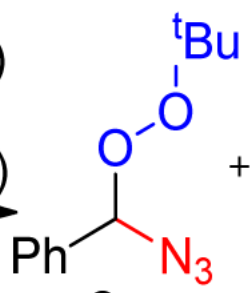

In [1507]:
img_ori = Image.open(image_path).convert('RGB')
w_ori, h_ori = img_ori.size  # 获取原始图像的尺寸
print(f"图像的尺寸",[w_ori, h_ori ])
img_ori

In [1508]:
def calculate_iou(box1, box2):
    """
    计算两个框的 IoU（Intersection over Union）。
    
    参数:
        box1, box2: [x1, y1, x2, y2] 格式的框坐标
        
    返回:
        float: IoU 值
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

def nms_per_class(labels, boxes, scores, iou_thresh=0.5):
    """
    对每个类别应用 NMS，保留得分最高的框。
    
    参数:
        labels: numpy array，类别标签
        boxes: numpy array，框坐标 [x1, y1, x2, y2]
        scores: numpy array，得分
        iou_thresh: float，IoU 阈值
        
    返回:
        dict: 筛选后的输出
    """
    # 按类别分组
    unique_labels = np.unique(labels)
    kept_indices = []
    
    for label in unique_labels:
        # 筛选当前类别的框
        class_mask = labels == label
        class_indices = np.where(class_mask)[0]
        class_boxes = boxes[class_mask]
        class_scores = scores[class_mask]
        
        # 按得分从高到低排序
        order = np.argsort(class_scores)[::-1]
        class_boxes = class_boxes[order]
        class_scores = class_scores[order]
        class_indices = class_indices[order]
        
        # NMS
        keep = []
        while len(class_scores) > 0:
            # 保留得分最高的框
            keep.append(class_indices[0])
            if len(class_scores) == 1:
                break
            
            # 计算当前框与其他框的 IoU
            ious = np.array([calculate_iou(class_boxes[0], box) for box in class_boxes[1:]])
            # 保留 IoU 低于阈值的框
            keep_mask = ious < iou_thresh
            class_boxes = class_boxes[1:][keep_mask]
            class_scores = class_scores[1:][keep_mask]
            class_indices = class_indices[1:][keep_mask]
        
        kept_indices.extend(keep)
    
    # 根据保留的索引更新输出
    kept_indices = np.array(kept_indices)
    return {
        'labels': labels[kept_indices],
        'boxes': boxes[kept_indices],
        'scores': scores[kept_indices]
    }

In [1509]:
# Example usage: #change thie image
tensor,w,h = image_to_tensor(image_path)
tensor=tensor.unsqueeze(0)
print(tensor.size())  # Output tensor shape (C x H x W)

_model.training=False
_model.eval()#have to uset this
with torch.no_grad():
    print("training",_model.training)
    outputs = _model(tensor)

ori_size=torch.Tensor([w,h]).long().unsqueeze(0)
if len(idx_to_labels)==23:
    result_ = postprocessor(outputs, ori_size)
elif len(idx_to_labels)==30:
    result_ = postprocessor2(outputs, ori_size)
else:
    print(f"error unkown ways!!")
# result_ = postprocessor(out_, torch.Tensor([w,h]))
score_=result_[0]['scores']
boxe_=result_[0]['boxes']
label_=result_[0]['labels']
#---------------------------------################################
# box_thresh=0.01
box_thresh=0.1

selected_indices =score_ > box_thresh
# selected_indices =score_ > score_.mean()
# 统计 True 的数量
true_count = selected_indices.sum().item()
print(f"selected_indices 中 True 的数量: {true_count}")

output={
    'labels': label_[selected_indices].to("cpu").numpy(),
    'boxes': boxe_[selected_indices].to("cpu").numpy(),
    'scores': score_[selected_indices].to("cpu").numpy()
}



torch.Size([1, 3, 640, 640])
training False


selected_indices 中 True 的数量: 25


In [1510]:
output = nms_per_class(output['labels'], output['boxes'], output['scores'], iou_thresh=0.5)
print(f"box 的数量:{len(output['labels'])}")

box 的数量:20


250 293 orignianl vs 1000,1000
from oupt socore > 0.1,get box 20 without NMS


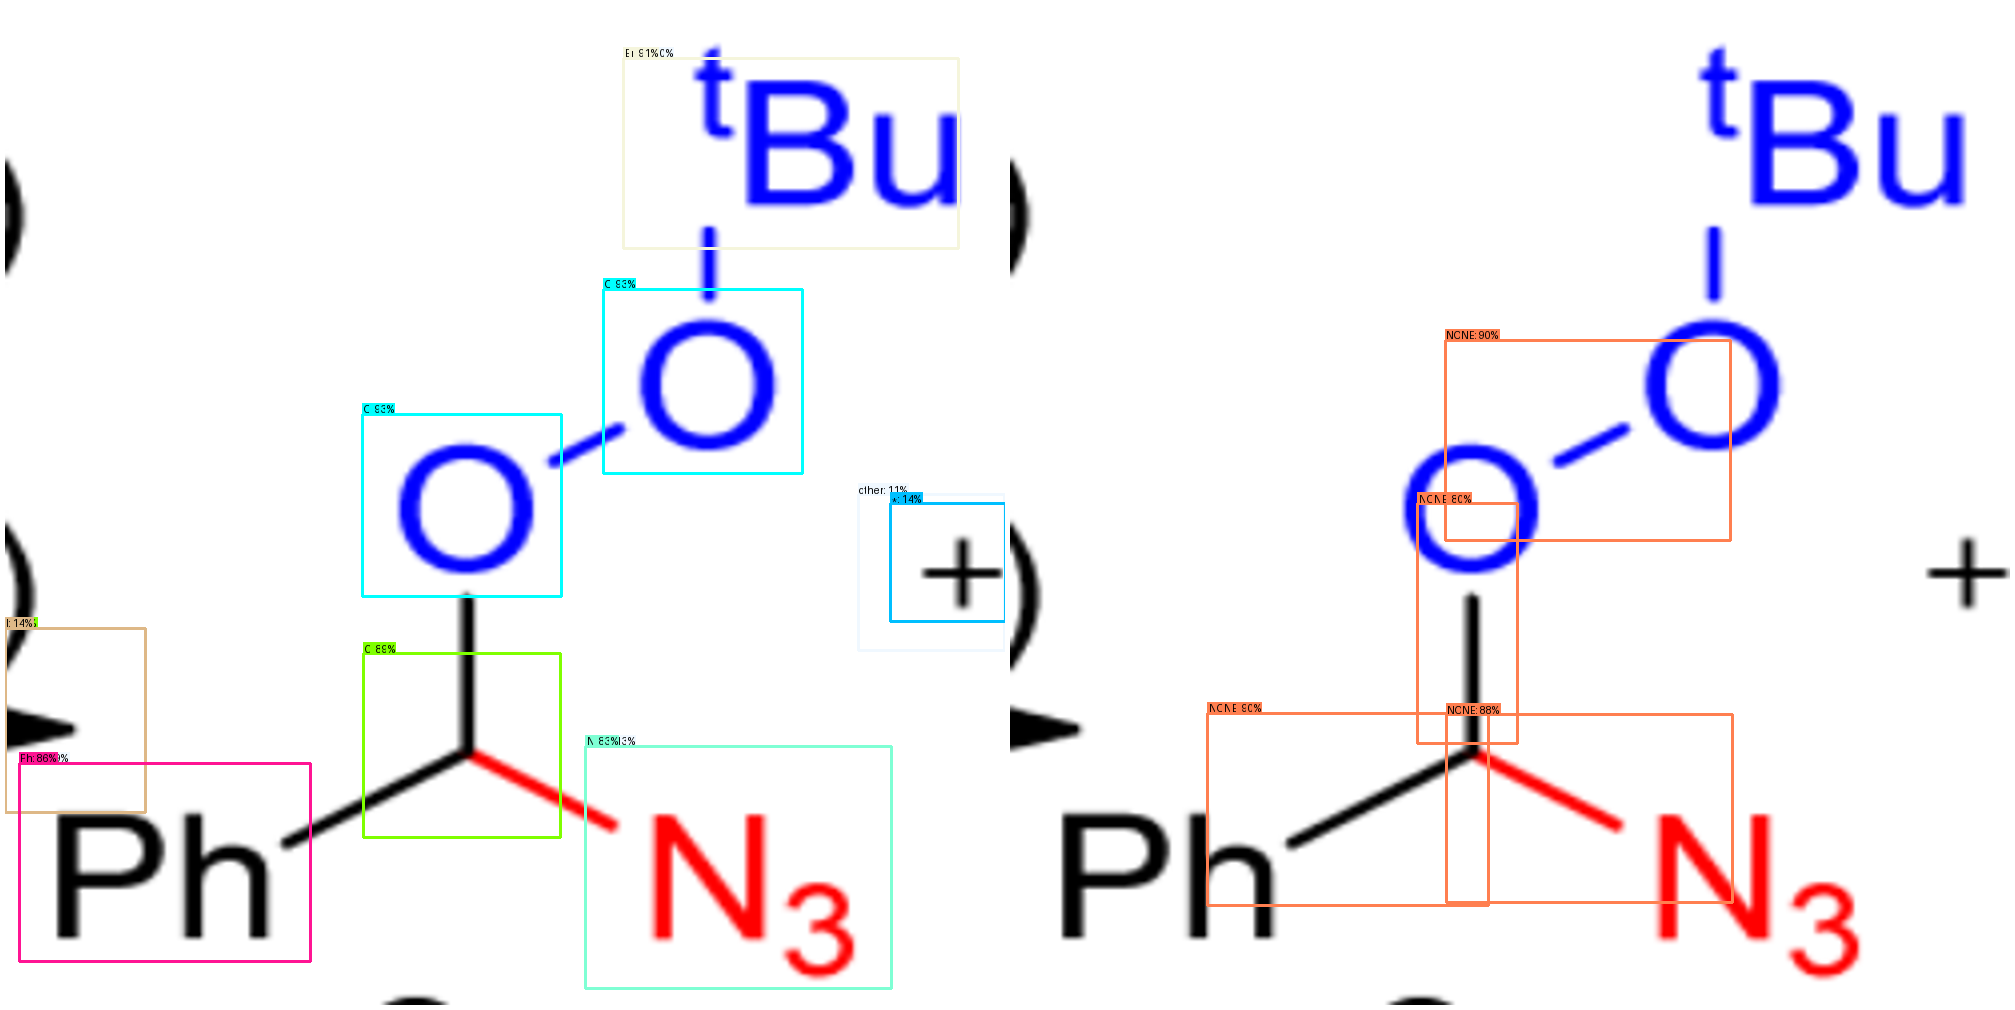

In [1511]:
filtered_output_dict={image_path: output
}
x_center = (output["boxes"][:, 0] + output["boxes"][:, 2]) / 2
y_center = (output["boxes"][:, 1] + output["boxes"][:, 3]) / 2
# center_coords = torch.stack((x_center, y_center), dim=1)
center_coords = np.stack((x_center, y_center), axis=1)
# center_coords=np.stack((x_center, y_center)).reshape(-1,2)#NOTE not do this, mix element order shits
#TODO split atom_charge \ bond drawing
output = {'bbox':         output["boxes"],#.to("cpu").numpy(),
            'bbox_centers': center_coords,#.to("cpu").numpy(),
            'scores':       output["scores"],#.to("cpu").numpy(),
            'pred_classes': output["labels"],#.to("cpu").numpy()
            }

############################################################################################################################
img_ori = Image.open(image_path).convert('RGB')
w_ori, h_ori = img_ori.size  # 获取原始图像的尺寸
print(w_ori, h_ori, "orignianl vs 1000,1000")
# 计算缩放比例
scale_x = 1000 / w_ori
scale_y = 1000 / h_ori
img_ori_1k = img_ori.resize((1000,1000))
img = Image.open(image_path).convert('RGB')
img = img.resize((1000,1000))
# img_ac = copy.deepcopy(img)
# newbox = predict_boxes * [scale_x, scale_y, scale_x, scale_y]


atom_bondBox_check=True
if atom_bondBox_check:
    bonds_mask = np.array([True if ins  in bond_labels else False for ins in output['pred_classes']])
    bond_bbox=output['bbox'][bonds_mask]
    atoms_mask = np.array([True if ins not in bond_labels and ins not in charge_labels else False for ins in output['pred_classes']])
    atom_bbox=output['bbox'][atoms_mask]

    predict_boxes = output['bbox']
    newbox = predict_boxes * [scale_x, scale_y, scale_x, scale_y]
    predict_classes = output['pred_classes']
    predict_scores = output['scores']
    charge_labels = [18,19,20,21,22]#make influence

    bondbox_only=newbox[bonds_mask]
    b_predict_classes=predict_classes[bonds_mask]
    b_predict_scores=predict_scores[bonds_mask]
    #non bonds
    acbox_only=newbox[~bonds_mask]
    ac_predict_classes=predict_classes[~bonds_mask]
    ac_predict_scores=predict_scores[~bonds_mask]


    padding=5
    # box_thresh=0.3
    atombox_img=draw_objs(copy.deepcopy(img),
                        acbox_only,ac_predict_classes,ac_predict_scores,
                        category_index=idx_to_labels,
                        box_thresh=box_thresh,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)
    bonbox_img=draw_objs(copy.deepcopy(img),
                        bondbox_only,b_predict_classes,b_predict_scores,
                        category_index=idx_to_labels,
                        box_thresh=box_thresh,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)
    # Get sizes of the individual images
    atom_width, atom_height = atombox_img.size
    bon_width, bon_height = bonbox_img.size
    combined_width = atom_width + bon_width + padding * 3
    combined_height = max(atom_height, bon_height) + padding * 2
    combined_img = Image.new('RGB', (combined_width, combined_height), color=(255, 255, 255))  # White background
    # Paste the images onto the new canvas
    combined_img.paste(atombox_img, (padding, padding))  # Top-left
    combined_img.paste(bonbox_img, (atom_width + padding * 2, padding))  # Top-right
else:
    combined_img=None
print(f"from oupt socore > {box_thresh},get box {len(output['bbox'])} without NMS")
combined_img# as box_cut off small as 0.01, many ovelap box for one object, need NMS


In [1512]:
# charge_labels = [18,19,20,21,22]
# output,single_odd_bi = outputbox_update(output,charge_labels,bond_labels)#postprocess
# print(len(output['bbox']),"box 个数")
# print(len(single_odd_bi),"single_odd_bi 个数")


In [1513]:
# split into atom bond charge nms， then mergd , then box2 mol NOTE charege and bond confidence at least >10%
charge_mask = np.array([True if ins  in charge_labels and  output['scores'][i]>0.1  else False  for i, ins in enumerate(output['pred_classes'])])
charges_bbox=output['bbox'][charge_mask]
charges_centers= output['bbox_centers'][charge_mask]
charges_classes= output['pred_classes'][charge_mask]
charges_scores= output['scores'][charge_mask]
charges_bbox, charges_centers, charges_scores,charges_classes,figc =view_box_center2(charges_bbox, charges_centers, charges_scores,charges_classes, overlap_dist_thresh=5.0, max_centers_per_box=5)
#view_box_center2 help remove large box if boxscore small than 0.5
# bonds_mask2 = np.array([True if ins  in bond_labels else False for ins in output['pred_classes']])
# bonds_mask= output['scores'][bonds_mask2]>=0.1# TODO fix me, as training bond box overlap with bondbox,aussme bond socre make sense
bonds_mask = np.array([True if ins  in bond_labels and output['scores'][i]>0.2 else False for i, ins in enumerate(output['pred_classes'])])
bond_bbox=output['bbox'][bonds_mask]
bond_centers= output['bbox_centers'][bonds_mask]
bond_classes= output['pred_classes'][bonds_mask]
bond_scores= output['scores'][bonds_mask]
# bond_bbox2, bond_centers2, bond_scores2,bond_classes2,fig=view_box_center2(bond_bbox, bond_centers, bond_scores,bond_classes, overlap_dist_thresh=5.0, max_centers_per_box=5)
bond_bbox, bond_centers, bond_scores,bond_classes,fig =view_box_center2(bond_bbox, bond_centers, bond_scores,bond_classes, overlap_dist_thresh=5.0, max_centers_per_box=3)
bond_bbox, bond_classes, bond_scores = nms(bond_bbox, bond_scores,bond_classes, iou_threshold=0.5)


heavy_mask= np.array([True if ins not in bond_labels and ins not in charge_labels and ins != lab2idx['H'] else False for ins in output['pred_classes']])
h_mask= np.array([True if ins not in bond_labels and ins not in charge_labels and ins == lab2idx['H'] else False for ins in output['pred_classes']])

#TODO fix me if heavy or H all need this view_box_center2 filtering
heavy_bbox = output['bbox'][heavy_mask]
heavy_classes = output['pred_classes'][heavy_mask]
heavy_centers= output['bbox_centers'][heavy_mask]
heavy_scores= output['scores'][heavy_mask]
heavy_bbox, heavy_centers, heavy_scores,heavy_classes,fighv =view_box_center2(heavy_bbox, heavy_centers, heavy_scores,heavy_classes, overlap_dist_thresh=5.0, max_centers_per_box=5)

#TODO del isolated C without bond box overlap
delt_hei=[]
for hei,hebox in enumerate(heavy_bbox):
    he_class=idx_to_labels[heavy_classes[hei]]
    b_nei=[]
    if he_class in ['C']:#TODO add other cases
        for bi,bb in enumerate(bond_bbox):
            overlap_flag=boxes_overlap(bb, hebox)#TODO use tghe atom bond box overlap get bond atom mapping,then built mol
            if overlap_flag:
                b_nei.append(bi)
        if len(b_nei)==0:
            delt_hei.append(hei)
n = len(heavy_scores)  # 更新数量
keep_boxes = np.ones(n, dtype=bool)  
keep_boxes[delt_hei]=False
heavy_bbox, heavy_centers, heavy_scores,heavy_classes=heavy_bbox[keep_boxes], heavy_centers[keep_boxes], heavy_scores[keep_boxes],heavy_classes[keep_boxes]

h_bbox = output['bbox'][h_mask]
h_centers= output['bbox_centers'][h_mask]
h_classes= output['pred_classes'][h_mask]
h_scores= output['scores'][h_mask]
h_bbox, h_centers, h_scores,h_classes,figh =view_box_center2(h_bbox, h_centers, h_scores,h_classes, overlap_dist_thresh=5.0, max_centers_per_box=5)

#NOTE need keep the order heavy atom first then following with Hs
# atoms_mask = np.array([True if ins not in bond_labels and ins not in charge_labels else False for ins in output['pred_classes']])
# atom_bbox=output['bbox'][atoms_mask]
# atom_classes=output['pred_classes'][atoms_mask]
# 合并 bbox，保持重原子在前，氢原子在后
atom_bbox = np.concatenate([heavy_bbox, h_bbox], axis=0)
atom_classes = np.concatenate([heavy_classes, h_classes], axis=0)
# atom_centers = np.concatenate([heavy_centers, h_centers], axis=0)
atom_scores = np.concatenate([heavy_scores, h_scores], axis=0)


kept_bboxes, kept_classes, kept_scores=nms(atom_bbox, atom_scores, atom_classes, iou_threshold=0.5)
merged_bboxes, merged_classes, merged_scores = merge_low_iou_boxes(kept_bboxes, kept_classes, kept_scores, merge_threshold=0.5)

atom_bbox, atom_classes, atom_scores=merged_bboxes, merged_classes, merged_scores
x_center = (atom_bbox[:, 0] + atom_bbox[:, 2]) / 2
y_center = (atom_bbox[:, 1] + atom_bbox[:, 3]) / 2
# center_coords = torch.stack((x_center, y_center), dim=1)
center_coords = np.stack((x_center, y_center), axis=1)
atom_centers=center_coords

print(f"before NMS :: heavy box {len(heavy_bbox)} ---- H box {len(h_bbox)}")
print(f"after  NMS :: atom box {len(atom_bbox)} bond box {len(bond_bbox)}  charge box {len(charges_bbox)} ")
# print(f"bond box with only single atom box overlap:: {single_odd_bi}")

@NMS Current idx: 0, rmoved: [], IOU: [0.         0.07928872 0.02834573]
@NMS Current idx: 1, rmoved: [], IOU: [0.         0.03391547]
@NMS Current idx: 2, rmoved: [], IOU: [0.02715037]
@NMS Current idx: 3, rmoved: [], IOU: []
@NMS Current idx: 2, rmoved: [], IOU: [0. 0. 0. 0. 0. 0. 0.]
@NMS Current idx: 0, rmoved: [7], IOU: [0.         0.         0.         0.         0.         0.58603263]
@NMS Current idx: 1, rmoved: [], IOU: [0. 0. 0. 0.]
@NMS Current idx: 3, rmoved: [], IOU: [0. 0. 0.]
@NMS Current idx: 4, rmoved: [], IOU: [0. 0.]
@NMS Current idx: 5, rmoved: [], IOU: [0.]
@NMS Current idx: 6, rmoved: [], IOU: []
before NMS :: heavy box 8 ---- H box 0
after  NMS :: atom box 7 bond box 4  charge box 1 


In [1514]:
check2=True
print(f"atom box afte NMS and merge_low_iou_boxes")
if check2:
    padding=5
    # box_thresh=0.3
    atombox_img=draw_objs(copy.deepcopy(img),
                        atom_bbox* [scale_x, scale_y, scale_x, scale_y],
                        atom_classes, atom_scores ,
                        category_index=idx_to_labels,
                        box_thresh=box_thresh,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)
    
    bonbox_img=draw_objs(copy.deepcopy(img),
                        bond_bbox* [scale_x, scale_y, scale_x, scale_y],
                        bond_classes, bond_scores ,
                        category_index=idx_to_labels,
                        box_thresh=0.01,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)
    # Get sizes of the individual images
    atom_width, atom_height = atombox_img.size
    bon_width, bon_height = bonbox_img.size
    combined_width = atom_width + bon_width + padding * 3
    combined_height = max(atom_height, bon_height) + padding * 2
    combined_img = Image.new('RGB', (combined_width, combined_height), color=(255, 255, 255))  # White background
    # Paste the images onto the new canvas
    combined_img.paste(atombox_img, (padding, padding))  # Top-left
    combined_img.paste(bonbox_img, (atom_width + padding * 2, padding))

atom box afte NMS and merge_low_iou_boxes


In [1515]:
bond_bbox.shape,len(bond_bbox)
#TODO adjust ocr here, for box remove process dependent on the box class label

((4, 4), 4)

atom score >0.1 bond score >0.2, then folllowed with NMS
before OCR involved 


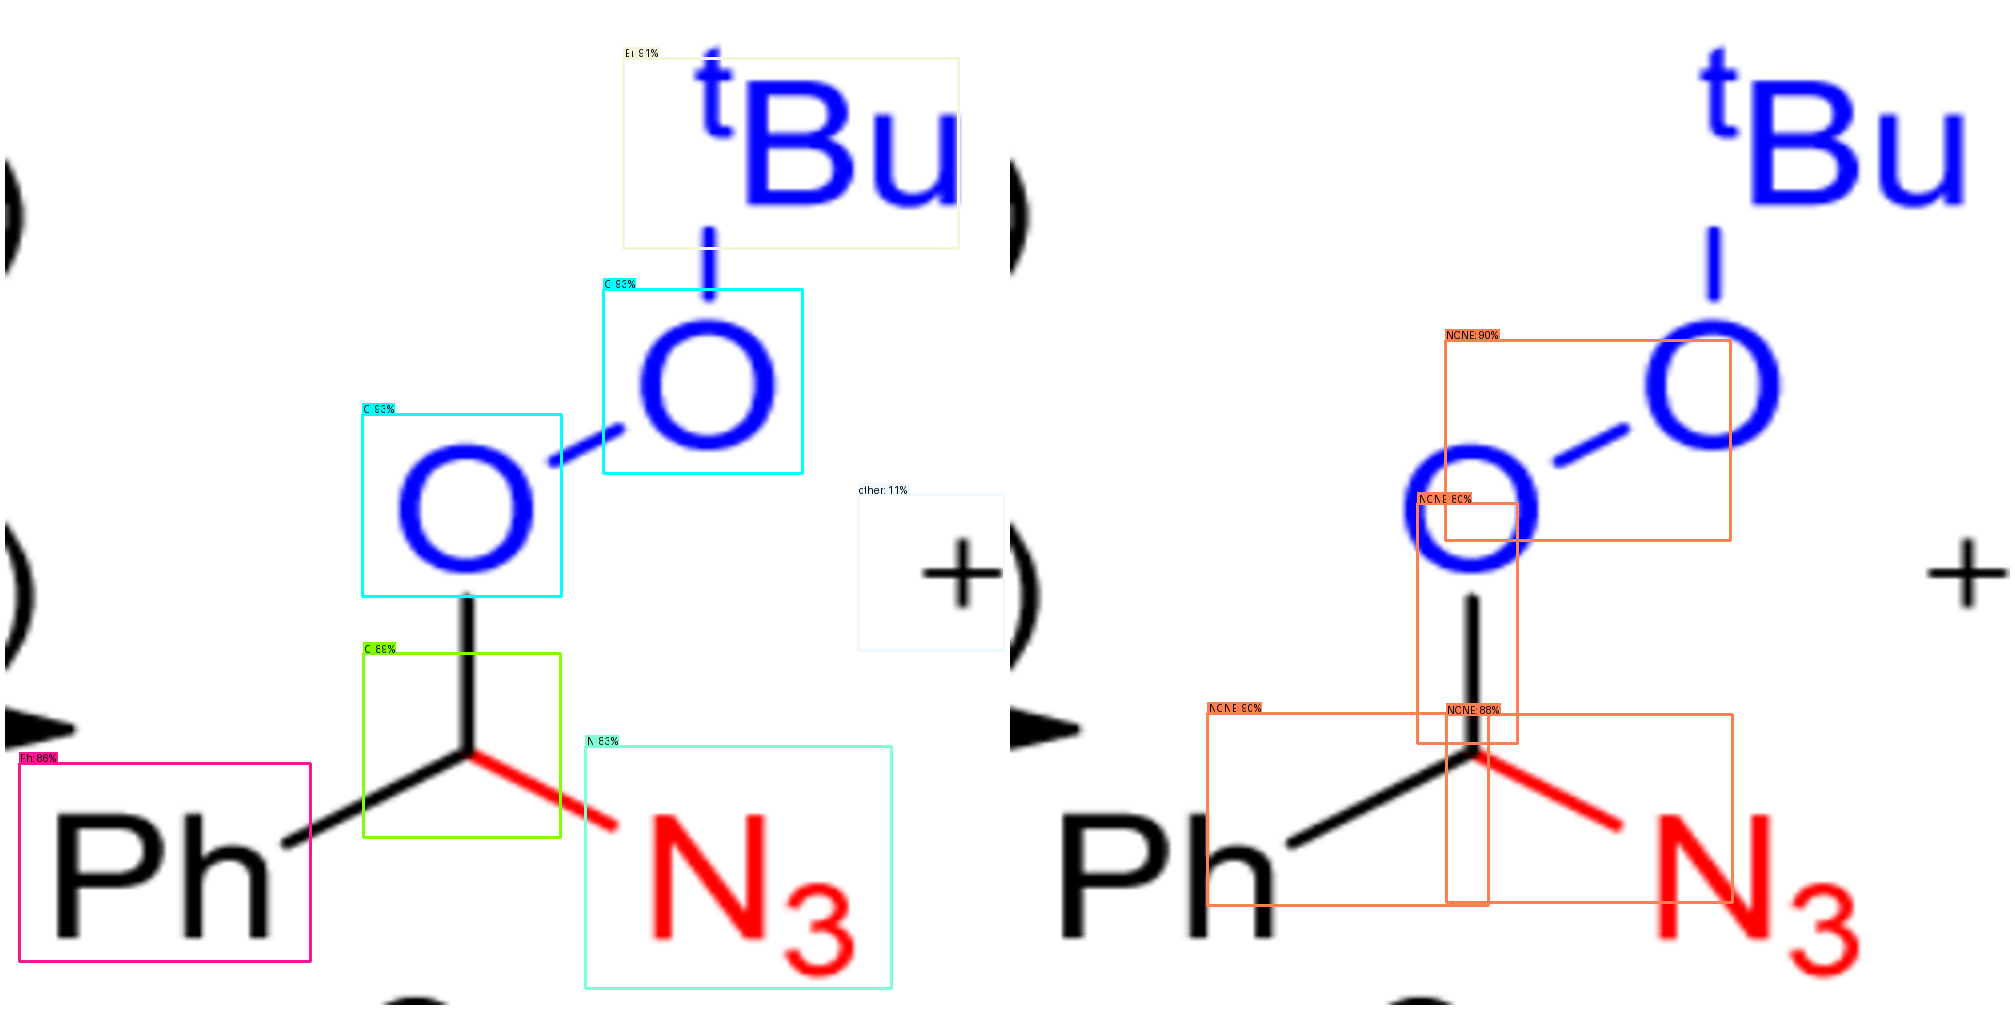

In [1516]:
print(f"atom score >0.1 bond score >0.2, then folllowed with NMS")
print(f"before OCR involved ")#
combined_img

In [1517]:

#check if ODD bonds with only one atom exisits, try add the atoms box for this bond
new_atoms, single_odd_b2a= Newbox_(atom_bbox,bond_bbox )
print(f"new_atoms {len(new_atoms)}")
if len(new_atoms)>0:
    for boxout in new_atoms:
        for k,arr in boxout.items():
            value_or_row=output[k]
            if arr.ndim == 1:
                output[k]=np.append(value_or_row, arr)
            elif arr.ndim >= 2:
                output[k] = np.concatenate([value_or_row, arr], axis=0)
            else:
                print('errprs, unkown conditions !!!@')

new_atoms 0


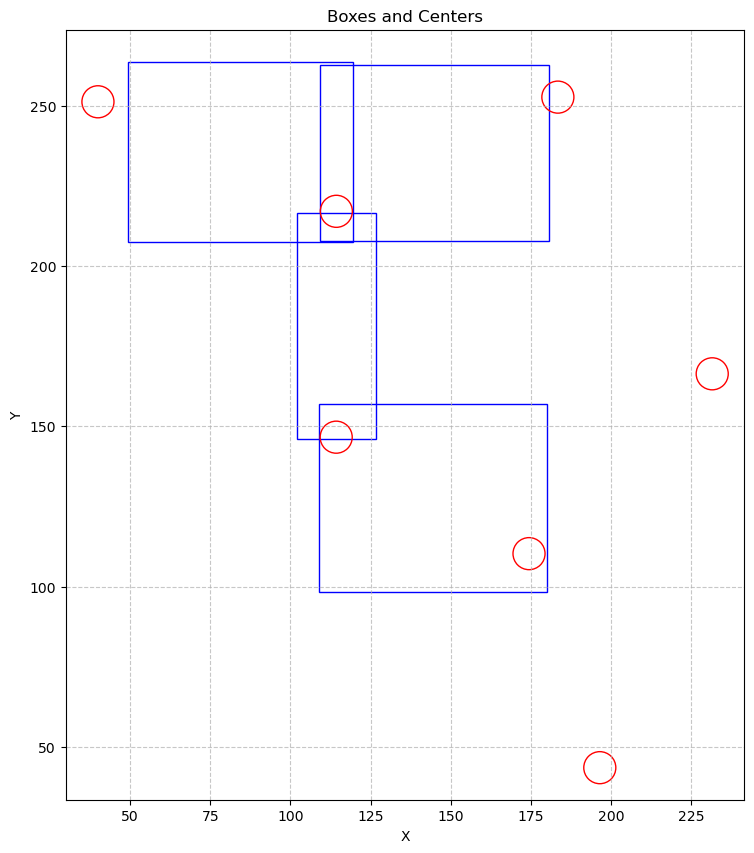

In [1518]:
view_box_center(bond_bbox,atom_centers)

In [1519]:
import cv2

def boxes_overlap(box1, box2):
    """
    检查两个边界框是否重叠
    box1, box2: [x1, y1, x2, y2]
    """
    return not (box1[2] < box2[0] or box1[0] > box2[2] or
                box1[3] < box2[1] or box1[1] > box2[3])
def calculate_center(box):
    """
    计算边界框的中心点
    """
    return np.array([(box[0] + box[2]) / 2, (box[1] + box[3]) / 2])
def merge_boxes(box1, box2):
    """
    合并两个边界框，返回新边界框 [x1, y1, x2, y2]
    """
    return [
        min(box1[0], box2[0]),
        min(box1[1], box2[1]),
        max(box1[2], box2[2]),
        max(box1[3], box2[3])
    ]


#extendal OCR used 
import cv2
# 初始化 PaddleOCR（支持英文和中文，需根据字符调整 lang）
ocr = PaddleOCR(
    use_angle_cls=True,
    lang='latin',use_space_char=True,use_debug=False,
    use_gpu=True if cv2.cuda.getCudaEnabledDeviceCount() > 0 else False)

ocr2 = ocr2 = PaddleOCR(use_angle_cls=True,use_gpu =False,use_debug=False,
            rec_algorithm='SVTR_LCNet', rec_model_dir='/home/jovyan/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer',
            lang="en") 

print(f"before  ocr chagned the atom class\n",[idx_to_labels[i] for i in atom_classes])
print(f"before  ocr chagned the atom class::total {len(atom_classes)}\n",[idx_to_labels[i] for i in atom_classes])


[2025/03/06 07:25:14] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/home/jovyan/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/home/jovyan/.paddleocr/whl/rec/latin/latin_PP-OCRv3_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_t

In [1520]:
for i in range(len(atom_classes)):
    print(i,idx_to_labels[atom_classes[i]],atom_bbox[i] )

0 O [ 89.44085  119.850235 139.12735  173.38263 ]
1 other [213.3148  143.55063 249.92245 189.23308]
2 C [ 89.74667 190.14206 138.91348 244.0585 ]
3 O [149.64705  83.23675 199.25772 137.31143]
4 N [145.19513 217.19244 221.71753 288.26663]
5 Br [154.65367   15.673216 238.4244    71.30085 ]
6 Ph [  3.5176687 222.20131    76.35866   280.35327  ]


In [1521]:
atombox_img=draw_objs(copy.deepcopy(img),
                    atom_bbox* [scale_x, scale_y, scale_x, scale_y],
                    atom_classes, atom_scores ,
                    category_index=idx_to_labels,
                    box_thresh=box_thresh,
                    line_thickness=3,
                    font='arial.ttf',
                    font_size=10)

bonbox_img=draw_objs(copy.deepcopy(img),
                    bond_bbox* [scale_x, scale_y, scale_x, scale_y],
                    bond_classes, bond_scores ,
                    category_index=idx_to_labels,
                    box_thresh=0.01,
                    line_thickness=3,
                    font='arial.ttf',
                    font_size=10)

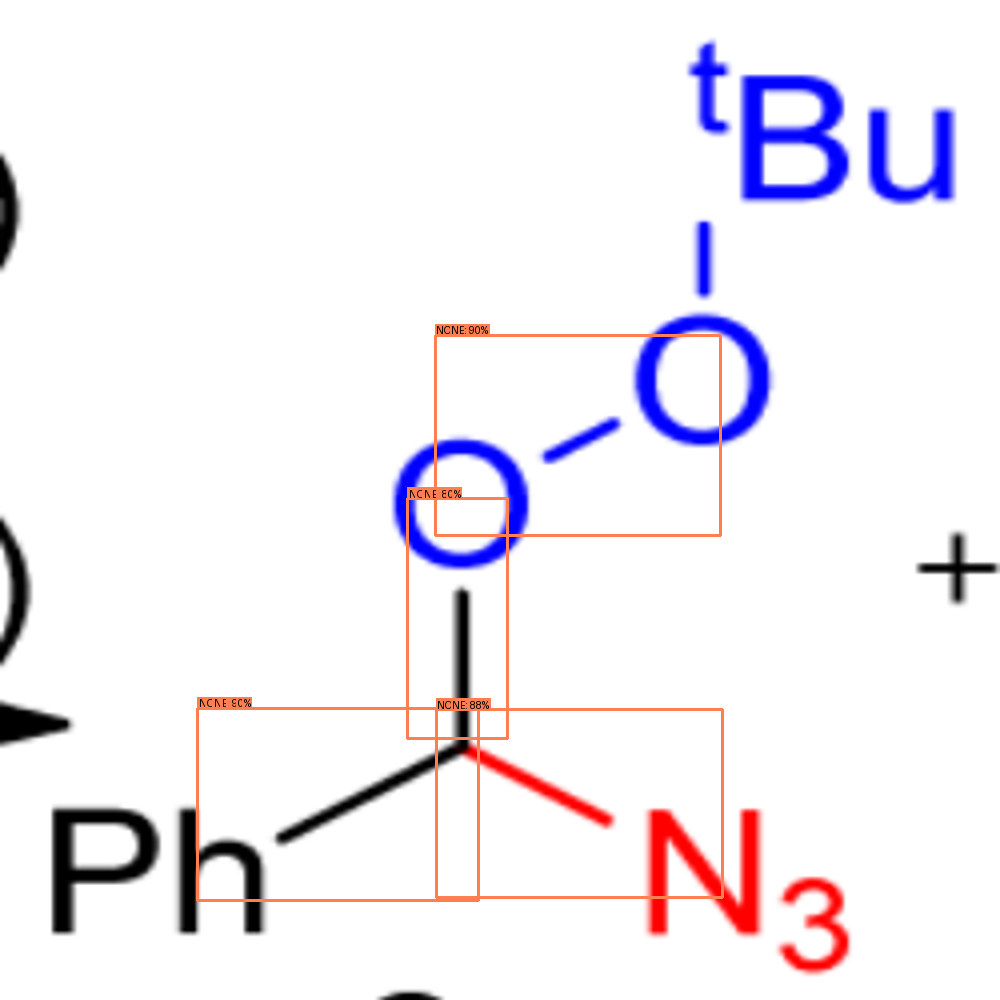

In [1522]:
bonbox_img

In [1523]:
#NOTE try to use OCR to help postprocess box adding and del
# 加载图像 OCR
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# 预处理图像突出下标
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)
print(_, thresh)
kernel = np.ones((2, 2), np.uint8)
dilated = cv2.dilate(thresh, kernel, iterations=1)
# cv2.imwrite("preprocessed.jpg", dilated)#NOTE comment if need checking
# result = ocr.ocr("preprocessed.jpg", cls=True)
#  ocr.ocr(image_npocr, cls=True, det=False)
result = ocr.ocr(dilated, cls=True)  # 直接传递 NumPy 数组
# 解析结果
text_boxes = []
text_contents = []
confidences = []
for line in result:
    print(line)
    for box_info in line:
        box = box_info[0]
        x_coords = [point[0] for point in box]
        y_coords = [point[1] for point in box]
        text_box = [min(x_coords), min(y_coords), max(x_coords), max(y_coords)]
        text = box_info[1][0]
        text_boxes.append(text_box)
        text_contents.append(text)
        confidences.append(box_info[1][1])
print("Detected text boxes:", text_boxes)
print("Detected text contents:", text_contents)
print("Confidences:", confidences)        
#after whole img OCRed

ai2text=dict()
ai2relplace=dict()
ai2rdkitlab_unknown=dict()#used when build mol
atom_centers = np.array([calculate_center(box) for box in atom_bbox])
tree = cKDTree(atom_centers)
for ti, text_box in enumerate(text_boxes):
    text_center = calculate_center(text_box)
    # 查找最近的 atom_center, assign OCR text2box
    distance, nearest_idx = tree.query(text_center)#TODO do we need add bond ??
    atom_box = atom_bbox[nearest_idx]
    ocr_text=text_contents[ti]
    if ocr_text in ['OH','HO']:
        ocr_text='O'
    elif ocr_text in ['SH','HS']:
        ocr_text='S'
    elif ocr_text in ['NH','HN']:
        ocr_text='N'
    elif ocr_text in ['CH','HC']:
        ocr_text='C'
    elif ocr_text=='0':
        ocr_text='O'
    elif ocr_text=='L':
        ocr_text='Li'
    over_flag=boxes_overlap(atom_box, text_box)
    print(f'text box overlap with atom box assign OCR text2box\n {ocr_text}to atombox {nearest_idx} ' )
    print(ocr_text,'text2box',nearest_idx, over_flag)
    if over_flag:
        # 仅当 atom_box 与 text_box 重叠时更新  update box coordinates and class label
        atom_bbox[nearest_idx]=text_box#update box coordinates from text detection box to atom box
        if ocr_text in ABBREVIATIONS:
            ai2relplace[nearest_idx]=ocr_text
            atom_classes[nearest_idx]=0#other or *repalce
            if ocr_text in lab2idx: atom_classes[nearest_idx]=lab2idx[ocr_text]
            # if atom_classes[nearest_idx] not in list(range(23,30))+[0]:#may still wrong pred class 27 to 24 etc
        elif ocr_text in ['H', 'C', 'O', 'N', 'Cl', 'Br', 'S', 'F', 'B', 'I', 'P', 'Si']:#  '*', I2M's defined atom types
            atom_classes[nearest_idx]=lab2idx[ocr_text]
        elif ocr_text in RGROUP_SYMBOLS or (ocr_text[0] == 'R' and ocr_text[1:].isdigit()):
            atom_classes[nearest_idx]=0#other or *repalce
        else:
            ai2rdkitlab_unknown[nearest_idx]=ocr_text#other unkonwn groups
            atom_classes[nearest_idx]=0#other or *repalce
        ai2text[nearest_idx]=ocr_text#record adjust ai ocr_text
print("ai2relplace,ai2rdkitlab_unknown",[ai2relplace,ai2rdkitlab_unknown])
print(f"adjust ai ocr_text::{ai2text}")
print(f"atom box num :{len(atom_bbox)}")

150.0 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[2025/03/06 07:25:16] ppocr DEBUG: dt_boxes num : 5, elapsed : 0.09589672088623047


[2025/03/06 07:25:16] ppocr DEBUG: cls num  : 5, elapsed : 0.05758261680603027
[2025/03/06 07:25:16] ppocr DEBUG: rec_res num  : 5, elapsed : 0.2702302932739258
[[[[174.0, 9.0], [249.0, 27.0], [239.0, 75.0], [163.0, 57.0]], ('tBu', 0.996035099029541)], [[[158.0, 93.0], [190.0, 93.0], [190.0, 127.0], [158.0, 127.0]], ('0', 0.9741092324256897)], [[[9.0, 235.0], [71.0, 235.0], [71.0, 276.0], [9.0, 276.0]], ('Ph', 0.99846351146698)]]
Detected text boxes: [[163.0, 9.0, 249.0, 75.0], [158.0, 93.0, 190.0, 127.0], [9.0, 235.0, 71.0, 276.0]]
Detected text contents: ['tBu', '0', 'Ph']
Confidences: [0.996035099029541, 0.9741092324256897, 0.99846351146698]
text box overlap with atom box assign OCR text2box
 tButo atombox 5 
tBu text2box 5 True
text box overlap with atom box assign OCR text2box
 Oto atombox 3 
O text2box 3 True
text box overlap with atom box assign OCR text2box
 Phto atombox 6 
Ph text2box 6 True
ai2relplace,ai2rdkitlab_unknown [{5: 'tBu', 6: 'Ph'}, {}]
adjust ai ocr_text::{5: 'tBu

In [1524]:
def has_boxes(data):
    #TO CHECK OCR detct used or not
    return isinstance(data, list) and len(data) > 0 and all(
        isinstance(item, list) and len(item) == 2 and 
        isinstance(item[0], list) and len(item[0]) == 4
        for item in data
    )

def AtomBox2bondBox(atom_box,bond_bbox):
    b_nei=[]
    overlap=True
    for bi,bb in enumerate(bond_bbox):
        overlap_flag=boxes_overlap(bb, atom_box)#TODO use tghe atom bond box overlap get bond atom mapping,then built mol
        if overlap_flag:
            b_nei.append(bi)
    if len(b_nei)==0:
        # delt_hei.append(hei)
        overlap=False
    return overlap, b_nei

In [1525]:
#for all  heavy atom labels, consider N3 pred as N, or other cases, I2M not good as paddle on ABC 
atomcorp_img = Image.open(image_path).convert('RGB')
atomcorp_img1k=atomcorp_img.resize([1000,1000])
text_contents_star=[]
text_confidences_star=[]
text_boxes_star=[]
boxid2del=dict()
print(f"has atom_bbox number {len(atom_bbox)}")
for i,box in enumerate(atom_bbox):
    if i in ai2text: continue
    abox =box* [scale_x, scale_y, scale_x, scale_y]
    cropped_img=atomcorp_img1k.crop(abox)#if use the small ori image will not get infos
    image_npocr = np.array(cropped_img)
    result_ocr= ocr2.ocr(image_npocr, det=False)#,cls=True,use_debug=False, det=False)#det fale not box but get rcongized more 
    # result_ocr= ocr.ocr(image_npocr, cls=True, det=False)#,cls=True, det=False)#det fale not box but get rcongized more 
    if result_ocr:
        for line in result_ocr:
            # print(line)##
            if line:
                box_flag=has_boxes(line)
                for box_info in line:
                    # print(len(box_info))
                    if not box_flag:
                        text=box_info[0]
                        #[^a-zA-Z0-9\*\-\+] 表示匹配除了字母、数字、*、- 和 + 之外的所有字符。
                        text=re.sub(r'[^a-zA-Z0-9\*\-\+]', '', text)#remove special chars
                        score_=box_info[1]
                        text_contents_star.append(text)
                        text_confidences_star.append(score_)
                    else:#when paddleOCRuse detection model get text box info
                        box = box_info[0]
                        x_coords = [point[0] for point in box]
                        y_coords = [point[1] for point in box]
                        text_box = [min(x_coords), min(y_coords), max(x_coords), max(y_coords)]
                        text = box_info[1][0]
                        text=re.sub(r'[^a-zA-Z0-9\*\-\+]', '', text)#remove special chars
                        text_boxes_star.append(text_box)
                        text_contents_star.append(text)
                        score_=box_info[1][1]
                        text_confidences_star.append(score_)
                    # print(f'OCR text:: {text} score ::{box_info}')
                    if text in ['OH','HO']:
                        text='O'
                    elif text in ['SH','HS']:
                        text='S'
                    elif text in ['NH','HN']:
                        text='N'
                    elif text in ['CH','HC']:
                        text='C'

                    #TOD add more simpfiled 
                    if text=='0':
                        atom_classes[i]=lab2idx['O']
                    elif text in ['H', 'C', 'O', 'N', 'Cl', 'Br', 'S', 'F', 'B', 'I', 'P', 'Si']:
                        atom_classes[i]=lab2idx[text]#need update to keep H following Heavy
                    else:
                        overlap, b_nei=AtomBox2bondBox(atom_bbox[i],bond_bbox)
                        if not overlap:
                            if text not in ELEMENTS:
                                # print(f"new cases::{text} for atombox {i}  {atom_bbox[i]}check how to fix it  !!!")
                                # print(f'OCR text:: {text} score ::{box_info}||atom clss::{idx_to_labels[atom_classes[i]]} {atom_scores[i]}')
                                boxid2del[i]= [text,idx_to_labels[atom_classes[i]]]#will delt this atom box infos
                        else:
                            if text != idx_to_labels[atom_classes[i]]:
                                if atom_scores[i]<=score_:
                                    if text in RGROUP_SYMBOLS or text in ABBREVIATIONS:
                                        ai2relplace[i]=text
                                        atom_classes[i]=0
                                    elif text in ['H', 'C', 'O', 'N', 'Cl', 'Br', 'S', 'F', 'B', 'I', 'P', 'Si']:
                                        atom_classes[i]=idx_to_labels[text]
                                    else:
                                        ai2relplace[i]=text
                                        atom_classes[i]=0
                                        
                            # if text in lab2idx and 

has atom_bbox number 7


In [1526]:

print("ai2relplace,ai2rdkitlab_unknown",[ai2relplace,ai2rdkitlab_unknown])
print(f"considering delet atomb box :{boxid2del}")
print(f"atombox {atom_classes}\n",[idx_to_labels[i] for i in atom_classes])


ai2relplace,ai2rdkitlab_unknown [{5: 'tBu', 6: 'Ph', 4: 'N3'}, {}]
considering delet atomb box :{1: ['+', 'other']}
atombox [ 2  0  1  2  0  0 28]
 ['O', 'other', 'C', 'O', 'other', 'other', 'Ph']


atom bbox num 6
atombox [ 2  1  2  0  0 28]
 ['O', 'C', 'O', 'other', 'other', 'Ph']


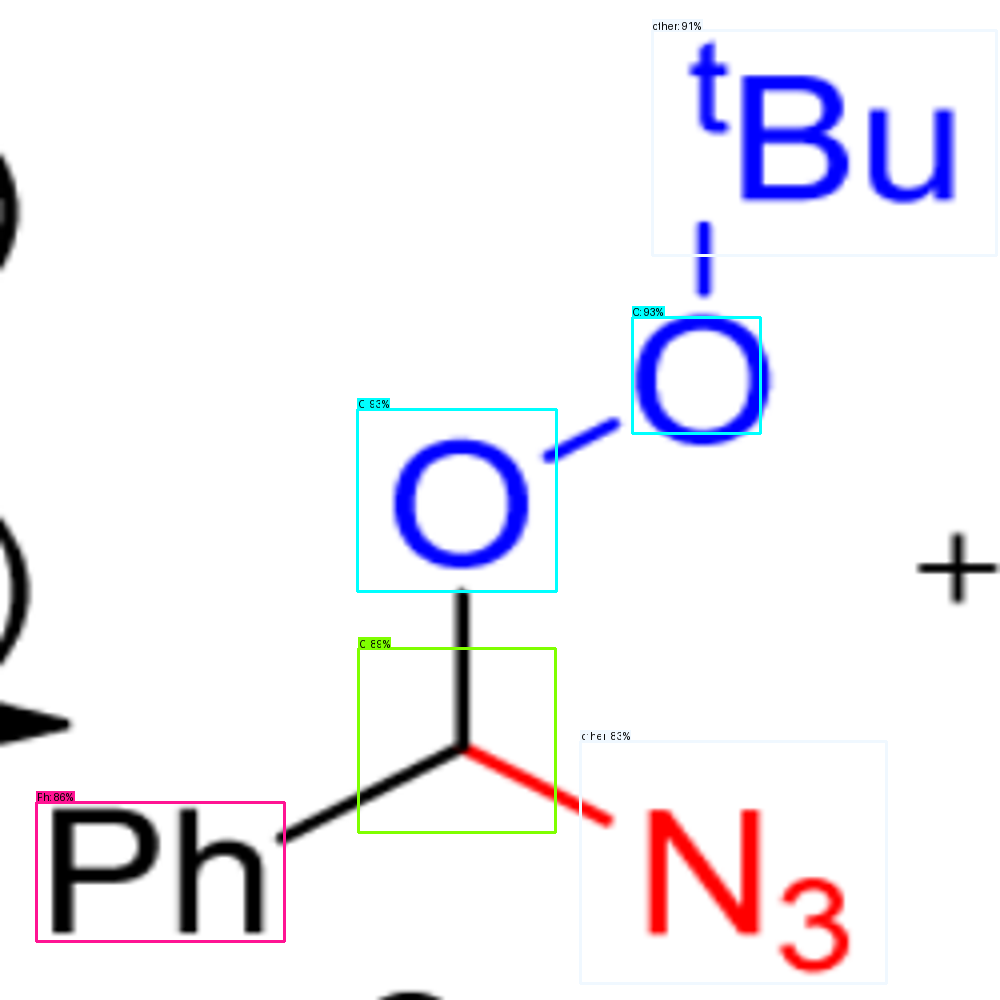

In [1527]:
if len(boxid2del)>0:
    for k,v in  boxid2del.items():
        atom_classes=np.delete(atom_classes,k,axis=0)
        atom_scores=np.delete(atom_scores,k,axis=0)
        atom_bbox=np.delete(atom_bbox,k,axis=0)

print(f"atom bbox num {len(atom_bbox)}")
print(f"atombox {atom_classes}\n",[idx_to_labels[i] for i in atom_classes])

atombox_img=draw_objs(copy.deepcopy(img),
                    atom_bbox* [scale_x, scale_y, scale_x, scale_y],
                    atom_classes, atom_scores ,
                    category_index=idx_to_labels,
                    box_thresh=box_thresh,
                    line_thickness=3,
                    font='arial.ttf',
                    font_size=10)
atombox_img

In [ ]:
# 初始化映射和孤立原子列表, need OCR help then do this be better
b2a = dict()
a2b = dict()
isolated_ais = []
# 第一步：构建 bond 到 atom 的映射，并计算 distance_threshold
bond_distances = []
for bi, bb in enumerate(bond_bbox):
    overlapped_atoms = []
    overlapped_abox = []
    for ai, aa in enumerate(atom_bbox):
        overlap_flag = boxes_overlap(bb, aa)
        if overlap_flag:
            overlapped_atoms.append(ai)
            overlapped_abox.append(aa)
            if bi not in b2a.keys():
                b2a[bi] = [ai]
            else:
                b2a[bi].append(ai)
    if len(overlapped_atoms) == 2:
        center1 = calculate_center(atom_bbox[overlapped_atoms[0]])
        center2 = calculate_center(atom_bbox[overlapped_atoms[1]])
        distance = np.linalg.norm(center1 - center2)
        bond_distances.append(distance)
        # print(f"Bond {bi} connects atoms {overlapped_atoms}, distance: {distance:.2f}")
    elif len(overlapped_atoms) == 1:
        print(f"single bond - atom still exists for bond {bi}")

# 动态计算 distance_threshold
distance_threshold = max(bond_distances) if bond_distances else 100.0  # 默认值 10 如果无 bond
distance_threshold_min = min(bond_distances) if bond_distances else 100.0  # 默认值 10 如果无 bond
print(f"Calculated distance_threshold: {distance_threshold:.2f}")

# 第二步：构建 atom 到 bond 的映射，并检测孤立原子
for ai, aa in enumerate(atom_bbox):
    b_nei = []
    for bi, bb in enumerate(bond_bbox):
        overlap_flag = boxes_overlap(bb, aa)
        if overlap_flag:
            b_nei.append(bi)
        # else:
        #     box_score = atom_scores[ai]
        #     # print(f"{ai} atom box score {box_score} without overlap any bond boxes")
        #     if box_score < 0.5:
        #         if ai not in isolated_ais:
        #             isolated_ais.append(ai)
        #             print(f"should delete this {ai}")
    a2b[ai] = b_nei
    if a2b[ai] ==[]:
        if ai not in isolated_ais:
            isolated_ais.append(ai)

# 第三步：处理孤立原子，尝试合并或删除
updated_atom_bbox = atom_bbox.copy()
updated_atom_classes = atom_classes.copy()
updated_atom_scores = atom_scores.copy()
print(f"atom bbox num {len(atom_bbox)}")
new_bond_bbox=[]
isolated_ais=sorted(isolated_ais,reverse=True)#avoid delte atom with index errors
for isolated_ai in isolated_ais[:]:  # 使用切片避免修改列表期间迭代问题
    isolated_box = atom_bbox[isolated_ai]
    isolated_center = calculate_center(isolated_box)
    min_distance = float('inf')
    nearest_ai = -1
    # 找到最近的非孤立原子
    for ai, aa in enumerate(atom_bbox):
        if ai not in isolated_ais and ai != isolated_ai:
            center = calculate_center(aa)
            distance = np.linalg.norm(isolated_center - center)
            if distance < min_distance:
                min_distance = distance
                nearest_ai = ai
    # 合并或删除逻辑
    if nearest_ai != -1:
        if min_distance <=distance_threshold:
            nearest_box = atom_bbox[nearest_ai]
            nearest_class = atom_classes[nearest_ai]
            #NOTE based ont the class and ovelap bond box to adjust
            overlap1,bondnei=AtomBox2bondBox(nearest_box,bond_bbox)
            if len(bondnei)==1:#could be add two other bond
                new_bc = (atom_centers[nearest_ai] + atom_centers[nearest_ai])*0.5
                print(new_bc)
                new_bondbox=[new_bc[0] - distance_threshold_min*0.5,new_bc[1] - distance_threshold_min*0.5,
                             new_bc[0] + distance_threshold_min*0.5,new_bc[1] + distance_threshold_min*0.5]
                new_bond_bbox.append(new_bondbox)
                print(f'add new bond box new_bc')
            else:
                new_box = merge_boxes(isolated_box, nearest_box)
                updated_atom_bbox[nearest_ai] = new_box
                chosed_score_ = max(atom_scores[isolated_ai], atom_scores[nearest_ai])
                updated_atom_scores[nearest_ai] = chosed_score_
                if chosed_score_>=0.5:
                    if chosed_score_==atom_scores[isolated_ai]:
                        updated_atom_classes[nearest_ai] = 0 # mrege replaced with *
                    # else:
                    #     updated_atom_classes[nearest_ai] = atom_classes[nearest_ai]  # 保留较高 score 的类别
                updated_atom_bbox = np.delete(updated_atom_bbox, isolated_ai, axis=0)#after mreged need del it
                # updated_atom_bbox = np.delete(updated_atom_bbox, isolated_ai, axis=0)
                updated_atom_classes = np.delete(updated_atom_classes, isolated_ai)
                updated_atom_scores = np.delete(updated_atom_scores, isolated_ai)
                print(f"Merged atom {isolated_ai} into {nearest_ai}, new box: {new_box}")
                isolated_ais.remove(isolated_ai)
        elif atom_scores[isolated_ai] < 0.5:
            # 删除低分孤立原子
            updated_atom_bbox = np.delete(updated_atom_bbox, isolated_ai, axis=0)
            updated_atom_classes = np.delete(updated_atom_classes, isolated_ai)
            updated_atom_scores = np.delete(updated_atom_scores, isolated_ai)
            print(f"Deleted isolated atom {isolated_ai} with score {atom_scores[isolated_ai]}")
            # 更新索引，因为数组维度变化
            isolated_ais = [i if i < isolated_ai else i - 1 for i in isolated_ais if i != isolated_ai]
        else:
            print(f"Kept isolated atom {isolated_ai} with score {atom_scores[isolated_ai]} >= 0.5")
    else:
        if atom_scores[isolated_ai] < 0.5:
            updated_atom_bbox = np.delete(updated_atom_bbox, isolated_ai, axis=0)
            updated_atom_classes = np.delete(updated_atom_classes, isolated_ai)
            updated_atom_scores = np.delete(updated_atom_scores, isolated_ai)
            print(f"Deleted isolated atom {isolated_ai} with score {atom_scores[isolated_ai]}")
            isolated_ais = [i if i < isolated_ai else i - 1 for i in isolated_ais if i != isolated_ai]
        else:
            print(f"Kept isolated atom {isolated_ai} with score {atom_scores[isolated_ai]} >= 0.5")

if len(new_bond_bbox)>0:
    for i,bond_box in enumerate(new_bond_bbox):
        bond_bbox= np.concatenate(bond_bbox,bond_box,axis=0)
        bond_classes= np.concatenate(bond_classes,np.array([]),axis=0)
        bond_bbox= np.concatenate(bond_bbox,bond_box,axis=0)

Calculated distance_threshold: 83.66
atom bbox num 6
[114.33007812 217.10028076]
add new bond box new_bc


In [1529]:
len(atom_bbox)

6

In [1530]:
#c2a a2c
#charge atom idx maping
if len(charges_classes) > 0:
    # print(charges_bbox,charges_classes,len(charges_classes))
    kdt = cKDTree(atom_centers)
    atid_list=list(range(len(atom_centers)))
    used_charge_indices=set()
    c2a=dict()
    for i, (x,y) in enumerate(charges_centers):
        overlapped_abox=[]
        cc=charges_bbox[i]
        for ai, aa in  enumerate(atom_bbox):
            overlap_flag=boxes_overlap(cc, aa)
            ac_iou=calculate_iou(cc, aa)
            charge_=charges_classes[i]
            charge_score=charges_scores[i]
            if overlap_flag:
                if i in c2a:
                    c2a[i].append(ai) 
                else:
                    c2a[i]=[ai] 
                if ai not in atid_list:
                    print(f"Warning: ai {ai} is out of range for atom_list.")
                    continue  # 跳过当前循环迭代
    # idx_to_labels[charges_classes[0]]
    a2c=dict()
    for ci,v in c2a.items():
        charge_=idx_to_labels[charges_classes[ci]]
        if len(v)==1:
            a2c[v[0]]=ci
        else:
            for ai in v:
                ats=idx_to_labels[atom_classes[ai]]
                if ats=='other':
                    ats='*'
                if ats in ['F','Cl','I','Br','O'] and int(charge_)<0:
                    a2c[ai]=ci
                elif ats in ['N','H','P'] and int(charge_)>0:
                    a2c[ai]=ci
                else:
                    print(f'unusuaal case charge {charge_} with atom {ats}!!')
                

In [1531]:
#update box infos again with check3
atom_bbox= updated_atom_bbox 
atom_classes= updated_atom_classes 
atom_scores= updated_atom_scores 


In [1532]:
check3=True
if check3:#after isolate remote delet,  isolate close merged
    padding=5
    # box_thresh=0.3
    atombox_img=draw_objs(copy.deepcopy(img),
                        atom_bbox* [scale_x, scale_y, scale_x, scale_y],
                        atom_classes, atom_scores ,
                        category_index=idx_to_labels,
                        box_thresh=box_thresh,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)
    
    bonbox_img=draw_objs(copy.deepcopy(img),
                        bond_bbox* [scale_x, scale_y, scale_x, scale_y],
                        bond_classes, bond_scores ,
                        category_index=idx_to_labels,
                        box_thresh=0.01,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)
    # Get sizes of the individual images
    atom_width, atom_height = atombox_img.size
    bon_width, bon_height = bonbox_img.size
    combined_width = atom_width + bon_width + padding * 3
    combined_height = max(atom_height, bon_height) + padding * 2
    combined_img = Image.new('RGB', (combined_width, combined_height), color=(255, 255, 255))  # White background
    # Paste the images onto the new canvas
    combined_img.paste(atombox_img, (padding, padding))  # Top-left
    combined_img.paste(bonbox_img, (atom_width + padding * 2, padding))

before OCR involved 


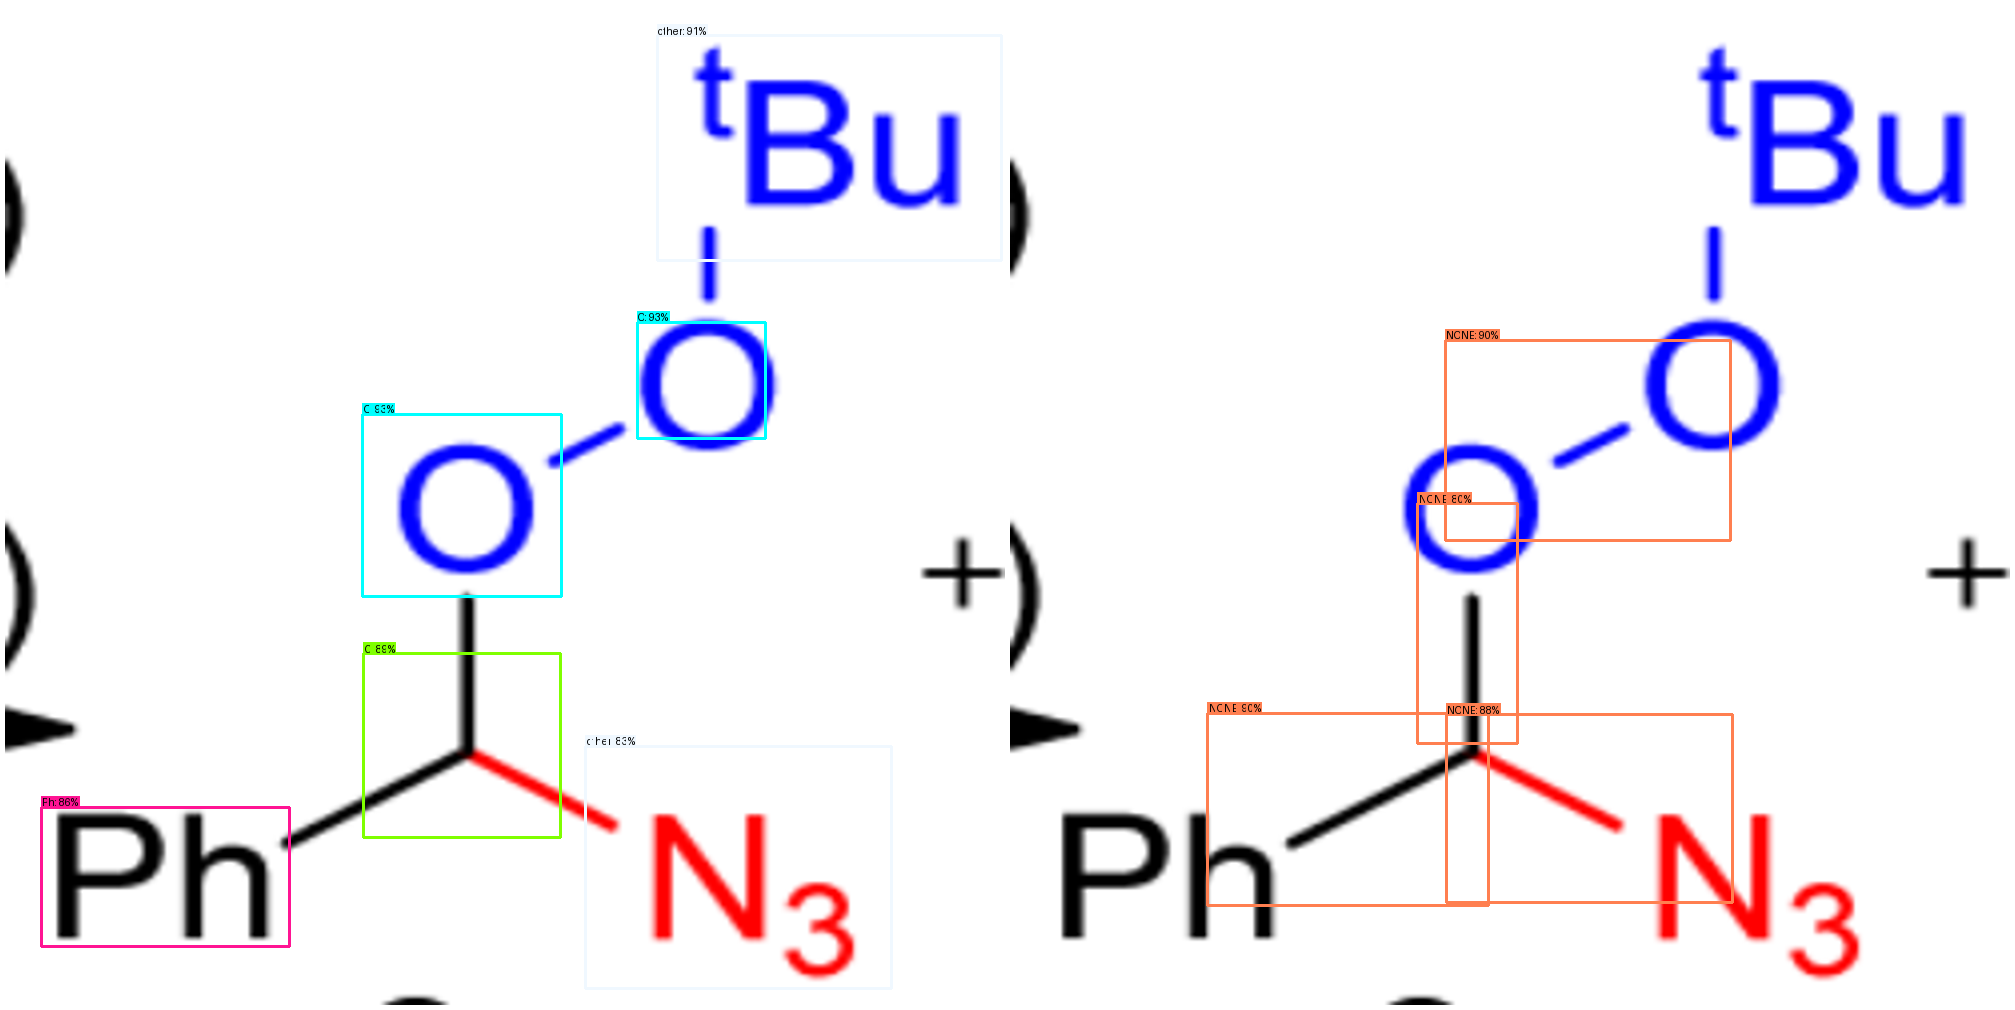

In [1533]:
print(f"before OCR involved ")#after OCR and remove or add, then adjust the box orders
combined_img

In [1534]:
xxxxx

NameError: name 'xxxxx' is not defined

In [ ]:
# if len(charges_bbox)>0:
#     charge_img=draw_objs(copy.deepcopy(img),
#                         charges_bbox* [scale_x, scale_y, scale_x, scale_y],
#                         charges_classes, charges_scores ,
#                         category_index=idx_to_labels,
#                         box_thresh=0.01,
#                         line_thickness=3,
#                         font='arial.ttf',
#                         font_size=10)
#     # Get sizes of the individual images

#     charge_img

In [ ]:
#TODO for real data set we have to need this ocr to adjust the box postion for this current version
#then oupt the right box for training

In [ ]:
#extendal OCR used 
import cv2
# 初始化 PaddleOCR（支持英文和中文，需根据字符调整 lang）
ocr = PaddleOCR(
    use_angle_cls=True,
    lang='latin',use_space_char=True,use_debug=False,
    use_gpu=True if cv2.cuda.getCudaEnabledDeviceCount() > 0 else False)

ocr2 = ocr2 = PaddleOCR(use_angle_cls=True,use_gpu =False,use_debug=False,
            rec_algorithm='SVTR_LCNet', rec_model_dir='/home/jovyan/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer',
            lang="en") 

print(f"before  ocr chagned the atom class\n",[idx_to_labels[i] for i in atom_classes])

[2025/03/05 09:03:26] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/home/jovyan/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/home/jovyan/.paddleocr/whl/rec/latin/latin_PP-OCRv3_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_t

In [ ]:
# 加载图像 OCR
# image_path = "chemical_structure.jpg"  # 替换为你的图片路径
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# 预处理图像突出下标
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)
kernel = np.ones((2, 2), np.uint8)
dilated = cv2.dilate(thresh, kernel, iterations=1)
# cv2.imwrite("preprocessed.jpg", dilated)#NOTE comment if need checking
# result = ocr.ocr("preprocessed.jpg", cls=True)
result = ocr.ocr(dilated, cls=True)  # 直接传递 NumPy 数组

# 解析结果
text_boxes = []
text_contents = []
confidences = []
for line in result:
    print(line)
    for box_info in line:
        box = box_info[0]
        x_coords = [point[0] for point in box]
        y_coords = [point[1] for point in box]
        text_box = [min(x_coords), min(y_coords), max(x_coords), max(y_coords)]
        text = box_info[1][0]
        text_boxes.append(text_box)
        text_contents.append(text)
        confidences.append(box_info[1][1])

print("Detected text boxes:", text_boxes)
print("Detected text contents:", text_contents)
print("Confidences:", confidences)
print(f"finished intact image OCR")


[2025/03/05 09:44:18] ppocr DEBUG: dt_boxes num : 5, elapsed : 0.05227375030517578
[2025/03/05 09:44:18] ppocr DEBUG: cls num  : 5, elapsed : 0.02771925926208496
[2025/03/05 09:44:18] ppocr DEBUG: rec_res num  : 5, elapsed : 0.2140212059020996
[[[[174.0, 9.0], [249.0, 27.0], [239.0, 75.0], [163.0, 57.0]], ('tBu', 0.996035099029541)], [[[158.0, 93.0], [190.0, 93.0], [190.0, 127.0], [158.0, 127.0]], ('0', 0.9741092324256897)], [[[9.0, 235.0], [71.0, 235.0], [71.0, 276.0], [9.0, 276.0]], ('Ph', 0.99846351146698)]]
Detected text boxes: [[163.0, 9.0, 249.0, 75.0], [158.0, 93.0, 190.0, 127.0], [9.0, 235.0, 71.0, 276.0]]
Detected text contents: ['tBu', '0', 'Ph']
Confidences: [0.996035099029541, 0.9741092324256897, 0.99846351146698]


In [ ]:
#assign text 2 box based on overlapping
ai2relplace=dict()
ai2rdkitlab=dict()#used when build mol
atom_centers = np.array([calculate_center(box) for box in atom_bbox])
tree = cKDTree(atom_centers)
for ti, text_box in enumerate(text_boxes):
    text_center = calculate_center(text_box)
    # 查找最近的 atom_center
    distance, nearest_idx = tree.query(text_center)#TODO do we need add bond ??
    atom_box = atom_bbox[nearest_idx]
    ocr_text=text_contents[ti]
    if ocr_text in ['OH','HO']:
        ocr_text='O'
    elif ocr_text in ['SH','HS']:
        ocr_text='S'
    elif ocr_text in ['NH','HN']:
        ocr_text='N'
    elif ocr_text in ['CH','HC']:
        ocr_text='C'
    elif ocr_text=='0':
        ocr_text='O'
    elif ocr_text=='L':
        ocr_text='Li'
    over_flag=boxes_overlap(atom_box, text_box)
    print(ocr_text,'XXXX', over_flag)#check score label 


tBu XXXX False
O XXXX True
Ph XXXX True


In [ ]:
#TODO check each box splitely

In [ ]:
ai2relplace=dict()
ai2rdkitlab=dict()#used when build mol
atom_centers = np.array([calculate_center(box) for box in atom_bbox])
tree = cKDTree(atom_centers)
for ti, text_box in enumerate(text_boxes):
    text_center = calculate_center(text_box)
    # 查找最近的 atom_center
    distance, nearest_idx = tree.query(text_center)#TODO do we need add bond ??
    atom_box = atom_bbox[nearest_idx]
    ocr_text=text_contents[ti]
    if ocr_text in ['OH','HO']:
        ocr_text='O'
    elif ocr_text in ['SH','HS']:
        ocr_text='S'
    elif ocr_text in ['NH','HN']:
        ocr_text='N'
    elif ocr_text in ['CH','HC']:
        ocr_text='C'
    elif ocr_text=='0':
        ocr_text='O'
    elif ocr_text=='L':
        ocr_text='Li'
    over_flag=boxes_overlap(atom_box, text_box)
    print(ocr_text,'XXXX', over_flag)

    if over_flag:
        # 仅当 atom_box 与 text_box 重叠时更新
        atom_bbox[nearest_idx]=text_box#update text box to atom
        if ocr_text in ABBREVIATIONS:
            ai2relplace[nearest_idx]=ocr_text
            atom_classes[nearest_idx]=0#other or *repalce
        elif ocr_text in ['H', 'C', 'O', 'N', 'Cl', 'Br', 'S', 'F', 'B', 'I', 'P', 'Si']:#  '*', I2M's defined atom types
            atom_classes[nearest_idx]=lab2idx[ocr_text]
        elif ocr_text in RGROUP_SYMBOLS or (ocr_text[0] == 'R' and ocr_text[1:].isdigit()):
            atom_classes[nearest_idx]=0#other or *repalce
        else:
            ai2rdkitlab[nearest_idx]=ocr_text#other unkonwn groups
            atom_classes[nearest_idx]=0#other or *repalce



In [ ]:
print("ai2relplace,ai2rdkitlab",[ai2relplace,ai2rdkitlab])

ai2relplace,ai2rdkitlab [{4: 'Ph'}, {}]


In [ ]:
#for inter heavy atom labels
star_mask = np.array([True if ins==0 or ins==29 else False for ins in atom_classes])
star_mask_indices = np.where(star_mask)[0]
dilated_img = Image.open(image_path).convert('RGB')
# dilated_img=Image.fromarray(dilated)
dilated_img1k=dilated_img.resize([1000,1000])
text_boxes_star = []
text_contents_star = []
confidences_star = []
print(f"star_mask_indices {star_mask_indices}")
for i in star_mask_indices:
    if i not in ai2relplace and i not in ai2rdkitlab:#I2M predicted * not in OCR detected
        abox=atom_bbox[i] * [scale_x, scale_y, scale_x, scale_y]
        cropped_img=dilated_img1k.crop(abox)#if use the small ori image will not get infos
        image_npocr = np.array(cropped_img)
        result_ocr= ocr2.ocr(image_npocr, det=False)#,cls=True, det=False)#det fale not box but get rcongized more 
        # result_ocr= ocr2.ocr(image_npocr,cls=True, det=True)
        if result_ocr:
            # print(result_ocr)
            # s_, score_ =result_ocr[0][0]
            # print(f'ocr::idx:{i_}',s_, score_ )
            for line in result_ocr:
                print(line)
                if line:
                    for box_info in line:
                        if len(box_info)==2:
                            text=box_info[0]
                            #[^a-zA-Z0-9\*\-\+] 表示匹配除了字母、数字、*、- 和 + 之外的所有字符。
                            text=re.sub(r'[^a-zA-Z0-9\*\-\+]', '', text)#remove special chars
                            score_=box_info[1]
                            text_contents_star.append(text)
                            confidences_star.append(score_)
                        else:
                            box = box_info[0]
                            x_coords = [point[0] for point in box]
                            y_coords = [point[1] for point in box]
                            text_box = [min(x_coords), min(y_coords), max(x_coords), max(y_coords)]
                            text = box_info[1][0]
                            text=re.sub(r'[^a-zA-Z0-9\*\-\+]', '', text)#remove special chars
                            text_boxes_star.append(text_box)
                            text_contents_star.append(text)
                            confidences_star.append(box_info[1][1])
                        if text in ['OH','HO']:
                            text='O'
                        elif text in ['SH','HS']:
                            text='S'
                        elif text in ['NH','HN']:
                            text='N'
                        elif text in ['CH','HC']:
                            text='C'
                        #TOD add more simpfiled 
                        if text=='0':
                            atom_classes[i]=lab2idx['O']
                        elif text in ['H', 'C', 'O', 'N', 'Cl', 'Br', 'S', 'F', 'B', 'I', 'P', 'Si']:
                            atom_classes[i]=lab2idx[text]#need update to keep H following Heavy
                        else:
                            print(f"new cases, check how to fix it  !!!")

star_mask_indices [4]


In [ ]:
# 找到 'H' 的索引, H after Heavy
h_indices = np.where(atom_classes == lab2idx['H'])[0]
non_h_indices = np.where(atom_classes != lab2idx['H'])[0]
# print(h_indices,non_h_indices)
# 重新排序
new_order = np.concatenate((non_h_indices, h_indices)).astype(np.int64)
atom_classes = atom_classes[new_order]
atom_bbox = atom_bbox[new_order]
atom_centers = atom_centers[new_order]
atom_scores = atom_scores[new_order]
# 识别涉及 'H' 的 bond
h_bond_indices = []
for bi in b2a:#b2a old 
    if any(ai in h_indices for ai in b2a[bi]):
        h_bond_indices.append(bi)
non_h_bond_indices = [bi for bi in range(len(bond_bbox)) if bi not in h_bond_indices]
# 重新排序 bond with H after noHbond
new_bond_order = np.concatenate((non_h_bond_indices, h_bond_indices)).astype(np.int64)
bond_bbox = bond_bbox[new_bond_order]
bond_classes = bond_classes[new_bond_order]
bond_scores = bond_scores[new_bond_order]
bond_centers = bond_centers[new_bond_order]


In [ ]:
non_h_bond_indices, h_bond_indices

([0, 1, 2, 3], [])

In [ ]:
print(f"need to expand group: {ai2relplace}\n ocr2rdkit {ai2rdkitlab}")
print(f"after ocr helped, atom class:",[idx_to_labels[i] for i in atom_classes])

need to expand group: {4: 'Ph'}
 ocr2rdkit {}
after ocr helped, atom class: ['O', 'C', 'O', 'N', 'other']


In [ ]:
#update a2b b2a a2c c2a
# 初始化映射和孤立原子列表
b2a = dict()
a2b = dict()
isolated_ais = []
# 第一步：构建 bond 到 atom 的映射，并计算 distance_threshold
bond_distances = []
for bi, bb in enumerate(bond_bbox):#both bond atom box reodered keep H last
    overlapped_atoms = []
    overlapped_abox = []
    for ai, aa in enumerate(atom_bbox):
        overlap_flag = boxes_overlap(bb, aa)
        if overlap_flag:
            overlapped_atoms.append(ai)
            overlapped_abox.append(aa)
            if bi not in b2a.keys():
                b2a[bi] = [ai]
            else:
                b2a[bi].append(ai)
    if len(overlapped_atoms) == 2:
        center1 = calculate_center(atom_bbox[overlapped_atoms[0]])
        center2 = calculate_center(atom_bbox[overlapped_atoms[1]])
        distance = np.linalg.norm(center1 - center2)
        bond_distances.append(distance)
        # print(f"Bond {bi} connects atoms {overlapped_atoms}, distance: {distance:.2f}")
    elif len(overlapped_atoms) == 1:
        print(f"single bond - atom still exists for bond {bi}")
# 动态计算 distance_threshold
distance_threshold = max(bond_distances) if bond_distances else 100.0  # 默认值 10 如果无 bond
print(f"Calculated distance_threshold: {distance_threshold:.2f}")
# 第二步：构建 atom 到 bond 的映射，并检测孤立原子
for ai, aa in enumerate(atom_bbox):
    b_nei = []
    for bi, bb in enumerate(bond_bbox):
        overlap_flag = boxes_overlap(bb, aa)
        if overlap_flag:
            b_nei.append(bi)
        # else:
        #     box_score = atom_scores[ai]
        #     # print(f"{ai} atom box score {box_score} without overlap any bond boxes")
        #     if box_score < 0.5:
        #         if ai not in isolated_ais:
        #             isolated_ais.append(ai)
        #             print(f"should delete this {ai}")
    a2b[ai] = b_nei
    if a2b[ai] ==[]:
        if ai not in isolated_ais:
            isolated_ais.append(ai)
#
if len(charges_classes) > 0:
    # print(charges_bbox,charges_classes,len(charges_classes))
    kdt = cKDTree(atom_centers)
    atid_list=list(range(len(atom_centers)))
    used_charge_indices=set()
    c2a=dict()
    for i, (x,y) in enumerate(charges_centers):
        overlapped_abox=[]
        cc=charges_bbox[i]
        for ai, aa in  enumerate(atom_bbox):
            overlap_flag=boxes_overlap(cc, aa)
            ac_iou=calculate_iou(cc, aa)
            charge_=charges_classes[i]
            charge_score=charges_scores[i]
            if overlap_flag:
                if i in c2a:
                    c2a[i].append(ai) 
                else:
                    c2a[i]=[ai] 
                if ai not in atid_list:
                    print(f"Warning: ai {ai} is out of range for atom_list.")
                    continue  # 跳过当前循环迭代
    # idx_to_labels[charges_classes[0]]
    a2c=dict()
    for ci,v in c2a.items():
        charge_=idx_to_labels[charges_classes[ci]]
        if len(v)==1:
            a2c[v[0]]=ci
        else:
            for ai in v:
                ats=idx_to_labels[atom_classes[ai]]
                if ats=='other':
                    ats='*'
                if ats in ['F','Cl','I','Br','O'] and int(charge_)<0:
                    a2c[ai]=ci
                elif ats in ['N','H','P'] and int(charge_)>0:
                    a2c[ai]=ci
                else:
                    print(f'unusuaal case charge {charge_} with atom {ats}!!')

Calculated distance_threshold: 83.66


In [ ]:
#finsh the update of box back to the output for retraining used 
output={
'bbox':   np.concatenate([atom_bbox, bond_bbox,charges_bbox], axis=0),
'bbox_centers': np.concatenate([atom_centers, bond_centers,charges_centers],axis=0),
'scores':       np.concatenate([atom_scores, bond_scores, charges_scores],axis=0),
'pred_classes': np.concatenate([atom_classes, bond_classes, charges_classes],axis=0),
'image_path': image_path
}

#split agin for buit mol
charge_mask = np.array([True if ins  in charge_labels else False for ins in output['pred_classes']])
charges_bbox=output['bbox'][charge_mask]
charges_centers= output['bbox_centers'][charge_mask]
charges_classes= output['pred_classes'][charge_mask]
charges_scores= output['scores'][charge_mask]
charges_bbox, charges_centers, charges_scores,charges_classes,figc =view_box_center2(charges_bbox, charges_centers, charges_scores,charges_classes, overlap_dist_thresh=5.0, max_centers_per_box=5)
#view_box_center2 help remove large box if boxscore small than 0.5
# bonds_mask2 = np.array([True if ins  in bond_labels else False for ins in output['pred_classes']])
# bonds_mask= output['scores'][bonds_mask2]>=0.1# TODO fix me, as training bond box overlap with bondbox,aussme bond socre make sense
bonds_mask = np.array([True if ins  in bond_labels and output['scores'][i]>0.2 else False for i, ins in enumerate(output['pred_classes'])])
bond_bbox=output['bbox'][bonds_mask]
bond_centers= output['bbox_centers'][bonds_mask]
bond_classes= output['pred_classes'][bonds_mask]
bond_scores= output['scores'][bonds_mask]
# bond_bbox2, bond_centers2, bond_scores2,bond_classes2,fig=view_box_center2(bond_bbox, bond_centers, bond_scores,bond_classes, overlap_dist_thresh=5.0, max_centers_per_box=5)
bond_bbox, bond_centers, bond_scores,bond_classes,fig =view_box_center2(bond_bbox, bond_centers, bond_scores,bond_classes, overlap_dist_thresh=5.0, max_centers_per_box=3)

heavy_mask= np.array([True if ins not in bond_labels and ins not in charge_labels and ins != lab2idx['H'] else False for ins in output['pred_classes']])
h_mask= np.array([True if ins not in bond_labels and ins not in charge_labels and ins == lab2idx['H'] else False for ins in output['pred_classes']])

#TODO fix me if heavy or H all need this view_box_center2 filtering
heavy_bbox = output['bbox'][heavy_mask]
heavy_classes = output['pred_classes'][heavy_mask]
heavy_centers= output['bbox_centers'][heavy_mask]
heavy_scores= output['scores'][heavy_mask]
heavy_bbox, heavy_centers, heavy_scores,heavy_classes,fighv =view_box_center2(heavy_bbox, heavy_centers, heavy_scores,heavy_classes, overlap_dist_thresh=5.0, max_centers_per_box=5)

In [ ]:
print(f"after OCR helped, atoms number {len(atom_bbox)},heavy atoms number {len(heavy_centers)}")

after OCR helped, atoms number 5,heavy atoms number 5


In [ ]:

# assert len(atom_classes)-len(heavy_classes)==len(h_classes),f'why not equal in the atom class number !!'

#atom need charge assign part codes
rwmol_ = Chem.RWMol()
boxi2ai = {}  # 预测索引 -> RDKit 索引
placeholder_atoms=dict()
J=0
for i, (bbox, idx_) in enumerate(zip(atom_bbox, atom_classes)):
    a = idx_to_labels[idx_] # 默认碳
    if a in ['H', 'C', 'O', 'N', 'Cl', 'Br', 'S', 'F', 'B', 'I', 'P', 'Si']:#  '*', I2M's defined atom types
        # if a=='H':continue#skip H fristly,only with heavy atom then addH 
        ad = Chem.Atom(a)#TODO consider non chemical group and label for using
    elif a in ABBREVIATIONS:
        # Replace with the corresponding RDKit molecule object from ABBREVIATIONS
        smi = ABBREVIATIONS[a].smiles
        # submol = Chem.MolFromSmiles(smi)
        # ad = submol.GetAtomWithIdx(0)  # We get the first atom (usually the central one)
        ad = Chem.Atom("*")
        placeholder_atoms[i] = a # 记录非标准原但有定义的官能团   类型及其位置,
    else:
        ad = Chem.Atom("*")
        # placeholder_atoms[idx] = a  
    # atom = Chem.Atom(symbol)
    rwmol_.AddAtom(ad)
    boxi2ai[J] = rwmol_.GetNumAtoms() - 1
    J+=1
# 使用 KDTree 构建重原子间的键（如果提供了 bond_bbox）
if len(charges_classes) > 0:
    for k,v in a2c.items():
        fc=int(idx_to_labels[charges_classes[v]])
        rwmol_.GetAtomWithIdx(k).SetFormalCharge(fc)
# print(f"mol with heavy atoms number {i+1}, max heavy atom id {i}")
print(f"mol with  atoms number {i+1}, max  atom id {i}")
print(f"mol with bond box number {len(bond_classes)}")
print(f"placeholder_atoms@@ {placeholder_atoms}")

mol with  atoms number 5, max  atom id 4
mol with bond box number 4
placeholder_atoms@@ {}


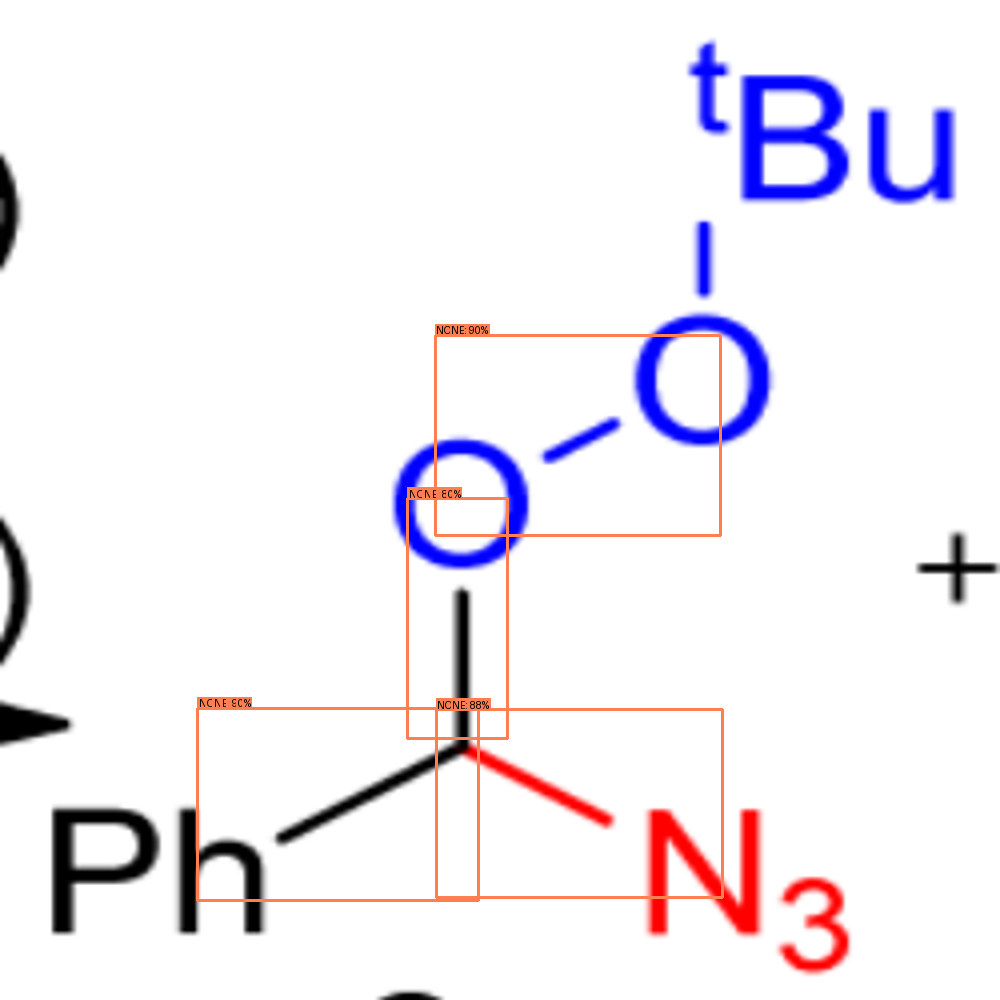

In [ ]:
bonbox_img=draw_objs(copy.deepcopy(img),
                bond_bbox* [scale_x, scale_y, scale_x, scale_y],
                bond_classes, bond_scores ,
                category_index=idx_to_labels,
                box_thresh=0.01,
                line_thickness=3,
                font='arial.ttf',
                font_size=10)
bonbox_img

In [ ]:
# for i in range(len(atom_classes)):
#     print(f"{i} atom box",atom_bbox[i],idx_to_labels[atom_classes[i]],atom_scores[i])
# for i in range(len(bond_classes)):
#     print(f" {i} bond box",bond_bbox[i],idx_to_labels[bond_classes[i]],bond_scores[i])

In [ ]:
BONDDIRECT=['ENDUPRIGHT', 'BEGINWEDGE', 'BEGINDASH', 'ENDDOWNRIGHT']


In [ ]:
boxi2ai,len(heavy_centers)

({0: 0, 1: 1, 2: 2, 3: 3, 4: 4}, 5)

In [ ]:
#重原子 skeleton mol
bonds=dict()
existing_bonds = set()
b2aa=dict()
singleAtomBond=[]
bondWithdirct=[]

# tree_heavy = KDTree(heavy_centers)#TODO before add bond consdiering reodering bond ??
tree_atom = KDTree(atom_centers)#TODO as atom bond are all reodered to kee H last
if len(idx_to_labels)==30:
    _margin=0#ad this version bond dynamicaly changed
for bi, (bbox, idx_) in enumerate(zip(bond_bbox, bond_classes)):#not work for cross-bond, longer bond, as the center of bond may be close to as atoms not it two atoms
    bond_type = idx_to_labels[idx_]
    if len(idx_to_labels)==23:
        if idx_to_labels[bond_type] in ['-','SINGLE', 'NONE', 'ENDUPRIGHT', 'BEGINWEDGE', 'BEGINDASH', 'ENDDOWNRIGHT']:
            _margin = 5
        else:
            _margin = 8
    anchor_positions = (bbox + [_margin, _margin, -_margin, -_margin]).reshape([2, -1])
    oposite_anchor_positions = anchor_positions.copy()
    oposite_anchor_positions[:, 1] = oposite_anchor_positions[:, 1][::-1]
    # Upper left, lower right, lower left, upper right
    # x1y1, x2y2, x1y2, x2y1 : dinuogl lines
    anchor_positions = np.concatenate([anchor_positions, oposite_anchor_positions])
    # print(f"anchor_positions {anchor_positions.shape}\n{anchor_positions}")
    dists, neighbours = tree_atom.query(anchor_positions, k=1)
    if np.argmin((dists[0] + dists[1], dists[2] + dists[3])) == 0:
        # visualize setup
        begin_idx, end_idx = neighbours[:2]
    else:
        # visualize setup
        begin_idx, end_idx = neighbours[2:]
    atom1_idx = boxi2ai[begin_idx]
    atom2_idx = boxi2ai[end_idx]
    if atom1_idx == atom2_idx:#NOTE when bond with only one terminal atom, other side H not used
        print(f"attempt to add self-bond:{bi}  atomIdx1 == atomIdx2 ::{[atom1_idx, atom2_idx]}")
        print(f"for bond bi {bi} H atom may involbed   dists:",dists)
        print(neighbours)
        print("anchor_positions",anchor_positions)
    else:
        if bond_type in  ['-', 'NONE', 'ENDUPRIGHT', 'BEGINWEDGE', 'BEGINDASH', 'ENDDOWNRIGHT']:
            if bond_type in BONDDIRECT:
                bonds[bi] = (atom1_idx, atom2_idx, 'SINGLE', bond_type)
                bondWithdirct.append(bi)
            else:
                bonds[bi] = (atom1_idx, atom2_idx, 'SINGLE', None)
            bond_type=BONDTYPE['SINGLE']
        elif bond_type == '=':
            bonds[bi] = (atom1_idx, atom2_idx, 'DOUBLE', None)
            bond_type=BONDTYPE['DOUBLE']
        elif bond_type == '#':
            bonds[bi] = (atom1_idx, atom2_idx, 'TRIPLE', None)
            bond_type=BONDTYPE['TRIPLE']
        else:
            print(f'unkown bond type relaced with single@@ {bond_type}')
            bonds[bi] = (atom1_idx, atom2_idx, 'SINGLE', None)
            bond_type=BONDTYPE['SINGLE']
        # 检查价态
        atom1 = rwmol_.GetAtomWithIdx(atom1_idx)
        atom2 = rwmol_.GetAtomWithIdx(atom2_idx)
        val1 = sum(b.GetBondTypeAsDouble() for b in atom1.GetBonds())
        val2 = sum(b.GetBondTypeAsDouble() for b in atom2.GetBonds())
        max_val1 = max(VALENCES[atom1.GetSymbol()])
        max_val2 = max(VALENCES[atom2.GetSymbol()])
        # bond_order = bond_type.AsDouble()
        bond_order=BONDTYPE2ORD[bond_type]
        if val1 + bond_order <= max_val1 and val2 + bond_order <= max_val2:
            bond1 = rwmol_.GetBondBetweenAtoms(atom1_idx, atom2_idx)
            bond2 = rwmol_.GetBondBetweenAtoms(atom2_idx, atom1_idx)
            if bond1 or bond2:
                # print(f'bond exists for {[atom1_idx, atom2_idx]}')
                pass
            # if (atom1_idx, atom2_idx) not in existing_bonds and (atom2_idx, atom1_idx) not in existing_bonds:
            else:    
                # print(atom1_idx, atom2_idx, bond_type,[ bi, idx_to_labels[idx_] ])
                rwmol_.AddBond(atom1_idx, atom2_idx, bond_type)
        else:
            print(f"Skipping bond {bi}: Exceeds valence.")
    existing_bonds.add((atom1_idx, atom2_idx))
    b2aa[bi]=sorted([atom1_idx, atom2_idx])


In [ ]:
if len(bond_bbox)==1 and len(atom_bbox)==2:
    ca1='[*:0][C:2]#[C:3][*:1]'#acs phC#CpH
    rwmol_ = Chem.RWMol()
    ats= ['*','*','C','C']
    for ia in ats:
        a=Chem.Atom(ia)
        id_=rwmol_.AddAtom(a)
        # print(ia,id_)
    rwmol_.AddBond(2, 3, Chem.BondType.TRIPLE)
    rwmol_.AddBond(0, 2, Chem.BondType.SINGLE)
    rwmol_.AddBond(1, 3, Chem.BondType.SINGLE)
    
    # Chem.MolFromSmiles(ca1)
    for i in range(len(atom_classes)):
        atom_classes[i]=lab2idx['*']
    AllChem.Compute2DCoords(rwmol_)
else:
    rwmol_=copy.deepcopy(rwmol_)

In [ ]:
print(ai2relplace,ai2rdkitlab)

{4: 'Ph'} {}


this mol from first build directly from box after OCR helped


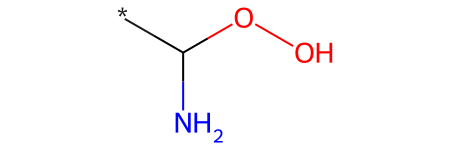

In [ ]:
print(f'this mol from first build directly from box after OCR helped')
rwmol_

4


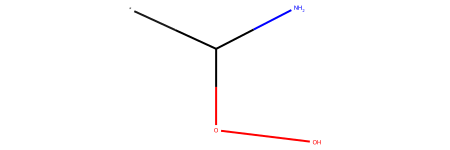

In [ ]:
#TODO assign 2D coords
mol = rwmol_.GetMol()
mol.RemoveAllConformers()
conf = Chem.Conformer(mol.GetNumAtoms())
# conf.Set3D(True)
# for i, (x, y) in enumerate(heavy_centers):
for i, (x, y) in enumerate(atom_centers):
    x, y=float(x),float(y)
    conf.SetAtomPosition(i, (x, y, 0))#TODO why some time need -y, just display same as ori?
mol.AddConformer(conf)
# Chem.SanitizeMol(mol)
Chem.AssignStereochemistryFrom3D(mol)
rwmol_=Chem.RWMol(mol) 
#as afte H a\lso didthis
skeleton_mol=copy.deepcopy(rwmol_)
print(skeleton_mol.GetNumBonds())
chiral_centers_aids = Chem.FindMolChiralCenters(mol, includeUnassigned=True)
skeleton_mol

In [ ]:
# H realted post-process
# heavyNumber=rwmol_.GetNumAtoms()#Chem.Atom('H') count also
heavyNumber=len(heavy_centers)
print(f'mol with heavy number atoms {heavyNumber}, max id {heavyNumber-1}')    
onlyHeayMol=copy.deepcopy(rwmol_)
chiral_centers = Chem.FindMolChiralCenters(
                rwmol_, includeUnassigned=True, includeCIP=False, useLegacyImplementation=False)
chiral_center_ids = [idx for idx, _ in chiral_centers] 

Hais=[]
Hais_bt=[]
Hbd=[]
# H_existing_bonds = set()
for bi, ais in b2a.items():#from box overlap
    bt=bond_classes[bi]# in [14,15]#directon bond
    for ai in ais:
        if ai>heavyNumber-1:
            if bt in  [14,15]:#directon bond
                Hais.append(ais)#NOTE ais ai increasing order as two for loop increasing
                print(f"within H  bond box id {bi} bond direction {idx_to_labels[bt]} atoms box id {ais} ")
                Hais_bt.append(idx_to_labels[bt])
                Hbd.append(bi)
                # print(bonds[bi] )


# add Hbonds with direction
H_existing_bonds = set()
ha2boxa=dict()
for ais, bt in zip(Hais,Hais_bt):
    idx_2=ais[-1]
    idx_1=ais[0]
    hbond=rwmol_.GetBondBetweenAtoms(idx_1,idx_2)
    if hbond is not None:
        if idx_1 in chiral_center_ids:#if not in the chiral atom, will not set bond directions
            hbond.SetBondDir(BOND_DIRS[bt])
    else:
        had = Chem.Atom("H")
        addHatom_idx = rwmol_.AddAtom(had)
        ha2boxa[addHatom_idx]=idx_2
        # print(idx_2,addHatom_idx)#Note if detected H box will lead idx_2 != addHatom_idx
        atom= rwmol_.GetAtomWithIdx(idx_1)
        max_val=max(VALENCES[atom.GetSymbol()])
        val = sum(b.GetBondTypeAsDouble() for b in atom.GetBonds())
        if (idx_1, addHatom_idx) not in H_existing_bonds and (addHatom_idx, idx_1) not in H_existing_bonds:
            if val<=max_val-1:
                # print(f"atom id {idx_1} val {val} max_val {max_val}")
                print(idx_1, addHatom_idx)#let check bond exist or not!!
                rwmol_.AddBond(idx_1,addHatom_idx, Chem.BondType.SINGLE)#BOND_DIRS[bt]
                b=rwmol_.GetBondBetweenAtoms(idx_1,addHatom_idx)
                if idx_1 in chiral_center_ids:#if not in the chiral atom, will not set bond directions
                    b.SetBondDir(BOND_DIRS[bt])#############Note can be done in the following tree
        H_existing_bonds.add((idx_1,addHatom_idx))


mol with heavy number atoms 5, max id 4


In [ ]:
if len(ha2boxa)>0:#consider Hnow
    #use box coords assign 2D, remove extra Hs also update box
    rwmol_.RemoveAllConformers()#
    conf = Chem.Conformer(rwmol_.GetNumAtoms())
    conf.Set3D(True)
    coords2d=[]
    for i, (x, y) in enumerate(heavy_centers):
        conf.SetAtomPosition(i, (x, y, 0))
        coords2d.append([x,y])
    for k,v in ha2boxa.items():
        x,y=atom_centers[v]
        conf.SetAtomPosition(k, (x, y, 0))
        coords2d.append([x,y])
    rwmol_.AddConformer(conf)
    rwmol_


In [ ]:
additonalH=detect_unconnected_hydrogens(rwmol_)
if len(additonalH)>0:
    rwmol_,rmovedAtomcoords=remove_unconnected_hydrogens2(rwmol_) #NOTE 留给将来WEB开发用will dercease h atom,but the box have not updated TODO fix me this in feature activate learning
    #update atom box infors
    if len(rmovedAtomcoords)>0:#update box infors
        delbb=[]
        kdt = cKDTree(atom_centers)
        for i, (x,y,z) in enumerate(rmovedAtomcoords):#z=0
            dist, idx_=kdt.query([x,y], k=1)
            delbb.append(idx_)
        mask = np.ones(len(atom_classes), dtype=bool)  # 初始化为 True
        mask[delbb] = False 
        atom_bbox = atom_bbox[mask]
        atom_classes = atom_classes[mask]
        atom_centers = atom_centers[mask]
# mol# mol_rebuit=copy.deepcopy(mol)



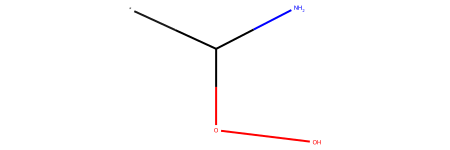

In [ ]:
mol=copy.deepcopy(rwmol_)
conf=mol.GetConformers()[0]
mola2xy=dict()
mola2d=[]
for i,a in enumerate(mol.GetAtoms()):
    x,y,z=conf.GetAtomPosition(i)
    mola2xy[i]=[x,y]
    mola2d.append([x,y])
    # print( x,y,z)
kdt = cKDTree(mola2d)
chiral_centers = Chem.FindMolChiralCenters(
                mol, includeUnassigned=True, includeCIP=False, useLegacyImplementation=False)
chiral_center_ids = [idx for idx, _ in chiral_centers] 

for bi,bcent in enumerate(bond_centers):
    if bi in bondWithdirct :#and bi not in Hbd:#Note as set Hbd previously
        dists, a1a2 = kdt.query(bcent, k=2)
        a1,a2=sorted(a1a2)
        a1,a2=int(a1),int(a2)
        bt= mol.GetBondBetweenAtoms(a1, a2)#RDKit 的键是无向的，返回的是同一个 Bond 对象
        if bt:
            # 获取键的当前起点和终点
            current_begin = bt.GetBeginAtomIdx()
            current_end = bt.GetEndAtomIdx()
            bond_dir=bond_dirs[idx_to_labels[bond_classes[bi]]]
            if bond_dir == rdchem.BondDir.BEGINWEDGE: 
                reverse_dir = rdchem.BondDir.BEGINDASH 
            elif bond_dir == rdchem.BondDir.BEGINDASH: 
                reverse_dir = rdchem.BondDir.BEGINWEDGE
            # else:
            #      reverse_dir= rdchem.BondDir.BEGINWEDGE
            if a1 in chiral_center_ids:
                if current_begin == a1:
                    bt.SetBondDir(bond_dir)
                    print(f'a1 dir')
                else:
                    # 如果手性原子是终点，反转方向（例如用相反的楔形键）
                    bt.SetBondDir(reverse_dir)
                    print(f'a1 reverse_dir')
                # print(f'set bond direction a1a2 {[bi, a1,a2]}')
                # bt.SetBondDir(bond_dirs[idx_to_labels[bond_classes[bi]]])
            elif a2 in chiral_center_ids:
                if current_begin == a2:
                    bt.SetBondDir(bond_dir)
                    print(f'a2 dir {bond_dir} {reverse_dir}')
                else:
                    # 如果手性原子是终点，反转方向（例如用相反的楔形键）,but not work, just remove and add
                    mol.RemoveBond(current_begin, current_end)
                    mol.AddBond(current_end, current_begin, bt.GetBondType())
                    bond = mol.GetBondBetweenAtoms(current_end, current_begin)
                    bond.SetBondDir(bond_dir)
                    print(f'a2 reverse_dir {bond_dir} {reverse_dir}')
                # bt= mol.GetBondBetweenAtoms(a2, a1)
                # print(f'set bond direction a2a1  {[bi, a2,a1]}')            
                # bt.SetBondDir(bond_dirs[idx_to_labels[bond_classes[bi]]])
            else:
                print('bond stro not with chiral atom???, will ignore this stero bond infors')
                print(f"{[bi, bond_dir, current_begin,current_end]}")
                # beginatom=mol.GetAtomWithIdx(current_begin)
                # Endatom=mol.GetAtomWithIdx(current_end)
                # beginatom_neis=len(beginatom.GetBonds())
                # Endatom_neis=len(Endatom.GetBonds())
                # if beginatom_neis>=Endatom_neis:
                #     bt.SetBondDir(bond_dir)
                # else:
                #     mol.RemoveBond(current_begin, current_end)
                #     mol.AddBond(current_end, current_begin, bt.GetBondType())
                #     bond = mol.GetBondBetweenAtoms(current_end, current_begin)
                #     bond.SetBondDir(bond_dir)
                    # bt.SetBondDir(reverse_dir)
mol


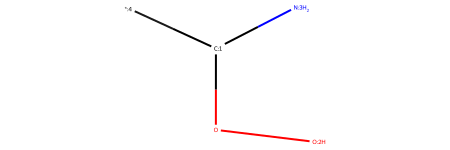

In [ ]:
molIDX(mol)

0
1
2
3
4


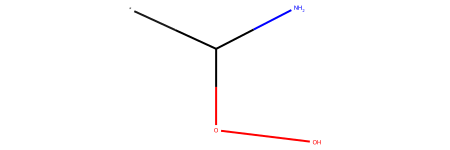

In [ ]:
molIDX_del(mol)

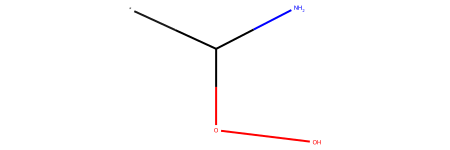

In [ ]:
mol_rebuild=mol.GetMol()
conf = mol_rebuild.GetConformer()
Chem.WedgeMolBonds(mol_rebuild,conf)#
Chem.DetectBondStereochemistry(mol_rebuild)
Chem.AssignChiralTypesFromBondDirs(mol_rebuild)
Chem.AssignStereochemistry(mol_rebuild)
mol_rebuild

In [ ]:
smiH=Chem.MolToSmiles(mol_rebuild)
print(F"smiH\n",smiH)
canon_smilesH = Chem.CanonSmiles(smiH)
print(F"canon_smilesH\n",canon_smilesH)
rdkit_coni_smiH=Chem.MolToSmiles(Chem.MolFromSmiles(smiH))
print(f"Chem.MolToSmiles(Chem.MolFromSmiles(smiH))\n {rdkit_coni_smiH}")

smiH
 *C(N)OO
canon_smilesH
 *C(N)OO
Chem.MolToSmiles(Chem.MolFromSmiles(smiH))
 *C(N)OO


In [ ]:
mol = rdkit.Chem.RWMol(mol_rebuild)
other2ppsocr=True
if other2ppsocr:
    print()
    need_cut=[]
    ppstr=[]
    ppstr_score=[]
    crops=[]
    index_token=dict()
    expan=-2#NOTE this control how much the part of bond in crop_Img
    for i_,(heav_c,heav_box) in enumerate(zip(atom_classes,atom_bbox)):
        if lab2idx['*']==heav_c or lab2idx['other']==heav_c or lab2idx['Cl']==heav_c:
            need_cut.append(i_)
            a=heav_box+np.array([-expan,-expan,expan,expan])
            # print(heav_box.shape,a.shape)
            box=a * [scale_x, scale_y, scale_x, scale_y]#TODO need the fix as w h may not equal!!
            # print(a,box,[scale_x, scale_y, scale_x, scale_y])
            cropped_img = img_ori_1k.crop(box)
            crops.append(cropped_img)
            image_npocr = np.array(cropped_img)
            result_ocr= ocr2.ocr(image_npocr, det=False)
            s_, score_ =result_ocr[0][0]
            print(f'ocr::idx:{i_}',s_, score_ )
            if score_<=0.1:# process cropped_img and try again
                # print(s_, "xxx",score_)
                s_='*'
            if s_=='+' or s_=='-':
                s_="*"
            if len(s_)>1:
                s_=re.sub(r'[^a-zA-Z0-9\*\-\+]', '', s_)#remove special chars
                if re.match(r'^\d+$', s_):
                    s_=f'{s_}*'#number+ *
                    # print(f'why only numbers ?  {s_}')
            if s_=='L':s_='Li'
            elif s_=='0':s_='O'
            match = re.match(r'^(\d+)?(.*)', s_)
            # print(s_,'xxxx')
            if match:
                numeric_part, remaining_part = match.groups()
                fc_=mol.GetAtomWithIdx(i_).GetFormalCharge()
                if remaining_part in ELEMENTS:
                    new_atom = Chem.Atom(remaining_part)
                    mol.ReplaceAtom(i_, new_atom)
                    print(i_, remaining_part,"@@@")
                elif remaining_part in ABBREVIATIONS:# can be expanded with placeholder_atoms
                    placeholder_atoms[i_]=s_# such 2Na will be get for rdkit
                elif remaining_part=='OH':
                    new_atom = Chem.Atom("O")
                    mol.ReplaceAtom(i_, new_atom)
                elif remaining_part=='SH':
                    new_atom = Chem.Atom("S")
                    mol.ReplaceAtom(i_, new_atom)
                elif remaining_part=='NH':
                    new_atom = Chem.Atom("N")
                    mol.ReplaceAtom(i_, new_atom)
                mol.GetAtomWithIdx(i_).SetFormalCharge(fc_)
            index_token[i_]=f'{s_}:{i_}'
            print(f"idx:{i_}, atm: <{idx_to_labels[heav_c]}> --- [{s_}:{i_}] with score:{score_}")
            if s_ in ELEMENTS :
                new_atom = Chem.Atom(s_)
                mol.ReplaceAtom(i_, new_atom)
            mol.GetAtomWithIdx(i_).SetProp("atomLabel", f"{s_}")#mol set with label, mol_rebuild not
            ppstr.append(s_)
            ppstr_score.append(score_)
            if  s_ in ABBREVIATIONS.keys():
                placeholder_atoms[i_]=s_
        


ocr::idx:4 Ph 0.9997121095657349
idx:4, atm: <other> --- [Ph:4] with score:0.9997121095657349


after ocr label replaced or put on the atoms


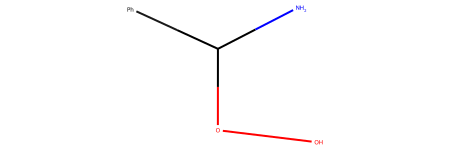

In [ ]:
print(f"after ocr label replaced or put on the atoms")
mol#after ocr label on the atoms   

In [ ]:
bond_dirs_rev={v:k for k,v in bond_dirs.items()}

In [ ]:
wdbs=[]
for b in mol.GetBonds():
    bd=b.GetBondDir()
    bt=b.GetBondType()
    # print(bd)
    if bd ==bond_dirs['BEGINDASH'] or  bd==bond_dirs['BEGINWEDGE']:
        a1,a2=b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        wdbs.append([a1,a2,bt,bond_dirs_rev[bd]])

In [ ]:
cm=copy.deepcopy(mol)
# print(placeholder_atoms)
expand_mol, expand_smiles= expandABB(cm,ABBREVIATIONS, placeholder_atoms)

In [ ]:
rdm=copy.deepcopy(expand_mol)
target_mol, ref_mol=rdm, cm
AllChem.Compute2DCoords(target_mol)
pair=[target_mol, ref_mol]
mcs=rdFMCS.FindMCS([target_mol, ref_mol], # larger,small order
                    # atomCompare=rdFMCS.AtomCompare.CompareAny,
                    bondCompare=rdFMCS.BondCompare.CompareAny,
                    ringCompare=rdFMCS.RingCompare.IgnoreRingFusion,
                    matchChiralTag=False,
    )
mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
AllChem.Compute2DCoords(mcs_mol)

matches0 = pair[0].GetSubstructMatches(mcs_mol, useQueryQueryMatches=True,uniquify=False, maxMatches=1000, useChirality=False)
matches1 = pair[1].GetSubstructMatches(mcs_mol, useQueryQueryMatches=True,uniquify=False, maxMatches=1000, useChirality=False)
if len(matches0) != len(matches1):
    matches0=list(matches0)
    matches1=list(matches1)
    # print( "noted: matcher not equal !!")
    if len(matches0)>len(matches1):
        for i in range(0,len(matches0)):
            if i < len(matches1):
                pass
            else:
                ii=i % len(matches1)
                matches1.append(matches1[ii])
    else:
        for i in range(0,len(matches1)):
            if i < len(matches0):
                pass
            else:
                ii=i % len(matches0)
                matches0.append(matches0[ii])
assert len(matches0) == len(matches1), "matcher not equal break!!"
atommaping_pairs=[list(zip(matches0[i],matches1[i])) for i in range(0,len(matches0))]

atomMap=atommaping_pairs[0]
rmsd2=rdkit.Chem.rdMolAlign.AlignMol(prbMol=target_mol, refMol=ref_mol, atomMap=atomMap,maxIters=2000000)
print(f"rmsd {rmsd2}")

rmsd 61.003474926335365


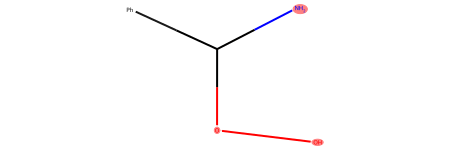

In [ ]:
ref_mol

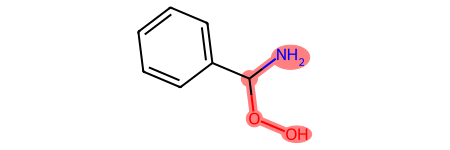

In [ ]:
target_mol

ocr_smi
NC(OO)c1ccccc1
canon_smiles_ocr
NC(OO)c1ccccc1


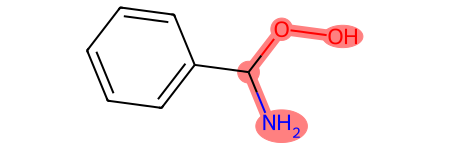

In [ ]:
ocr_mol = copy.deepcopy(target_mol)
AllChem.Compute2DCoords(ocr_mol)
ocr_smi = Chem.MolToSmiles(ocr_mol)
canon_smiles_ocr = Chem.CanonSmiles(ocr_smi)#, useChiral=(not ignore_chiral))
print(f'ocr_smi\n{ocr_smi}')
print(f'canon_smiles_ocr\n{canon_smiles_ocr}')
ocr_mol

In [ ]:
xxxxx

NameError: name 'xxxxx' is not defined

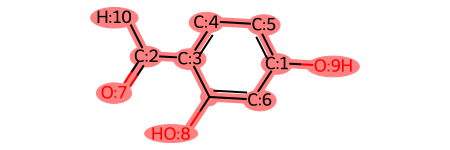

In [ ]:
remove_bond_directions_if_no_chiral(ocr_mol)

In [ ]:
def remove_bond_directions_if_no_chiral(mol):
    # 检查分子是否有效
    if mol is None:
        return None
    # 计算手性中心
    chiral_centers = Chem.FindMolChiralCenters(mol, includeUnassigned=True)
    # 如果没有手性中心，移除单键的立体化学标记
    if not chiral_centers:
        for bond in mol.GetBonds():
            # 只处理单键
            if bond.GetBondType() == Chem.BondType.SINGLE:
                # 移除楔形和虚线标记
                bond.SetBondDir(Chem.BondDir.NONE)
    return mol

In [ ]:
smi="CC(C1=CC=CC=C1)CC"
mol=Chem.MolFromSmiles(smi)

In [ ]:
chiral_centers = Chem.FindMolChiralCenters(mol, includeUnassigned=True)

In [ ]:
chiral_centers

[(1, '?')]

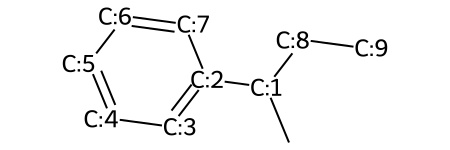

In [ ]:
molIDX(mol)

In [ ]:
#NOTE need a way to optimze the add grop from OCR or expanding
# from rdkit.Geometry import Point3D, Point2D
# atom_tracking=dict()
# conf = target_mol.GetConformer()
# for atom in target_mol.GetAtoms():
#     idx = atom.GetIdx()
#     pos = conf.GetAtomPosition(idx)
#     atom_tracking[idx] = Point2D(pos.x, pos.y)
# # target_mol.RemoveAllConformers()
# rdkit.Chem.rdDepictor.Compute2DCoords(target_mol,coordMap=atom_tracking,
#                                       clearConfs=False,canonOrient=False,
#                                       bondLength =1,forceRDKit=True,nSample=10)
# ocr_mol=copy.deepcopy(target_mol)
# ocr_smi=Chem.MolToSmiles(target_mol)
# Chem.MolFromSmiles(ocr_smi)

In [ ]:
if len(placeholder_atoms)>0:
    print(placeholder_atoms)
    expandStero_smi,molexp= molExpanding(mol,placeholder_atoms,wdbs,bond_dirs)#TODO fix me whe n multi strings on a atom will missing this ocr infors
    # molexp# = remove_unconnected_hydrogens(molexp)


In [ ]:
expandStero_smi

NameError: name 'expandStero_smi' is not defined

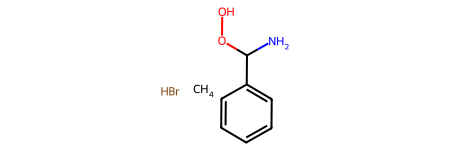

In [ ]:
molexp

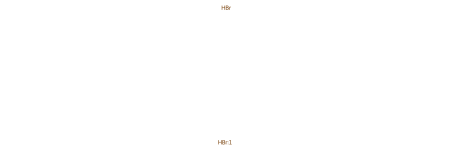

In [ ]:
molIDX(copy.deepcopy(rwmol_))

In [ ]:
# # 添加氢原子
# if h_centers.size > 0:
#     tree = KDTree(heavy_centers)
#     used_h = set()
#     for hi, h_center in enumerate(h_centers):
#         dists, idxs = tree.query(h_center,k=2)  # 找到最近的重原子
#         for dist, idx in zip(dists, idxs):
#             heavy_idx = heavy_idx_map[idx]
#             atom = rwmol_.GetAtomWithIdx(heavy_idx)
#             ats=atom.GetSymbol()
#             val = sum(b.GetBondTypeAsDouble() for b in atom.GetBonds())
#             max_val=max(VALENCES[ats])
#             # max_val = Chem.GetPeriodicTable().GetDefaultValence(atom.GetAtomicNum())
#             if val < max_val and hi not in used_h:
#                 h_atom = Chem.Atom('H')
#                 h_idx = rwmol_.AddAtom(h_atom)
#                 rwmol_.AddBond(heavy_idx, h_idx, Chem.BondType.SINGLE)
#                 used_h.add(hi)

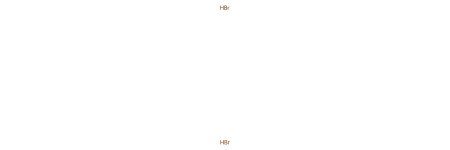

In [ ]:
rwmol_

In [ ]:
a2b

{0: [0], 1: [0], 2: [0], 3: [0]}

In [ ]:
b2a

{0: [0, 1, 2, 3]}

In [ ]:
# """
# try to use mine below ways to buld mol from box
# """
# bonds_mask = np.array([True if ins  in bond_labels else False for ins in output['pred_classes']])
# bond_bbox=output['bbox'][bonds_mask]
# atoms_mask = np.array([True if ins not in bond_labels and ins not in charge_labels else False for ins in output['pred_classes']])
# atom_bbox=output['bbox'][atoms_mask]

# predict_boxes = output['bbox']
# newbox = predict_boxes #* [scale_x, scale_y, scale_x, scale_y]
# predict_classes = output['pred_classes']
# predict_scores = output['scores']
# charge_labels = [18,19,20,21,22]
            
# b2a=dict()
# for bi,bb in enumerate(bond_bbox):
#     overlapped_atoms = []
#     overlapped_abox=[]
#     for ai,aa in enumerate(atom_bbox):
#         overlap_flag=boxes_overlap(bb, aa)#TODO use tghe atom bond box overlap get bond atom mapping,then built mol
#         if overlap_flag:
#             # print(bb, aa,overlap_flag)
#             overlapped_atoms.append(ai)
#             overlapped_abox.append(aa)
#             if bi not in b2a.keys():
#                 b2a[bi]=[ai]
#             else:
#                 # vais=b2a[bi]
#                 b2a[bi].append(ai)
#     if len(overlapped_atoms) == 1:
#         print(f"single bond -atom still exists")


# a2b=dict()
# for ai,aa in enumerate(atom_bbox):
#     b_nei=[]
#     for bi,bb in enumerate(bond_bbox):
#         overlap_flag=boxes_overlap(bb, aa)#TODO use tghe atom bond box overlap get bond atom mapping,then built mol
#         if overlap_flag:
#             b_nei.append(bi)
#     a2b[ai]=b_nei
# #TODO build RDKIT RWMol from the atom_bbox bond_bbox


# #TODO merge charge box to atom box


In [ ]:
atoms_df, bonds_list,charge_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                    bond_labels=bond_labels,  result=[])

print(f"atoms_df, bonds_list,charge_list::{[len(atoms_df), len(bonds_list),len(charge_list)]}")

SMILESpre,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list,charge_list )#NOTE, get SDF from mol_rebuit


atoms_df, bonds_list,charge_list::[8, 2, 0]


In [ ]:

#set bond direction again
wdbs=[b for b in bonds_list if b[3]=='BEGINDASH' or  b[3]=='BEGINWEDGE' ]
for b in wdbs:
    try:
        b_=mol_rebuit.GetBondBetweenAtoms(int(b[0]), int(b[1]))
        if b_:
            b_.SetBondDir(bond_dirs[b[3]])
    except Exception as e:
        print(e,"@@wdbs")
        print(b,f"\n{wdbs}")
        print(f"atoms_df@@{len(atoms_df)}")
        print(f"bonds_list@@{len(bonds_list)}")
        print(f"charge@@{len(charge_list)}")
        print(image_path)
        # print(SMILESori)
        # print(key,"@@key",[int(b[0]), int(b[1])])

aid_at={}
aid_at_star={}
for i_, row in atoms_df.iterrows():
    a_lab=row.atom[:-1]
    aid_at[i_]=a_lab
    #atom types not in defined vocable list
    if a_lab not in ['H', 'C', 'O', 'N', 'Cl', 'Br', 'S', 'F', 'B', 'I', 'P', 'Si']:#  '*', I2M's defined atom types
        aid_at_star[i_]="*"
            # aid_at[i_]=a_lab
    # print(aid_at,aid_at_star)
placeholder_atoms={k:aid_at[k] for k,v in aid_at_star.items() if aid_at[k] !='*' }

In [ ]:
debug=True
if debug:
    import importlib
    importlib.reload(draw_box_utils)
    importlib.reload(src.solver.utils)
    from src.solver.utils import bbox_to_graph_with_charge,mol_from_graph_with_chiral,assemble_atoms_with_charges
    from draw_box_utils import draw_objs,STANDARD_COLORS,draw_text


In [ ]:
other2ppsocr=True
#visual checking
predict_boxes = output['bbox']
predict_classes = output['pred_classes']
predict_scores = output['scores']
charge_labels = [18,19,20,21,22]#make influence
bonds_mask = np.array([True if ins  in bond_labels else False 
                                for ins in output['pred_classes']])
bond_bbox=output['bbox'][bonds_mask]
atoms_mask = np.array([True if ins not in bond_labels and ins not in charge_labels else
                                False for ins in output['pred_classes']])
atom_bbox=output['bbox'][atoms_mask]

img_ori = Image.open(image_path).convert('RGB')
w_ori, h_ori = img_ori.size  # 获取原始图像的尺寸
print(w_ori, h_ori, "orignianl vs 1000,1000")
# 计算缩放比例
scale_x = 1000 / w_ori
scale_y = 1000 / h_ori
img_ori_1k = img_ori.resize((1000,1000))
img = Image.open(image_path).convert('RGB')
img = img.resize((1000,1000))
img_ac = copy.deepcopy(img)
newbox = predict_boxes * [scale_x, scale_y, scale_x, scale_y]
bondbox_only=newbox[bonds_mask]
b_predict_classes=predict_classes[bonds_mask]
b_predict_scores=predict_scores[bonds_mask]
#non bonds
acbox_only=newbox[~bonds_mask]
ac_predict_classes=predict_classes[~bonds_mask]
ac_predict_scores=predict_scores[~bonds_mask]

mol_rebuit = remove_unconnected_hydrogens(mol_rebuit)#
mol = rdkit.Chem.RWMol(mol_rebuit)
if other2ppsocr:
    print()
    need_cut=[]
    ppstr=[]
    ppstr_score=[]
    crops=[]
    index_token=dict()
    expan=-2#NOTE this control how much the part of bond in crop_Img
    # mol=deep.copy(mol_rebuit)
    # for i_, v in aidstart_rest.items():
    for i_, row in atoms_df.iterrows():
        if "*" in row.atom or "other" in row.atom or "Cl" in row.atom:
            need_cut.append(i_)
            a=np.array(row.bbox )+np.array([-expan,-expan,expan,expan])#expand crop
            box=a * [scale_x, scale_y, scale_x, scale_y]#TODO need the fix as w h may not equal!!
            # print(a,box,[scale_x, scale_y, scale_x, scale_y])
            cropped_img = img_ori_1k.crop(box)
            crops.append(cropped_img)
            image_npocr = np.array(cropped_img)
            result_ocr= ocr.ocr(image_npocr, det=False)
            s_, score_ =result_ocr[0][0]
            print(f'ocr::idx:{i_}',s_, score_ )
            if score_<=0.1:# process cropped_img and try again
                # print(s_, "xxx",score_)
                s_='*'
            if s_=='+' or s_=='-':
                s_="*"
            if len(s_)>1:
                s_=re.sub(r'[^a-zA-Z0-9\*\-\+]', '', s_)#remove special chars
                if re.match(r'^\d+$', s_):
                    s_=f'{s_}*'#number+ *
                    # print(f'why only numbers ?  {s_}')
            if s_=='L':s_='Li'
            match = re.match(r'^(\d+)?(.*)', s_)
            # print(s_,'xxxx')
            if match:
                numeric_part, remaining_part = match.groups()
                fc_=mol.GetAtomWithIdx(i_).GetFormalCharge()
                if remaining_part in ELEMENTS:
                    new_atom = Chem.Atom(remaining_part)
                    mol.ReplaceAtom(i_, new_atom)
                    print(i_, remaining_part,"@@@")
                elif remaining_part in ABBREVIATIONS:# can be expanded with placeholder_atoms
                    placeholder_atoms[i_]=s_# such 2Na will be get for rdkit
                elif remaining_part=='OH':
                    new_atom = Chem.Atom("O")
                    mol.ReplaceAtom(i_, new_atom)
                elif remaining_part=='SH':
                    new_atom = Chem.Atom("S")
                    mol.ReplaceAtom(i_, new_atom)
                elif remaining_part=='NH':
                    new_atom = Chem.Atom("N")
                    mol.ReplaceAtom(i_, new_atom)
                mol.GetAtomWithIdx(i_).SetFormalCharge(fc_)
                # else:
                #     if numeric_part:
                #         s_=f'{numeric_part}*'
                #     else:
                #         s_='*'
            index_token[i_]=f'{s_}:{i_}'
            print(f"idx:{i_}, atm: <{row.atom}> --- [{s_}:{i_}] with score:{score_}")
            
            mol.GetAtomWithIdx(i_).SetProp("atomLabel", f"{s_}")#mol set with label, mol_rebuild not
            ppstr.append(s_)
            ppstr_score.append(score_)
            if s_ in ELEMENTS or s_ in ABBREVIATIONS.keys():
                placeholder_atoms[i_]=s_

if len(placeholder_atoms)>0:
    print(placeholder_atoms)
    expandStero_smi,molexp= molExpanding(mol,placeholder_atoms,wdbs,bond_dirs)#TODO fix me whe n multi strings on a atom will missing this ocr infors
    molexp = remove_unconnected_hydrogens(molexp)

else:
    molexp=mol
    expandStero_smi=SMILESpre

boxed_img = draw_objs(img_ac,
                        # newbox,
                        # predict_classes,
                        # predict_scores,
                        acbox_only,
                        ac_predict_classes,
                        ac_predict_scores,
                        category_index=idx_to_labels,
                        box_thresh=0.5,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)

boxed_img_b = draw_objs(img,
                        bondbox_only,
                        b_predict_classes,
                        b_predict_scores,
                        category_index=idx_to_labels,
                        box_thresh=0.5,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)


61 169 orignianl vs 1000,1000

ocr::idx:0 Ph 0.9815566539764404
idx:0, atm: <other0> --- [Ph:0] with score:0.9815566539764404
ocr::idx:1 Ph 0.890450119972229
idx:1, atm: <other0> --- [Ph:1] with score:0.890450119972229
{0: 'Ph', 1: 'Ph', 6: 'Ph', 7: 'Ph'}


RuntimeError: Range Error
	idx
	Violation occurred on line 209 in file Code/GraphMol/ROMol.cpp
	Failed Expression: 7 < 6
	RDKIT: 2024.03.5
	BOOST: 1_84


In [ ]:
print(len(atoms_df),len(bonds_list),len(charge_list)),index_token

7 4 0


(None, {})

In [ ]:
# # 方法 1: 清除芳香性标记并重新计算
# for bond in molexp.GetBonds():
#     bond.SetIsAromatic(False)
# for atom in molexp.GetAtoms():
#     atom.SetIsAromatic(False)

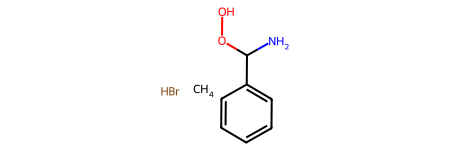

In [ ]:
molexp

In [ ]:
smi=Chem.MolToSmiles(molexp)
smi

'Br.C.NC(OO)c1ccccc1'

In [ ]:
s="[H][C@]12CCCC[C@]1([H])C(=O)OCC(NC(=O)C1=NC=CC(OC)=C1O)COC2=O"
m1=Chem.MolFromSmiles(s)
smi2=Chem.MolToSmiles(m1)
smi2

'COc1ccnc(C(=O)NC2COC(=O)[C@H]3CCCC[C@@H]3C(=O)OC2)c1O'

In [ ]:
original_smiles,test_smiles=s,smi
original_smiles = remove_backslash_and_slash(original_smiles)#c/s 
test_smiles = remove_backslash_and_slash(test_smiles)
original_smiles = re.sub(r'\[(\d+)\*', '[*',original_smiles)#[1*]-->[*]
test_smiles = re.sub(r'\[(\d+)\*', '[*',test_smiles)
original_smiles = remove_SP(original_smiles)#additional complex space stero from coordinates, most not used
test_smiles = remove_SP(test_smiles)
rd_smi_ori, success1=rdkit_canonicalize_smiles(original_smiles)
rd_smi, success2=rdkit_canonicalize_smiles(test_smiles)
original_smiles,test_smiles=rd_smi_ori,rd_smi

NameError: name 'remove_backslash_and_slash' is not defined

In [ ]:
success1,success2

NameError: name 'success1' is not defined

In [ ]:
#acc
from src.solver.det_engine import remove_backslash_and_slash, rdkit_canonicalize_smiles

In [ ]:
def comparing_smiles2(original_smiles,test_smiles):
    original_smiles = remove_backslash_and_slash(original_smiles)#c/s 
    test_smiles = remove_backslash_and_slash(test_smiles)
    original_smiles = re.sub(r'\[(\d+)\*', '[*',original_smiles)#[1*]-->[*]
    test_smiles = re.sub(r'\[(\d+)\*', '[*',test_smiles)
    original_smiles = remove_SP(original_smiles)#additional complex space stero from coordinates, most not used
    test_smiles = remove_SP(test_smiles)
    rd_smi_ori, success1=rdkit_canonicalize_smiles(original_smiles)
    rd_smi, success2=rdkit_canonicalize_smiles(test_smiles)
    original_smiles,test_smiles=rd_smi_ori,rd_smi
    try:
        original_mol = Chem.MolFromSmiles(original_smiles)#considering whe nmmet abbrev
        test_mol = Chem.MolFromSmiles(test_smiles,sanitize=False)#as build mol may not sanitized for rdkit
        if original_mol:
            Chem.SanitizeMol(original_mol)
            keku_smi_ori=Chem.MolToSmiles(original_mol,kekuleSmiles=True)
        else:
            keku_smi_ori=original_smiles
        
        if test_mol:
            Chem.SanitizeMol(test_mol)
            keku_smi=Chem.MolToSmiles(test_mol,kekuleSmiles=True)
        else:
            keku_smi=test_smiles
            
        if '*' not in keku_smi:
            keku_inch_ori=  Chem.MolToInchi(Chem.MolFromSmiles(keku_smi_ori))
            keku_inch_test=  Chem.MolToInchi(Chem.MolFromSmiles(keku_smi))
        else:
            keku_inch_ori=  1
            keku_inch_test=  2

        rd_smi=Chem.MolToSmiles(test_mol)#need improve the acc
        rd_smi_ori=Chem.MolToSmiles(original_mol)
    except Exception as e:#TODO fixme here
        print(f"comparing_smiles@@@ kekulize or SanitizeMol problems")# original_smiles,test_smiles\n{original_smiles}\n{test_smiles}")
        print(new_row)
        print(e,"!!!!!!!\n")
        keku_inch_ori=  1
        keku_inch_test=  2
        keku_smi=1
        keku_smi_ori=2
        #add molscribe rules here
        if not success1:#ori smiles still invaild even after * replaced
            rd_smi_ori = rd_smi
        # else:
        #     if canon_smiles1 == canon_smiles2:
        #         rd_smi_ori = rd_smi
            # else:
    if rd_smi_ori == rd_smi or keku_smi_ori == keku_smi or keku_inch_ori==keku_inch_test :#as orinial smiles may use kekuleSmiles style
        return True
    else:return False

In [ ]:
from datetime import datetime
# 获取当前日期和时间
current_datetime = datetime.now()
datetime_string = current_datetime.strftime("%Y_%m_%d_%H_%M_%S")
datetime_string

'2025_02_28_09_32_53'

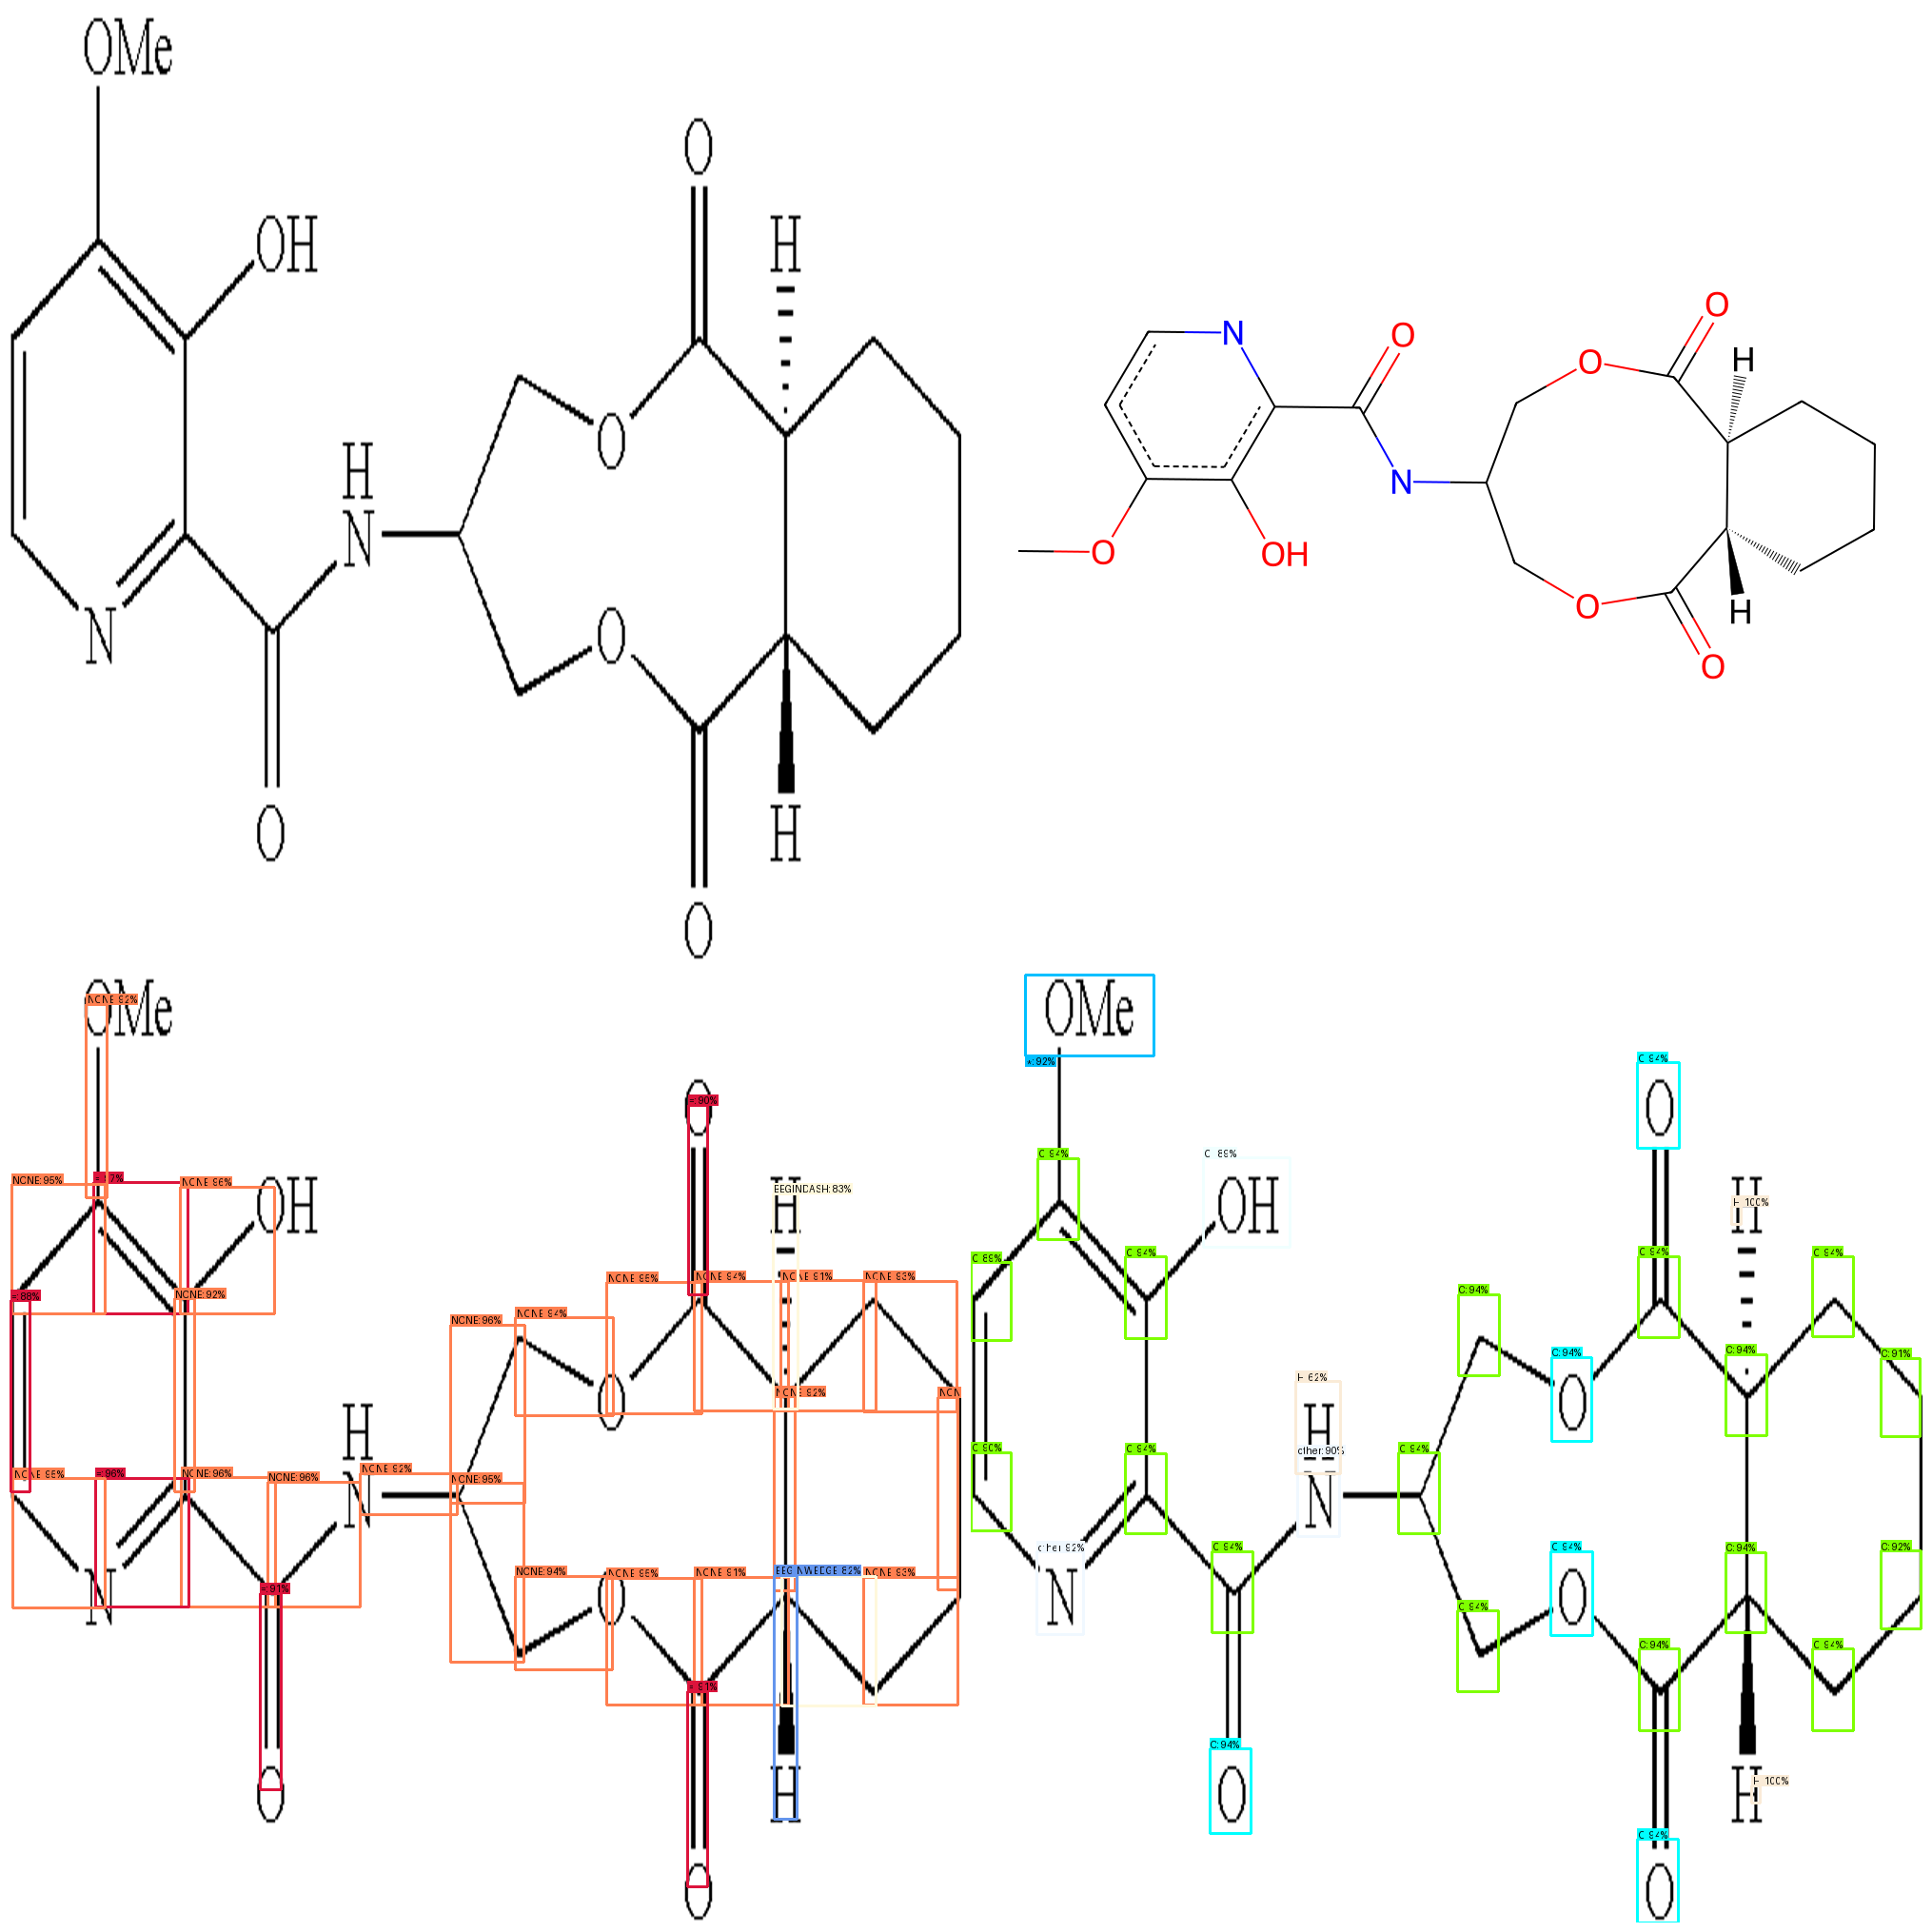

In [ ]:
visual_check=True
other2ppsocr=True
# TODO #[3H] 2H prpared box for training are too smalled, need adjust
if visual_check:
    padding = 10  # You can adjust this value for more or less space
    img_ori = Image.open(image_path).convert('RGB')
    img_ori_1k = img_ori.resize((1000,1000))
    if other2ppsocr:
        img_rebuit = Draw.MolToImage(molexp, options=opts,size=(1000, 1000))
    else:
        img_rebuit = Draw.MolToImage(mol_rebuit, options=opts,size=(1000, 1000))
    # Create the 2x2 grid: total width and height for the new image
    # combined_img = Image.new('RGB', (1000 * 2, 1000 * 2))
    # # Paste images in the corresponding positions:
    # combined_img.paste(img_ori_1k, (0, 0))  # Top-left
    # combined_img.paste(img_rebuit, (0, 1000))  # Bottom-left
    # combined_img.paste(boxed_img, (1000, 0))  # Top-right
    # combined_img.paste(boxed_img_b, (1000, 1000))  # Bottom-right        
    # Define padding size
    # Create the 2x2 grid with padding
    combined_img = Image.new('RGB', (1000 * 2 + padding * 3, 1000 * 2 + padding * 3), color=(255, 255, 255))  # White background
    combined_img.paste(img_ori_1k, (padding, padding))  # Top-left
    combined_img.paste(img_rebuit, (1000 + padding * 2, padding))  # Top-right
    combined_img.paste(boxed_img_b, (padding, 1000 + padding * 2))  # Bottom-left
    combined_img.paste(boxed_img, (1000 + padding * 2, 1000 + padding * 2))  # Bottom-right
combined_img

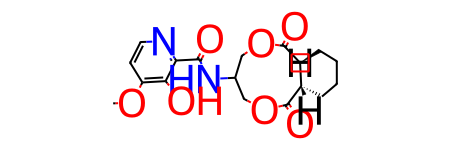

In [ ]:
mol_rebuit

In [ ]:
"""
image_path="/home/jovyan/rt-detr/data/real/USPTO/USRE039991-20080101-C00272.png"
real image: OH as  Cl  with 89% score

"""

'\nimage_path="/home/jovyan/rt-detr/data/real/USPTO/USRE039991-20080101-C00272.png"\nreal image: OH as  Cl  with 89% score\n\n'

In [ ]:
new_row = {'file_name':image_path, 
#  "SMILESori":SMILESori,
        'SMILESpre':SMILESpre,#with *  without expand
        'SMILESexp':expandStero_smi, 
        }
smiles_data = smiles_data._append(new_row, ignore_index=True)

In [ ]:
smiles_data

,file_name,SMILESori,SMILESpre,SMILESexp
0,/home/jovyan/volume/samba_share/from_docker/da...,NaN,***1=*(*)*(*(=*)**2***3=*[*@@]34****[*@@]43*=*...,***1=*(*)*(*(=*)**2***3=*[*@@]34****[*@@]43*=*...


In [ ]:
print("atomMap,rmsd2",atomMap,rmsd2)
print("now after AlignMol  target_mol 2d coords changed!!")
conformer = target_mol.GetConformer()
# 获取每个原子的坐标
atom_positions = {i: conformer.GetAtomPosition(i) for i in range(target_mol.GetNumAtoms())}
# 打印原子坐标
for idx, pos in atom_positions.items():
    a=target_mol.GetAtomWithIdx(idx)
    elem=a.GetSymbol()
    print(f"Atom {idx}   {elem}: (x={pos.x:.3f}, y={pos.y:.3f}, z={pos.z:.3f})")

NameError: name 'atomMap' is not defined

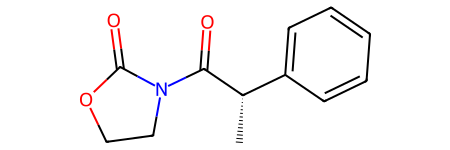

In [ ]:
# Chem.SanitizeMol(target_mol)
# Chem.DetectBondStereochemistry(target_mol)
# Chem.AssignChiralTypesFromBondDirs(target_mol)
# Chem.AssignStereochemistry(target_mol)
target_mol#with MCS highlight
expandStero_smi=Chem.MolToSmiles(target_mol)#directly will not add the stero info into smiles, must have the assing steps
m=target_mol.GetMol()
Chem.SanitizeMol(m)
Chem.DetectBondStereochemistry(m)
Chem.AssignChiralTypesFromBondDirs(m)
Chem.AssignStereochemistry(m)
m#without hihglight

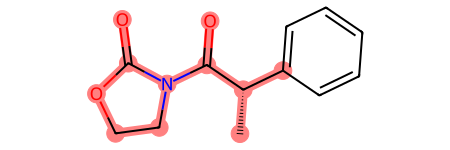

In [ ]:
target_mol#with MCS highlight

In [ ]:
Chem.MolToSmiles(m)

'C[C@H](C(=O)N1CCOC1=O)c1ccccc1'

0
1
2
3
4
5
6
7
8
9
10


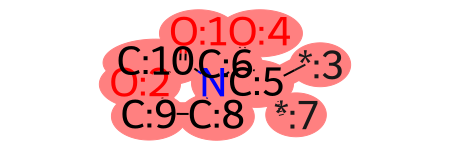

In [ ]:
molIDX(ref_mol)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15


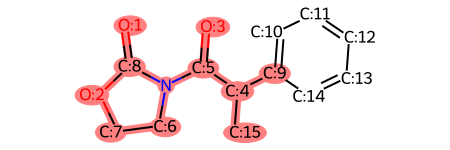

In [ ]:
molIDX(target_mol)

In [ ]:
conformer = ref_mol.GetConformer()
# 获取每个原子的坐标
atom_positions = {i: conformer.GetAtomPosition(i) for i in range(ref_mol.GetNumAtoms())}
# 打印原子坐标
for idx, pos in atom_positions.items():
    a=ref_mol.GetAtomWithIdx(idx)
    elem=a.GetSymbol()
    print(f"Atom {idx}   {elem}: (x={pos.x:.3f}, y={pos.y:.3f}, z={pos.z:.3f})")

Atom 0   N: (x=0.963, y=2.070, z=0.000)
Atom 1   O: (x=0.561, y=2.770, z=0.000)
Atom 2   O: (x=0.220, y=2.074, z=0.000)
Atom 3   *: (x=2.222, y=2.311, z=0.000)
Atom 4   O: (x=1.365, y=2.770, z=0.000)
Atom 5   C: (x=1.780, y=2.081, z=0.000)
Atom 6   C: (x=1.359, y=2.325, z=0.000)
Atom 7   *: (x=1.894, y=1.623, z=0.000)
Atom 8   C: (x=0.789, y=1.634, z=0.000)
Atom 9   C: (x=0.312, y=1.637, z=0.000)
Atom 10   C: (x=0.546, y=2.368, z=0.000)


In [ ]:
atoms_df# x/100 ,y/100 scaled

,atom,x,y,bbox,scores
0,N0,96.336494,93.049988,"[78.72564697265625, 75.7518081665039, 113.9473...",0.940527
1,O0,56.051975,23.014444,"[38.385009765625, 4.699044704437256, 73.718940...",0.911322
2,O0,22.033363,92.618912,"[4.997264862060547, 74.24376678466797, 39.0694...",0.910625
3,Me0,222.230621,68.941017,"[190.7293243408203, 51.65073013305664, 253.731...",0.910046
4,O0,136.467926,22.984482,"[118.59431457519531, 4.907514572143555, 154.34...",0.896478
5,C0,177.972717,91.940117,"[161.32281494140625, 74.89513397216797, 194.62...",0.890144
6,C0,135.924103,67.492584,"[119.90592956542969, 50.09312438964844, 151.94...",0.865667
7,Ph0,189.373474,137.706116,"[164.1694793701172, 119.6893539428711, 214.577...",0.851300
8,C0,78.940117,136.581589,"[62.81029510498047, 119.77143096923828, 95.069...",0.843375
9,C0,31.162994,136.343765,"[14.961268424987793, 119.18004608154297, 47.36...",0.837119


In [ ]:
bonds_list

[(6, 5, 'SINGLE', 'NONE', 0.9123611),
 (10, 0, 'SINGLE', 'NONE', 0.9023442),
 (2, 10, 'SINGLE', 'NONE', 0.8987796),
 (0, 6, 'SINGLE', 'NONE', 0.88877493),
 (5, 3, 'SINGLE', 'NONE', 0.8873214),
 (8, 0, 'SINGLE', 'NONE', 0.86127347),
 (2, 9, 'SINGLE', 'NONE', 0.84059596),
 (9, 8, 'SINGLE', 'NONE', 0.8339964),
 (1, 10, 'DOUBLE', '=', 0.814472),
 (4, 6, 'DOUBLE', '=', 0.81146896),
 (5, 7, 'SINGLE', 'BEGINDASH', 0.6908535)]

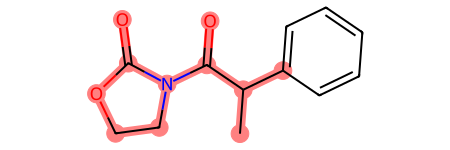

In [ ]:
target_mol

In [ ]:
#now after AlignMol  target_mol 2d coords changed
conformer = target_mol.GetConformer()
# 获取每个原子的坐标
atom_positions = {i: conformer.GetAtomPosition(i) for i in range(target_mol.GetNumAtoms())}
# 打印原子坐标
for idx, pos in atom_positions.items():
    a=target_mol.GetAtomWithIdx(idx)
    elem=a.GetSymbol()
    print(f"Atom {idx}   {elem}: (x={pos.x:.3f}, y={pos.y:.3f}, z={pos.z:.3f})")

Atom 0   N: (x=0.678, y=2.078, z=0.000)
Atom 1   O: (x=-0.845, y=4.275, z=0.000)
Atom 2   O: (x=-1.727, y=1.752, z=0.000)
Atom 3   O: (x=2.141, y=4.225, z=0.000)
Atom 4   C: (x=3.269, y=1.885, z=0.000)
Atom 5   C: (x=2.029, y=2.729, z=0.000)
Atom 6   C: (x=0.410, y=0.602, z=0.000)
Atom 7   C: (x=-1.076, y=0.401, z=0.000)
Atom 8   C: (x=-0.643, y=2.789, z=0.000)
Atom 9   C: (x=4.620, y=2.536, z=0.000)
Atom 10   C: (x=4.732, y=4.032, z=0.000)
Atom 11   C: (x=6.083, y=4.683, z=0.000)
Atom 12   C: (x=7.322, y=3.838, z=0.000)
Atom 13   C: (x=7.211, y=2.343, z=0.000)
Atom 14   C: (x=5.859, y=1.691, z=0.000)
Atom 15   C: (x=3.157, y=0.389, z=0.000)


In [ ]:
target_mol = Chem.MolFromSmiles("CCOc1ccc(CCNC(=O)C2CCCCC2)cc1")
# 生成目标分子的 2D 坐标
AllChem.Compute2DCoords(target_mol)
# 使用 SMARTS 定义模糊匹配结构（苯环+任意链式连接）
ref_mol = Chem.MolFromSmarts("c1ccc(*)cc1")  # * 代表任意连接点
# 计算 2D 坐标
Chem.rdDepictor.Compute2DCoords(ref_mol)

# 生成 2D 结构，匹配固定部分
AllChem.GenerateDepictionMatching2DStructure(target_mol, ref_mol)

((0, 3), (1, 4), (2, 5), (3, 6), (4, 7), (5, 18), (6, 19))

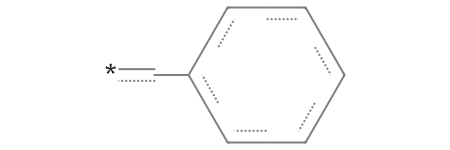

In [ ]:
ref_mol

In [ ]:
from rdkit.Chem import rdFMCS as _rdFMCS


Query *C(*)C(=O)N1CCOC1=O 11(6) atoms, 11(4) bonds
1 Seeds:5 MCS 5 atoms, 4 bonds for 0.0006 seconds. bond[0]=0
STATISTICS:
Total Growing Steps  = 1, MCS found on 1 step, for 0.0006 seconds
Initial   Seeds      = 11,  Mismatched 7
Inspected Seeds      = 12
Rejected by BestSize = 0
IndividualBondExcluded   = 0
MatchCheck Seeds     = 12
     MatchCalls = 9
     MatchFound = 2
 fastMatchCalls = 1
 fastMatchFound = 1
 slowMatchCalls = 8
 slowMatchFound = 1
  DupCacheFound = 0   0 matched, 0 mismatched
HashCache size  = 2 keys
HashCache size  = 2 entries
FindHashInCache = 12
HashFoundInCache= 10
ExactMatchCalls = 10
ExactMatchFound = 3


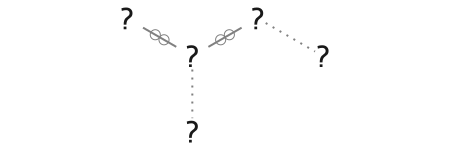

In [ ]:
mcs = _rdFMCS.FindMCS([cm,rdm],  # larger,small order
                atomCompare=rdkit.Chem.rdFMCS.AtomCompare.CompareAny,
                bondCompare=rdkit.Chem.rdFMCS.BondCompare.CompareAny,
                ringCompare=rdkit.Chem.rdFMCS.RingCompare.IgnoreRingFusion,
                completeRingsOnly=True,
                ringMatchesRingOnly=True,
                matchChiralTag=True,
                matchValences=True,
                maximizeBonds=False,
                threshold=1.0,verbose=True,timeout=120 )
# mcs.smartsString
mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
mcs_mol

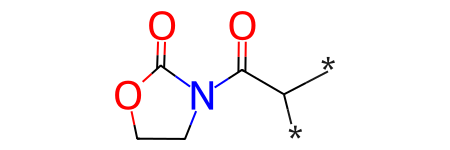

In [ ]:
cm

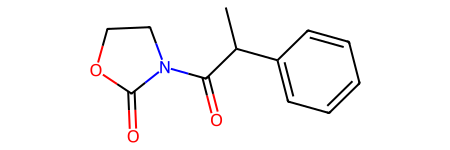

In [ ]:
rdm

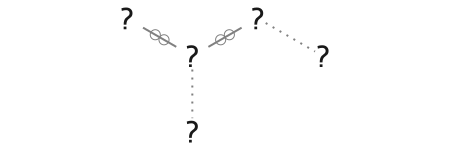

In [ ]:
# mcs.smartsString
mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
mcs_mol

In [ ]:
mcs.smartsString

'[#6&!R](-&!@[#6&!R])=&!@[#8&!R]'

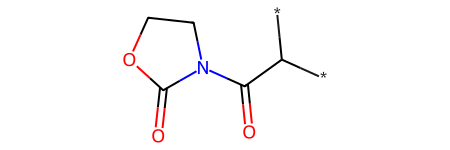

In [ ]:
sma_cm=Chem.MolToSmarts(cm)
Chem.MolFromSmarts(sma_cm)

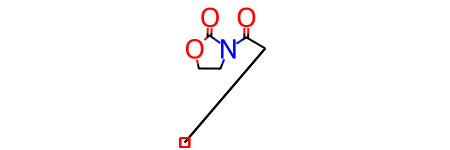

In [ ]:
modified_mol

In [ ]:
# 生成 2D 坐标
AllChem.Compute2DCoords(modified_mol)

0

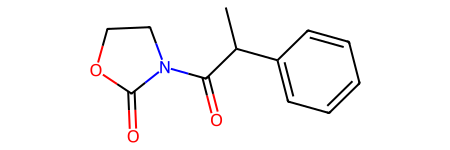

In [ ]:
modified_mol

In [ ]:
modified_smiles

'CC(C(=O)N1CCOC1=O)c1ccccc1'

In [ ]:
import io
from xml.dom import minidom


In [ ]:
def molIDX(mol):
    for i, atom in enumerate(mol.GetAtoms()):
        atom.SetAtomMapNum(i)  #映射
        print(i)
    return mol

def molIDX_del(mol):
    for i, atom in enumerate(mol.GetAtoms()):
        atom.SetAtomMapNum(0)  #映射
        print(i)
    return mol

In [ ]:
aid_at

{0: 'N',
 1: 'O',
 2: 'O',
 3: 'Me',
 4: 'O',
 5: 'C',
 6: 'C',
 7: 'Ph',
 8: 'C',
 9: 'C',
 10: 'C'}

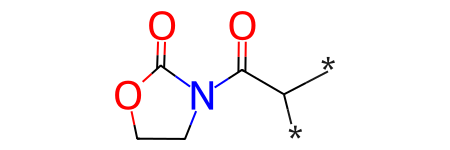

In [ ]:
cm=copy.deepcopy(mol_rebuit)
# molIDX(cm)
cm

In [ ]:
from SmilesPE.pretokenizer import atomwise_tokenizer
print(Chem.MolToSmiles(cm))
atomwise_tokenizer(Chem.MolToSmiles(cm))

*C(*)C(=O)N1CCOC1=O


['*',
 'C',
 '(',
 '*',
 ')',
 'C',
 '(',
 '=',
 'O',
 ')',
 'N',
 '1',
 'C',
 'C',
 'O',
 'C',
 '1',
 '=',
 'O']

In [ ]:
aa=Chem.MolFromSmiles("[N:0]1([C:6](=[O:4])[CH:5]([Me:3])[*:7])[CH2:8][CH2:9][O:2][C:10]1=[O:1]",sanitize=False)

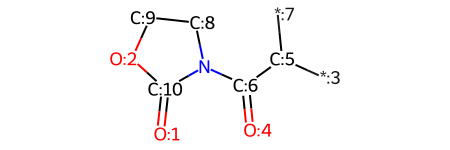

In [ ]:
Chem.MolFromSmiles("N1([C:6](=[O:4])[CH:5]([*:3])[*:7])[CH2:8][CH2:9][O:2][C:10]1=[O:1]")

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from xml.dom import minidom

def wh_get_svg_doc(mol, wh=[300, 300], writeSVG=False, fontSize=12):
    width, height = wh
    # 初始化绘图器
    d2d_svg = Chem.Draw.MolDraw2DSVG(width, height)
    options = d2d_svg.drawOptions()
    options.useBWAtomPalette()  # 使用黑白原子调色板
    dm = Draw.PrepareMolForDrawing(mol)
    d2d_svg.DrawMolecule(dm)
    d2d_svg.AddMoleculeMetadata(dm)
    d2d_svg.FinishDrawing()
    
    # 获取图像缓冲区
    base_svg = d2d_svg.GetDrawingText()
    
    # 手动修改 SVG 中的字体大小
    doc = minidom.parseString(base_svg)
    text_elements = doc.getElementsByTagName("text")
    for text in text_elements:
        text.setAttribute("font-size", str(fontSize))
    
    # 将修改后的 SVG 转换为字符串
    modified_svg = doc.toxml()
    
    if writeSVG:
        with open(f"{writeSVG}_view.svg", "w") as file:
            file.write(modified_svg)
    
    return modified_svg, doc, wh

In [ ]:
base_svg,doc,wh=wh_get_svg_doc(cm,wh=[300,300],writeSVG=True,fontSize=20)
rdkSVGatms=[path.getAttribute('atom-smiles') for path in doc.getElementsByTagName('rdkit:atom')]
rdkSVGatms

['[N]',
 '[O]',
 '[O]',
 '[*]',
 '[O]',
 '[CH]',
 '[C]',
 '[*]',
 '[CH2]',
 '[CH2]',
 '[C]']

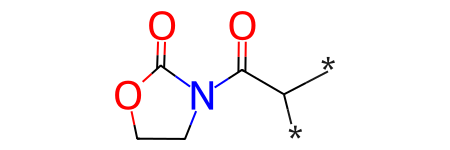

In [ ]:
cm

In [ ]:
t_scores=np.ones(10)
t_scores

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
print(img_ori.size)

(258, 159)


In [ ]:
atoms_df, bonds_list,charge_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                    bond_labels=bond_labels,  result=[])
smiles,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list,charge_list )#NOTE, get SDF from mol_rebuit


need_cut=[]
ppstr=[]
ppstr_score=[]
crops=[]
index_token=dict()
expan=8#NOTE this control how much the part of bond in crop_Img
mol = rdkit.Chem.RWMol(mol_rebuit)
other2pps=False

# for i_, atom_s in enumerate(atom_df['atom']):
for i_, row in atoms_df.iterrows():
    if "*" in row.atom or "other" in row.atom:
        need_cut.append(i_)
        a=np.array(row.bbox )+np.array([-expan,-expan,expan,expan])#expand crop
        box=a * 10/3
        cropped_img = img_ori_1k.crop(box)
        crops.append(cropped_img)
        # Show the cropped image
        # cropped_img.show()
        # cropped_img.save('box_crop01.jpg')
        # Convert PIL Image to a numpy array
        image_np = np.array(cropped_img)
        result = ocr.ocr(image_np, det=False)
        s_, score_ =result[0][0]
        if score_<=0.1:# process cropped_img and try again
            print(s_, "xxx",score_)
            s_='*'
        if s_=='+' or s_=='-':
            s_="*"
        if len(s_)>1:
            s_=re.sub(r'[^a-zA-Z0-9]', '', s_)#remove special chars
            if re.match(r'^\d+$', s_):print(f'why only numbers ?  {s_}')

        index_token[i_]=f'{s_}:{i_}'
        print(f"idx:{i_}, atm:{row.atom}-->[{s_}:{i_}] with score:{score_}")
        mol.GetAtomWithIdx(i_).SetProp("atomLabel", f"{s_}")

        ppstr.append(s_)
        ppstr_score.append(score_)

In [ ]:
from PIL import Image, ImageFilter,ImageEnhance


In [ ]:
pil_l=cropped_img.convert("L")
# binarized_img = pil_l.point(lambda x: 255 if x > 150 else 0, mode="1")
sharpen_kernel = [
    -1, -1, -1,
    -1,  9, -1,
    -1, -1, -1
]
sharpness_factor=2.0
# 应用锐化滤波器
sharpened_img = pil_l.filter(ImageFilter.Kernel((3, 3), sharpen_kernel, scale=1, offset=0))
# 增强锐度
enhancer = ImageEnhance.Sharpness(sharpened_img)
enhanced_img = enhancer.enhance(sharpness_factor)

NameError: name 'cropped_img' is not defined

In [ ]:
0.9909*4173

4135.0257

In [ ]:
44516/46285

0.9617802743869505

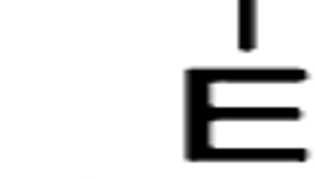

In [ ]:
cropped_img#TODO 对于* 未知box trained 太小

In [ ]:
a=Chem.MolFromSmiles('[2Na]')
type(a)

rdkit.Chem.rdchem.Mol

In [ ]:
atoms_df, bonds_list,charge_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                    bond_labels=bond_labels,  result=[])
smiles,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list,charge_list )#NOTE, get SDF from mol_rebuit
need_cut=[]
ppstr=[]
ppstr_score=[]
crops=[]
index_token=dict()
expan=8#NOTE this control how much the part of bond in crop_Img
mol = rdkit.Chem.RWMol(mol_rebuit)
other2pps=False

print(smiles)
# for i_, atom_s in enumerate(atom_df['atom']):
iiii=0
for i_, row in atoms_df.iterrows():
    iiii+=1
    if "*" in row.atom or "other" in row.atom:
        need_cut.append(i_)
        a=np.array(row.bbox )+np.array([-expan,-expan,expan,expan])#expand crop
        box=a * 10/3
        cropped_img = img_ori_1k.crop(box)
        crops.append(cropped_img)
        # Show the cropped image
        # cropped_img.show()
        # cropped_img.save('box_crop01.jpg')
        # Convert PIL Image to a numpy array
        image_np = np.array(cropped_img)
        result = ocr.ocr(image_np, det=False)
        s_, score_ =result[0][0]
        print(s_, score_,"xxxxxxxxxx")
        if score_<=0.1:# process cropped_img and try again
                print(s_, "xxx",score_)
                s_='*'
        if s_=='+' or s_=='-':
            s_="*"
        if len(s_)>1:
            s_=re.sub(r'[^a-zA-Z0-9]', '', s_)#remove special chars
            if re.match(r'^\d+$', s_):print(f'why only numbers ?  {s_}')
        if s_=='L':s_='Li'
        print(f"idx:{i_}, atm:{row.atom}-->[{s_}:{i_}] with score:{score_}")
        mol.GetAtomWithIdx(i_).SetProp("atomLabel", f"{s_}")

        ppstr.append(s_)
        ppstr_score.append(score_)
# print(f"nums: {len(index_token)} '*' need paddleOCR converting",index_token)
final_mol = mol.GetMol()
# except Exception as e:
#     print(f"idx:{i_}, atm:{row.atom}-->[{s_}:{i_}] with score:{score_}")
#     print(atoms_df)
#     print(image_path,"@@atoms_df for loop")
#     print(e)
#     uncorrects.append(image_path)
    # continue


rdkit_input_s=Chem.MolToSmiles(Chem.MolFromSmiles(input_s),kekuleSmiles=True)
if len(ppstr)==1:
    #just replace * with []
    cur_smi=Chem.MolToSmiles(final_mol,kekuleSmiles=True)#as csv use kekuleSmiles style
    match = re.match(r'^(\d+)?(.*)', s_)
    if match:
        numeric_part, remaining_part = match.groups()
        if remaining_part in chemical_elements:
            s_=s_
        else:
            s_='*'
    test_smiles=re.sub(r'\*', f'[{s_}]', cur_smi)
    print(cur_smi,test_smiles)
    # new_mol=Chem.MolFromSmiles(test_smiles)
    rdkit_test_smiles=Chem.MolToSmiles(Chem.MolFromSmiles(test_smiles),kekuleSmiles=True)
    if rdkit_test_smiles==rdkit_input_s: correcte.append([image_path])

    other2pps=True  
elif len(ppstr)>1:
    index_mol=copy.deepcopy(final_mol)
    show_atom_number(index_mol, 'molAtomMapNumber')
    index_smi=Chem.MolToSmiles(index_mol)
    ai_tokens=atomwise_tokenizer(index_smi)
    new_toks=[]
    for k,v in index_token.items():
        for i, atoken in enumerate(ai_tokens):
            if f':{k}' in atoken:
                # index_token[k]
                ai_tokens[i]=re.sub(r'\[.*?\]', f'[{index_token[k]}]', ai_tokens[i])
                print(f':{k},  {atoken} --> [{index_token[k]}] || {ai_tokens[i]}' )
            # new_toks.append(atoken)
    new_smi=''.join(ai_tokens)
    new_mol=Chem.MolFromSmiles(new_smi)#if str not belong chemical_elements will failed
    m_noid=remove_atom_number(new_mol)
    s_noid=Chem.MolToSmiles(m_noid)
    test_smiles = re.sub(r'\[(\d+)\*', '[*',s_noid)#remove_number_before_star
    test_smiles = remove_SP(test_smiles)
    # input_s='[*]C1([*])*[W]CN(S(=O)(=O)C2=CC=C(O[Ar])C=C2)C1C(=O)NO'
    other2pps=True
    rdkit_test_smiles=Chem.MolToSmiles(Chem.MolFromSmiles(test_smiles),kekuleSmiles=True)
    if rdkit_test_smiles==rdkit_input_s: correcte.append(image_path)
else:
    uncorrects.append(image_path)
    other2pps=False
# except Exception as e:
#     other2pps=False
#     uncorrects.append(image_path)
#     print(f"not recongnized::{image_path}\n")
#     print(e)

*CC1=CC(=O)CCC1
 0.0 xxxxxxxxxx
 xxx 0.0
idx:7, atm:*0-->[*:7] with score:0.0
*CC1=CC(=O)CCC1 [*]CC1=CC(=O)CCC1


In [ ]:
match = re.match(r'^(\d+)?(.*)', "Ar-")
numeric_part, remaining_part = match.groups()

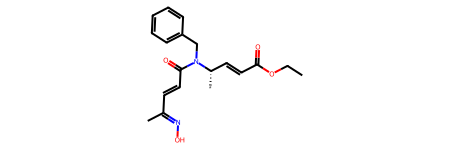

In [ ]:
Chem.MolFromSmiles('[*][C@@H](C=CC(=O)OCC)N(Cc1ccccc1)C(=O)C=CC(C)=NO')

In [ ]:
try:
    atoms_df, bonds_list,charge_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                        bond_labels=bond_labels,  result=[])
    smiles,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list,charge_list )#NOTE, get SDF from mol_rebuit


    need_cut=[]
    ppstr=[]
    ppstr_score=[]
    crops=[]
    index_token=dict()
    expan=8#NOTE this control how much the part of bond in crop_Img
    mol = rdkit.Chem.RWMol(mol_rebuit)
    other2pps=False

    # for i_, atom_s in enumerate(atom_df['atom']):
    for i_, row in atoms_df.iterrows():
        if "*" in row.atom or "other" in row.atom:
            need_cut.append(i_)
            a=np.array(row.bbox )+np.array([-expan,-expan,expan,expan])#expand crop
            box=a * 10/3
            cropped_img = img_ori_1k.crop(box)
            crops.append(cropped_img)
            image_np = np.array(cropped_img)
            result = ocr.ocr(image_np, det=False)
            s_, score_ =result[0][0]
            print(f'ocr::idx:{i_}',s_, score_ )
            if score_<=0.1:# process cropped_img and try again
                    print(s_, "xxx",score_)
                    s_='*'
            if s_=='+' or s_=='-':
                s_="*"
            if len(s_)>1:
                s_=re.sub(r'[^a-zA-Z0-9\*\-\+]', '', s_)#remove special chars
                if re.match(r'^\d+$', s_):
                    s_=f'{s_}*'#number+ *
                    print(f'why only numbers ?  {s_}')
            if s_=='L':s_='Li'
            match = re.match(r'^(\d+)?(.*)', s_)
            if match:
                numeric_part, remaining_part = match.groups()
                if remaining_part in chemical_elements:
                    s_=s_
                else:
                    if numeric_part:
                        s_=f'{numeric_part}*'
                    else:
                        s_='*'
            index_token[i_]=f'{s_}:{i_}'
            print(f"idx:{i_}, atm:{row.atom}-->[{s_}:{i_}] with score:{score_}")
            mol.GetAtomWithIdx(i_).SetProp("atomLabel", f"{s_}")

            ppstr.append(s_)
            ppstr_score.append(score_)
    # print(f"nums: {len(index_token)} '*' need paddleOCR converting",index_token)
    final_mol = mol.GetMol()
except Exception as e:
    print(f"idx:{i_}, atm:{row.atom}-->[{s_}:{i_}] with score:{score_}")
    print(atoms_df)
    print(image_path,"@@atoms_df for loop")
    print(e)
    uncorrects.append(image_path)
    # continue


rdkit_input_s=Chem.MolToSmiles(Chem.MolFromSmiles(input_s),kekuleSmiles=True)
if len(ppstr)==1:
    #just replace * with []
    cur_smi=Chem.MolToSmiles(final_mol,kekuleSmiles=True)#as csv use kekuleSmiles style
    test_smiles=re.sub(r'\*', f'[{s_}]', cur_smi)
    # new_mol=Chem.MolFromSmiles(test_smiles)
    rdkit_test_smiles=Chem.MolToSmiles(Chem.MolFromSmiles(test_smiles),kekuleSmiles=True)
    if rdkit_test_smiles==rdkit_input_s: correcte.append([image_path])

    other2pps=True  
elif len(ppstr)>1:
    index_mol=copy.deepcopy(final_mol)
    show_atom_number(index_mol, 'molAtomMapNumber')
    index_smi=Chem.MolToSmiles(index_mol,kekuleSmiles=True)
    ai_tokens=atomwise_tokenizer(index_smi)
    new_toks=[]
    for k,v in index_token.items():
        for i, atoken in enumerate(ai_tokens):
            if f':{k}' in atoken:
                # index_token[k]
                ai_tokens[i]=re.sub(r'\[.*?\]', f'[{index_token[k]}]', ai_tokens[i])
                print(f':{k},  {atoken} --> [{index_token[k]}] || {ai_tokens[i]}' )
            # new_toks.append(atoken)
    new_smi=''.join(ai_tokens)
    print(f"before replace-->{index_smi}")#TODO NOTE rdkit None* try re way
    print(f"after  replace-->{new_smi}")
    new_mol=Chem.MolFromSmiles(new_smi)
    m_noid=remove_atom_number(new_mol)#TODO this may lead problem
    s_noid=Chem.MolToSmiles(m_noid)
    test_smiles = re.sub(r'\[(\d+)\*', '[*',s_noid)#remove_number_before_star
    test_smiles = remove_SP(test_smiles)
    other2pps=True
    rdkit_test_smiles=Chem.MolToSmiles(Chem.MolFromSmiles(test_smiles),kekuleSmiles=True)
    print(f"final        -->{rdkit_test_smiles}")
    print(f"rdkit_input_s-->{rdkit_test_smiles}")

    if rdkit_test_smiles==rdkit_input_s: correcte.append(image_path)
else:
    uncorrects.append(image_path)
    other2pps=False
# except Exception as e:
#     other2pps=False
#     uncorrects.append(image_path)
#     print(f"not recongnized::{image_path}\n")
#     print(e)

ocr::idx:10 E 0.8405953645706177
idx:10, atm:other0-->[*:10] with score:0.8405953645706177


In [ ]:
#TODO get the * with coords, check String OCR, check rebuild process charge and bond missing!!

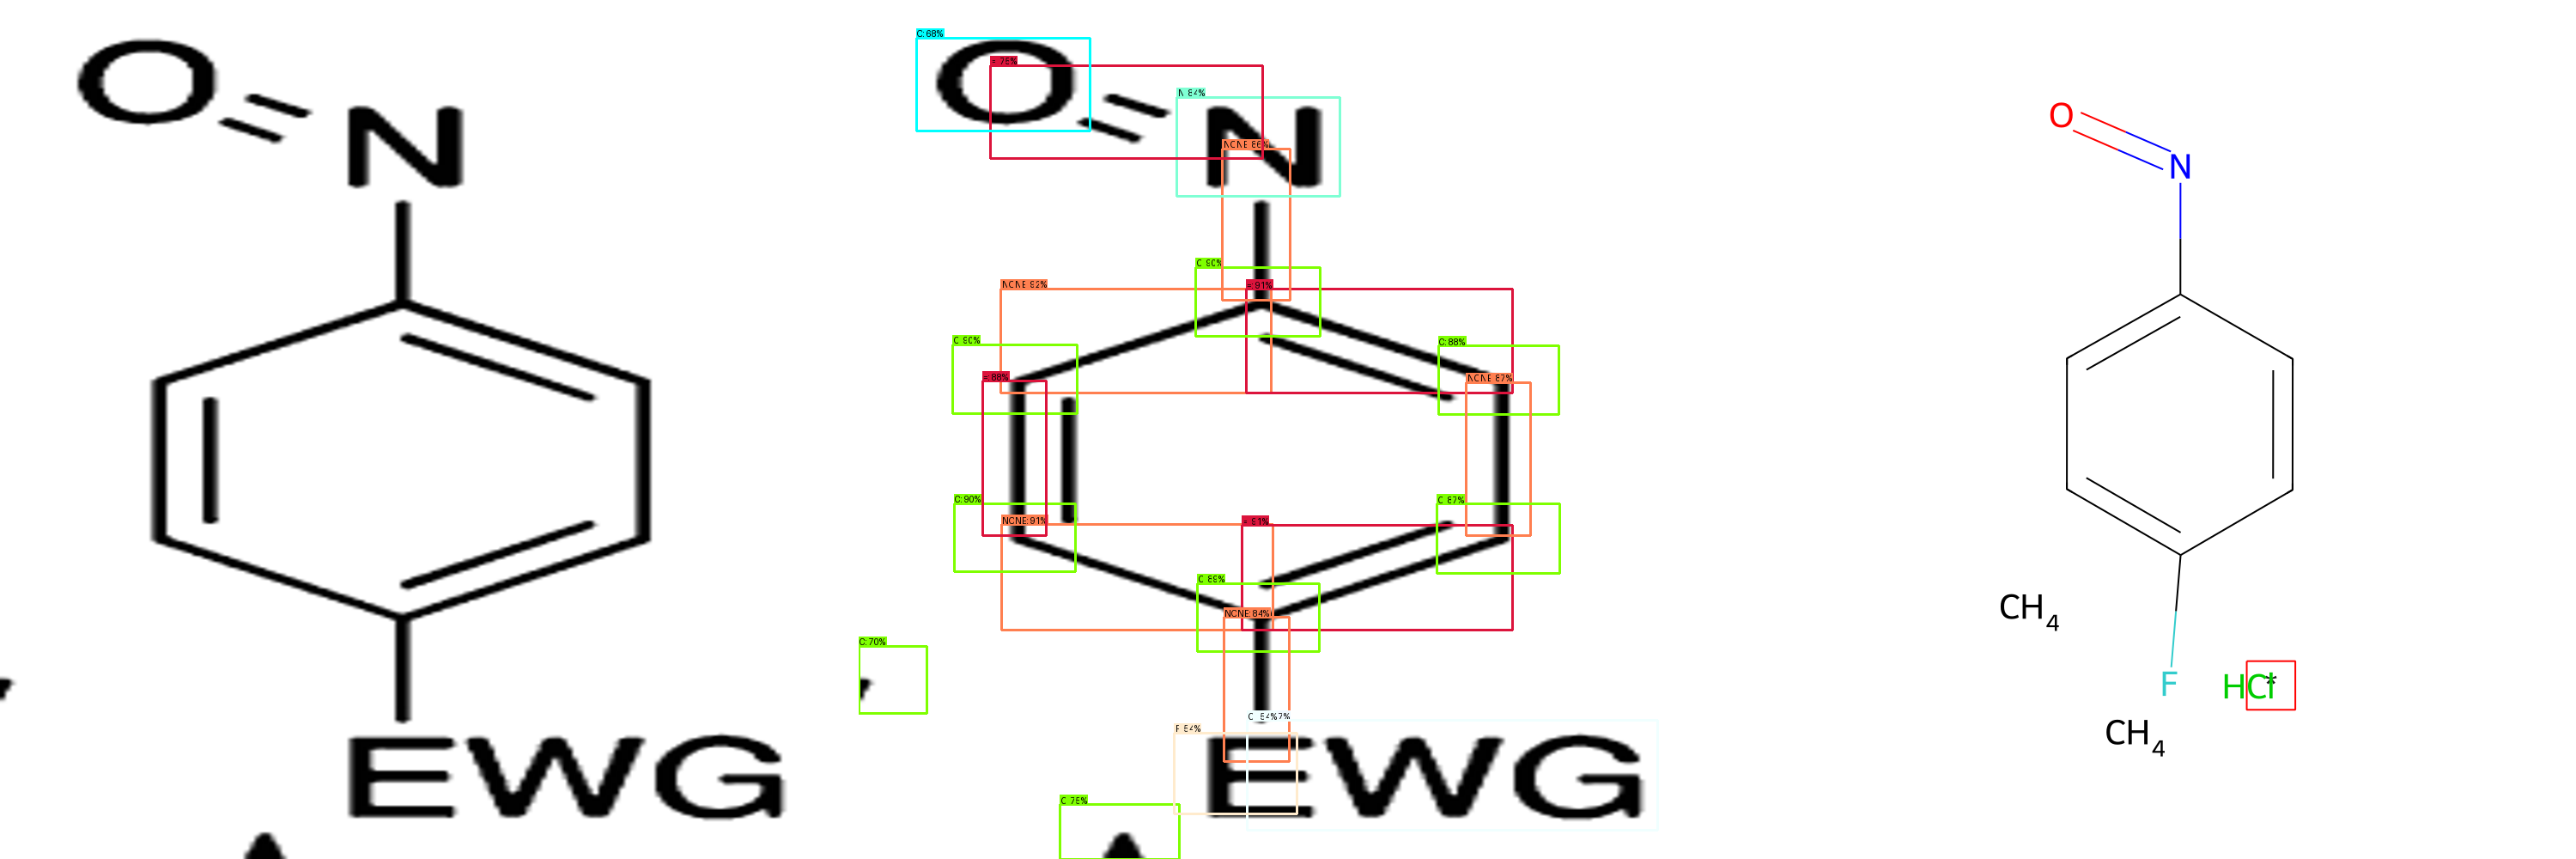

In [ ]:
visual_check=True
other2pps=True
# TODO #[3H] 2H prpared box for training are too smalled, need adjust
if visual_check:
    img_ori = Image.open(image_path).convert('RGB')
    img_ori_1k = img_ori.resize((1000,1000))
    if other2pps:
        img_rebuit = Draw.MolToImage(final_mol, options=opts,size=(1000, 1000))
    else:
        img_rebuit = Draw.MolToImage(mol_rebuit, options=opts,size=(1000, 1000))
    combined_img = Image.new('RGB', (img_ori_1k.width + boxed_img.width + img_rebuit.width, img_ori_1k.height))
    combined_img.paste(img_ori_1k, (0, 0))
    combined_img.paste(boxed_img, (img_ori_1k.width, 0))
    combined_img.paste(img_rebuit, (img_ori_1k.width + boxed_img.width, 0))
combined_img

In [ ]:
#save as onnx
import torch.onnx
import onnx
import onnxruntime as ort
# 设置为评估模式
_model.eval()
# 定义输出ONNX文件的路径
onnx_model_path = "i2mDETR_model_v2.onnx"
torch.onnx.export(
    model=_model,                     # 要转换的模型
    args=tensor,                 # 模型的输入（示例输入）
    f=onnx_model_path,                # 输出文件的路径
    export_params=True,               # 是否导出训练好的参数
    opset_version=16,                  # 使用更高的 opset 版本dummy_grid
    do_constant_folding=True,         # 是否执行常量折叠优化
    input_names=['input'],            # 输入名称（可选）
    output_names=['output'],          # 输出名称（可选）
    dynamic_axes={
        'input': {0: 'batch_size'},    # 支持动态批量大小
        'output': {0: 'batch_size'}
    }
)


# 加载并检查ONNX模型
onnx_model = onnx.load(onnx_model_path)
onnx.checker.check_model(onnx_model)
print("ONNX模型检查通过")

# 使用ONNX Runtime进行推理
ort_session = ort.InferenceSession(onnx_model_path)

# 准备输入数据
def to_numpy(tensor):
    return tensor.detach().cpu().numpy() if tensor.requires_grad else tensor.cpu().numpy()

ort_inputs = {
    ort_session.get_inputs()[0].name: to_numpy(tensor),
    # ort_session.get_inputs()[1].name: to_numpy(dummy_grid)
}
ort_outputs = ort_session.run(None, ort_inputs)

# 获取PyTorch输出
with torch.no_grad():
    torch_output = _model(tensor)

# 打印并比较结果
print("PyTorch输出:", torch_output)
print("ONNX Runtime输出:", ort_outputs[0])

# 计算两者的差异
# difference = np.abs(to_numpy(torch_output) - ort_outputs[0]).max()
# print(f"输出差异最大值: {difference}")


============= Diagnostic Run torch.onnx.export version 2.0.1+cu118 =============
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================

ONNX模型检查通过
PyTorch输出: {'pred_logits': tensor([[[-5.5288, -4.5578, -4.5115,  ..., -5.4560, -5.3202, -5.9717],
         [-5.5009, -4.6031, -4.4814,  ..., -4.8978, -5.1217, -5.7569],
         [-5.1530, -4.5877, -4.1356,  ..., -4.6417, -4.5300, -5.8577],
         ...,
         [-4.1337, -2.4281, -3.1227,  ..., -4.7081, -4.7062, -6.0905],
         [-4.9607, -3.2102, -3.7347,  ..., -5.0859, -5.0976, -6.7588],
         [-4.7754, -2.8874, -3.3816,  ..., -5.0368, -5.2054, -6.4089]]]), 'pred_boxes': tensor([[[0.3244, 0.6725, 0.3166, 0.1231],
         [0.3232, 0.3972, 0.3145, 0.1214],
         [0.6044, 0.6727, 0.3150, 0.1215],
         ...,
         [0.5011, 0.5403, 0.9924, 0.5989],
         [0.0257, 0.0648, 0.0673, 0.1169],
         [0.4885, 0.2459, 0.9775, 0.3859]]])}
ONNX Runtime输出: [[[-5.528808

In [ ]:
torch_output

{'pred_logits': tensor([[[-5.5288, -4.5578, -4.5115,  ..., -5.4560, -5.3202, -5.9717],
          [-5.5009, -4.6031, -4.4814,  ..., -4.8978, -5.1217, -5.7569],
          [-5.1530, -4.5877, -4.1356,  ..., -4.6417, -4.5300, -5.8577],
          ...,
          [-4.1337, -2.4281, -3.1227,  ..., -4.7081, -4.7062, -6.0905],
          [-4.9607, -3.2102, -3.7347,  ..., -5.0859, -5.0976, -6.7588],
          [-4.7754, -2.8874, -3.3816,  ..., -5.0368, -5.2054, -6.4089]]]),
 'pred_boxes': tensor([[[0.3244, 0.6725, 0.3166, 0.1231],
          [0.3232, 0.3972, 0.3145, 0.1214],
          [0.6044, 0.6727, 0.3150, 0.1215],
          ...,
          [0.5011, 0.5403, 0.9924, 0.5989],
          [0.0257, 0.0648, 0.0673, 0.1169],
          [0.4885, 0.2459, 0.9775, 0.3859]]])}

In [ ]:
outputs={'pred_logits':torch.from_numpy(ort_outputs[0]),
'pred_boxes':torch.from_numpy(ort_outputs[1])
}

In [ ]:
ori_size=torch.Tensor([w,h]).long().unsqueeze(0)
result_ = postprocessor(outputs, ori_size)
# result_ = postprocessor(out_, torch.Tensor([w,h]))
score_=result_[0]['scores']
boxe_=result_[0]['boxes']
label_=result_[0]['labels']
selected_indices =score_ > 0.5
output={
    'labels': label_[selected_indices],
    'boxes': boxe_[selected_indices],
    'scores': score_[selected_indices]
}

filtered_output_dict={image_path: output
}


x_center = (output["boxes"][:, 0] + output["boxes"][:, 2]) / 2
y_center = (output["boxes"][:, 1] + output["boxes"][:, 3]) / 2
center_coords = torch.stack((x_center, y_center), dim=1)
output = {'bbox':         output["boxes"].to("cpu").numpy(),
            'bbox_centers': center_coords.to("cpu").numpy(),
            'scores':       output["scores"].to("cpu").numpy(),
            'pred_classes': output["labels"].to("cpu").numpy()}

In [ ]:
#visual checking
predict_boxes = output['bbox']
predict_classes = output['pred_classes']
predict_scores = output['scores']
img_ori = Image.open(image_path).convert('RGB')
w_ori, h_ori = img_ori.size  # 获取原始图像的尺寸
# 计算缩放比例
scale_x = 1000 / w_ori
scale_y = 1000 / h_ori
img_ori_1k = img_ori.resize((1000,1000))
img = Image.open(image_path).convert('RGB')
img = img.resize((1000,1000))
newbox = predict_boxes * [scale_x, scale_y, scale_x, scale_y]
boxed_img = draw_objs(img,
                        newbox,
                        predict_classes,
                        predict_scores,
                        category_index=idx_to_labels,
                        box_thresh=0.5,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)

atoms_df, bonds_list,charge_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                    bond_labels=bond_labels,  result=[])
smiles,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list,charge_list )#NOTE, get SDF from mol_rebuit



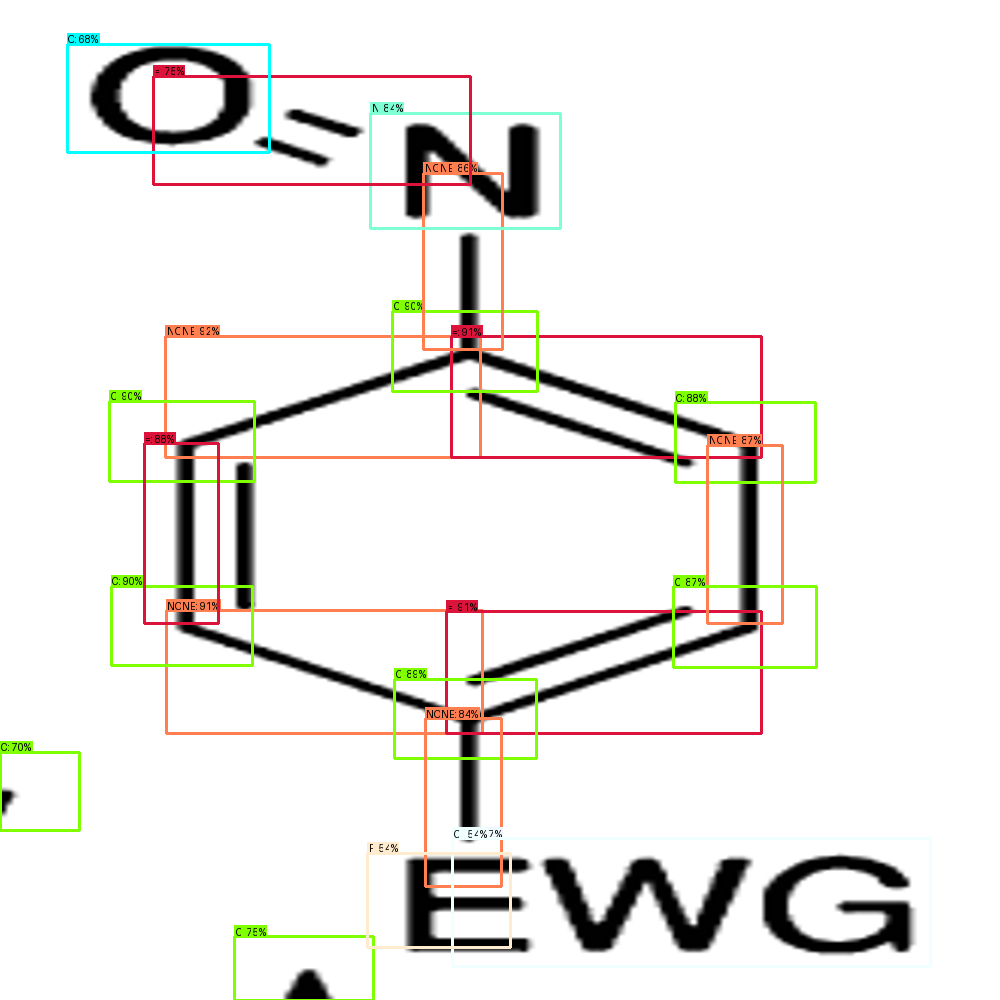

In [ ]:
boxed_img

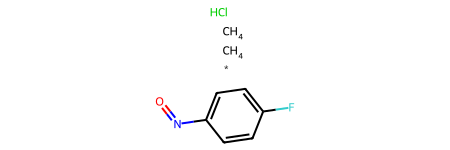

In [ ]:
Chem.MolFromSmiles(smiles)

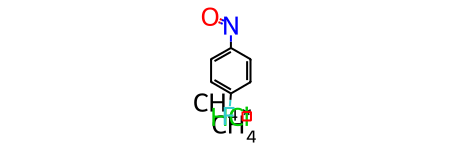

In [ ]:
mol_rebuit


In [ ]:
SMI_IDX=Chem.MolToSmiles(final_mol)

In [ ]:
from SmilesPE.pretokenizer import atomwise_tokenizer
SMI_IDX=Chem.MolToSmiles(final_mol)
ai_smi=atomwise_tokenizer(SMI_IDX)

In [ ]:
print(ai_smi)

['*', '.', 'C', '.', 'C', '.', 'Cl', '.', 'O', '=', 'N', 'c', '1', 'c', 'c', 'c', '(', 'F', ')', 'c', 'c', '1']


In [ ]:
Chem.MolToSmiles(mol, canonical=False, doRandom=False, isomericSmiles=True, 
            kekuleSmiles=True)



'C1=C(N=O)C=CC(F)=C1.C.C.*.Cl'

In [ ]:
Chem.MolToSmiles(mol)

'*.C.C.Cl.O=Nc1ccc(F)cc1'

In [ ]:
#TODO rotable boxing  and aromatic bonding rings??

In [ ]:
['US20070249620A1_p0006_x1375_y2591_c00009.png', 'US20050182067A1_p0032_x1638_y1021_c00113.png', 'US20050113580A1_p0038_x1307_y1020_c00053.png', 'US20030130506A1_p0008_x1381_y1349_c00031.png', 'US20050054819A1_p0033_x1376_y0730_c00118.png', 'US20060281700A1_p0083_x0404_y0649_c00163.png', 'US20050182067A1_p0036_x1607_y2740_c00137.png', 'US20070270434A1_p0018_x1376_y0766_c00041.png']

['US20070249620A1_p0006_x1375_y2591_c00009.png',
 'US20050182067A1_p0032_x1638_y1021_c00113.png',
 'US20050113580A1_p0038_x1307_y1020_c00053.png',
 'US20030130506A1_p0008_x1381_y1349_c00031.png',
 'US20050054819A1_p0033_x1376_y0730_c00118.png',
 'US20060281700A1_p0083_x0404_y0649_c00163.png',
 'US20050182067A1_p0036_x1607_y2740_c00137.png',
 'US20070270434A1_p0018_x1376_y0766_c00041.png']

In [ ]:
# original_smiles::: CC1=C[U]=C(N2CCN(C)CC2)C=C1
# test_smiles::: Cc1c*c(N2CCN(C)CC2)cc1
# file_name:: US20070249620A1_p0006_x1375_y2591_c00009.png
# original_smiles::: COC1=C([N+](=O)[O-])C(N)=CC=C1
# test_smiles::: COc1cccc(N)c1NO.O
# file_name:: US20050182067A1_p0032_x1638_y1021_c00113.png
# original_smiles::: COC(=O)CC1=CC=CC(OCCCN(CC2=CC=CC(C(F)(F)F)=C2Cl)C[C@H](OC(=O)C2=CC=CC=C2)C2=CC=CC=C2)=C1
# test_smiles::: C.COC(=O)Cc1cccc(OCCCN(Cc2cccc(C(F)(F)F)c2Cl)C[C@@H]2OC(=O)c3cc2cccc(C)ccc3)c1
# file_name:: US20050113580A1_p0038_x1307_y1020_c00053.png
# original_smiles::: [*]C1([*])*[W]CN(S(=O)(=O)C2=CC=C(O[Ar])C=C2)C1C(=O)NO
# test_smiles::: *Oc1ccc([S](=O)(=O)N2C**C(*)(*)C2C(=O)NO)cc1
# file_name:: US20030130506A1_p0008_x1381_y1349_c00031.png
# original_smiles::: [C-]#[N+]CC1=CN=CC=C1
# test_smiles::: C.NCc1cccnc1
# file_name:: US20050054819A1_p0033_x1376_y0730_c00118.png
# original_smiles::: O=[N+]([O-])C1=CN=C(OC2CCC2)C=C1
# test_smiles::: O.ONc1ccc(OC2CCC2)nc1
# file_name:: US20060281700A1_p0083_x0404_y0649_c00163.png
# original_smiles::: O=C1COC2=CC=CC([N+](=O)[O-])=C2N1
# test_smiles::: O.O=Nc1cccc2c1NC(=O)CO2
# file_name:: US20050182067A1_p0036_x1607_y2740_c00137.png
# original_smiles::: [C-]#[N+]CC1=CC=C(OC(F)(F)F)C=C1
# test_smiles::: C#N.Cc1ccc(OC(F)(F)F)cc1
# file_name:: US20070270434A1_p0018_x1376_y0766_c00041.png
#

#TODO check the above wrongs and try fix

In [ ]:
res_smiles=[]
for i,(key,value) in enumerate(filtered_output_dict.items()):
    result = []
    res_smiles.append(output_to_smiles(value,idx_to_labels,bond_labels,result)) 

In [ ]:
#prediction postprocesss 
logits, boxes = outputs['pred_logits'], outputs['pred_boxes']
scores =  torch.nn.functional.sigmoid(logits)
bbox_pred = torchvision.ops.box_convert(boxes, in_fmt='cxcywh', out_fmt='xyxy')
labels_scores = torch.nn.functional.softmax(logits,dim=-1)
labels_pred = torch.argmax(labels_scores,dim=-1)

In [ ]:
ori_size=torch.Tensor([w,h]).long().unsqueeze(0)